# Dynamic and Hybrid Conditioning for Compositional Image Retrieval

**Deep Learning 2026 — Project notebook**

*Team: Matteo Pareto, Elena Deidda*

*Developed with the assistance of an AI coding assistant; see the declaration in Section 12.*

---

## Abstract

Given a reference face and a set of signed attribute constraints (`+Eyeglasses`,
`-Smiling`), the task is to retrieve from the CelebA test split, 19,962 images, the
faces that satisfy every constraint while still looking like the reference. We compare
three methods on the official benchmark (`celeba_evaluation.json`, Recall@K and
Precision@K at $K \in \{1,5,10\}$), evaluated over all 27,697 source-query pairs.

*Level 1*, the mandatory zero-shot baseline, is latent arithmetic,
$\hat q = \mathrm{norm}(v_{ref} + \sum_i s_i t_i)$. It reaches R@10 = 0.110.

*Level 2* swaps the cross-modal text vectors for visual attribute directions estimated
on the train split, composed either linearly or on the sphere with log/exp maps. It
reaches 0.117. That is not a meaningful gain over Level 1, and we report it as one of
several negative results rather than dressing it up.

*Level 3* is the contribution: a 3.02M-parameter module on top of frozen CLIP that
builds a direction from the conditions and uses a learned gate to decide how far along
it to move. We train it with InfoNCE on triplets mined from the train split under the
benchmark's own relaxed-Hamming rule. **R@10 = 0.338, 3.1× the baseline.**

Sections 10 and 11 test that result instead of presenting it. Section 10 adds
single-modality controls, component ablations, and seed and learning-rate studies;
between them they overturned four conclusions we had already written down. Two of those
checks speak to the brief directly. The naive pre-SVD stacking the assignment names as
the thing to surpass is measured for the first time in Section 11.9, where it reaches
**0.092**, so Level 3 is 3.7× it. And a permutation control shows the reference image is
really being used: hand a query the wrong source and Level 3 loses **48%** of its recall
(Sections 8.7 and 10.7).

Section 11 then questions the one assumption none of the three levels examines, that the
answer has to be a single composed vector compared by cosine. The assignment asks for a
*dynamic similarity metric*, not a vector, and CLAY does not compose a query either. Two
training-free diagnostics show the benchmark's ground truth is reproduced exactly by an
attribute rule, so scoring that rule directly in predicted-attribute space reaches
**R@10 = 0.558** using a third of the parameters, while losing the open-vocabulary
property that makes Levels 1-3 general. We report both numbers, and what the second one
costs.

---


## 1. Environment setup

The notebook runs on Google Colab (GPU runtime recommended). It expects on Google Drive,
inside `MyDrive/datasets/`:

- `celeba.zip` — the CelebA dataset (provided by the course),
- `celeba_evaluation.json` — the official benchmark file.

All caches (CLIP embeddings, mined training examples, model checkpoint) are written to the
same Drive folder so they survive runtime disconnections.

Running outside Colab (e.g. on an Azure GPU VM): the notebook falls back to local
paths — `celeba.zip`, `celeba_evaluation.json` and all caches live in the repo's
`database/` folder, and the dataset is extracted automatically into `./datasets/`.
Launch Jupyter from the repo root (or set the `DL_PROJECT_ROOT` environment variable to
point at it). The `.pt` cache files are portable between environments, and the
notebook detects which one it is running in without any manual configuration.

In [1]:
%pip install -q transformers accelerate


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /home/disi/DL-ParetoDeidda/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import math
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm

IN_COLAB = "google.colab" in sys.modules

# --- Paths -----------------------------------------------------------------
if IN_COLAB:
    DRIVE_DIR = Path("/content/drive/MyDrive/datasets")  # zip, benchmark JSON, caches
    DATA_ROOT = Path("/content/datasets")                # fast local SSD (wiped on disconnect)
else:
    # VM / local machine: everything lives inside the repo. Paths resolve
    # against the repo root — launch Jupyter from the repo root, or point
    # DL_PROJECT_ROOT at it explicitly.
    ROOT = Path(os.environ.get("DL_PROJECT_ROOT", ".")).resolve()
    DRIVE_DIR = ROOT / "database"                        # zip, benchmark JSON, caches
    DATA_ROOT = ROOT / "datasets"

EVAL_JSON_PATH = DRIVE_DIR / "celeba_evaluation.json"
MODEL_NAME = "openai/clip-vit-base-patch32"              # mandatory model for the assignment

# --- Global switches ---------------------------------------------------------
SEED = 42
K_VALUES = (1, 5, 10)     # evaluation cutoffs required by the assignment
SMOKE_TEST = False        # True = fast reduced run to debug the whole pipeline
SMOKE_SUFFIX = "_smoke" if SMOKE_TEST else ""

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Fixed categorical colors for all charts (validated colorblind-safe palette)
METHOD_COLORS = {
    "L1 zero-shot arithmetic": "#2a78d6",             # blue
    "L2 visual directions": "#1baf7a",                # aqua
    "L3 gated residual fusion": "#eda100",            # yellow
    "L2 visual directions (linear ablation)": "#008300",  # green
}

print(f"Colab: {IN_COLAB} | device: {device} | smoke test: {SMOKE_TEST}")

Colab: False | device: cuda | smoke test: False


In [3]:
# Dataset preparation — same cell for Colab and for a VM/local machine.
# Inputs expected in DRIVE_DIR: celeba.zip and celeba_evaluation.json.
# On Colab DRIVE_DIR is Google Drive; on a VM it is the repo's database/ folder.
import shutil
import zipfile

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

celeba_dir = DATA_ROOT / "celeba"
# Everything torchvision's CelebA validates at init (root must be the PARENT
# of celeba/): the image folder plus the five MD5-checked metadata files.
REQUIRED = [
    "img_align_celeba",
    "list_attr_celeba.txt",
    "list_eval_partition.txt",
    "identity_CelebA.txt",
    "list_bbox_celeba.txt",
    "list_landmarks_align_celeba.txt",
]


def dataset_complete():
    return all((celeba_dir / f).exists() for f in REQUIRED)


# A marker distinguishes a completed extraction from a partial one left by an
# interrupted run (the celeba/ folder appears before extraction finishes).
done_marker = celeba_dir / ".unzip_done"
if not done_marker.exists() and not dataset_complete():
    zip_path = DRIVE_DIR / "celeba.zip"
    assert zip_path.exists(), (
        f"Dataset archive not found: {zip_path}\n"
        "- Colab: put celeba.zip in MyDrive/datasets/ (course-provided file).\n"
        "- VM/local: copy celeba.zip into the repo's database/ folder.\n"
        "See the setup notes at the top of Section 1."
    )
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {zip_path} -> {DATA_ROOT} (a few minutes)...")
    if shutil.which("unzip"):  # fast native path
        import subprocess
        subprocess.run(["unzip", "-q", str(zip_path), "-d", str(DATA_ROOT)],
                       check=True)
    else:                      # portable fallback, no external binary needed
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_ROOT)
    done_marker.touch()

assert dataset_complete(), (
    f"Dataset folder incomplete under {celeba_dir} — missing: "
    f"{[f for f in REQUIRED if not (celeba_dir / f).exists()]}.\n"
    f"Delete {celeba_dir} and re-run this cell to re-extract."
)
assert EVAL_JSON_PATH.exists(), (
    f"Benchmark file not found: {EVAL_JSON_PATH}\n"
    "- Colab: put celeba_evaluation.json in MyDrive/datasets/.\n"
    "- VM/local: it ships with the repo in database/."
)
print("Dataset ready at", celeba_dir)

Dataset ready at /home/disi/DL-ParetoDeidda/datasets/celeba


## 2. Data loading

We load two splits of CelebA through `torchvision.datasets.CelebA`:

- test (19,962 images): the retrieval corpus. All benchmark sources and targets are
  *dataset indices* into this split (not filenames — see the assignment's warning).
- train (162,770 images): never touched by the evaluation. We use it in §6 to estimate
  visual attribute directions and in §7 to mine training triplets for the fusion module.

Each image comes with 40 binary attribute annotations (`celeba.attr`, values in $\{0,1\}$).

In [4]:
from torchvision.datasets import CelebA

celeba_test = CelebA(root=DATA_ROOT, split="test", download=False)
celeba_train = CelebA(root=DATA_ROOT, split="train", download=False)

# Some torchvision versions append a trailing empty name — filter it out.
attr_names = [n for n in celeba_test.attr_names if n]
N_ATTRS = len(attr_names)
idx2attribute = dict(enumerate(attr_names))
attribute2idx = {name: idx for idx, name in idx2attribute.items()}

# Binary attribute matrices, shape (N, 40), values in {0, 1}
attrs_test = celeba_test.attr.to(torch.uint8)
attrs_train = celeba_train.attr.to(torch.uint8)
attrs_train_dev = attrs_train.to(device)  # small (~6.5 MB), used a lot in §6-7

assert len(celeba_test) == 19962, f"Unexpected test split size: {len(celeba_test)}"
assert N_ATTRS == 40, f"Expected 40 attributes, got {N_ATTRS}"
assert attrs_test.shape == (len(celeba_test), 40)
assert set(attrs_train.unique().tolist()) <= {0, 1}, "Attributes must be in {0,1}"

print(f"test: {len(celeba_test)} images | train: {len(celeba_train)} images")
print(f"attributes ({N_ATTRS}): {attr_names[:6]} ...")

test: 19962 images | train: 162770 images
attributes (40): ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs'] ...


## 3. Offline feature extraction

Following the CLAY methodology, the visual database is built **once, offline, and kept
frozen**: we embed every image with CLIP ViT-B/32, L2-normalize (CLIP similarity is cosine
similarity, so all vectors live on the unit hypersphere $\mathbb{S}^{511}$), and cache the
result on Drive. All three methods then operate purely on these frozen 512-d embeddings —
no CLIP forward pass is ever needed again, which is what makes training in §7 take minutes.

Expected one-time cost on a T4: ~5 min (test split) + ~35 min (train split). The
extraction writes a partial checkpoint every 100 batches, so an interrupted run resumes
where it stopped instead of restarting from zero.

In [5]:
from transformers import CLIPModel, CLIPProcessor

processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)  # CLIP stays frozen for the whole project

print(f"Model loaded: {MODEL_NAME}")


def clip_features(out):
    # transformers >=5 returns BaseModelOutputWithPooling from
    # get_image_features / get_text_features, with the projection already
    # applied to pooler_output; transformers 4.x returns that tensor directly.
    # Accept both so the notebook is not tied to one major version.
    return out if torch.is_tensor(out) else out.pooler_output


def load_cache(path, map_location="cpu"):
    # Caches are a convenience, never a dependency. A file written under different
    # library versions can fail to unpickle: pandas changed StringDtype's signature
    # between 2.x and 3.x, so a DataFrame pickled by one crashes the other. Treat
    # anything unreadable as a cache MISS and recompute, rather than stopping a
    # Run all halfway through.
    if not Path(path).exists():
        return None
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except Exception as e:
        print(f"Cache {Path(path).name} unreadable ({type(e).__name__}); recomputing.")
        return None


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded: openai/clip-vit-base-patch32


In [6]:
class ImageOnlyDataset(Dataset):
    # Wraps a CelebA split and yields only the PIL image;
    # CLIPProcessor handles resize / center-crop / normalization.
    def __init__(self, base):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        return self.base[idx][0]


def clip_collate(images):
    return processor(images=images, return_tensors="pt")


@torch.no_grad()
def extract_image_embeddings(split_ds, split_name, cache_path, batch_size=256):
    # Returns (N, 512) L2-normalized CLIP embeddings, cached on Drive.
    # The cache is validated against model, split identity and split size, so a
    # stale or misplaced cache file fails loudly instead of silently misaligning.
    cache_path = Path(cache_path)
    blob = load_cache(cache_path)
    if blob is not None:
        assert blob["model"] == MODEL_NAME, "Cache was built with a different model"
        assert blob.get("split") == split_name, "Cache belongs to a different split"
        emb = blob["embeddings"]
        assert len(emb) == len(split_ds), "Cache size does not match the split"
        print(f"Loaded cached embeddings {tuple(emb.shape)} from {cache_path}")
        return emb

    # Resume from a partial checkpoint if a previous extraction was interrupted
    # (a single corrupt image or a disconnect no longer costs the whole run).
    partial_path = cache_path.with_suffix(".partial.pt")
    chunks, done = [], 0
    part = load_cache(partial_path)
    if part is not None:
        if part["model"] == MODEL_NAME and part["split"] == split_name:
            chunks, done = [part["embeddings"]], len(part["embeddings"])
            print(f"Resuming extraction from image {done}/{len(split_ds)}")

    loader = DataLoader(
        Subset(ImageOnlyDataset(split_ds), range(done, len(split_ds))),
        batch_size=batch_size,
        shuffle=False,   # keep original order so row i == dataset index i
        num_workers=2,
        collate_fn=clip_collate,
    )
    for i, batch in enumerate(tqdm(loader, desc=f"Embedding -> {cache_path.name}")):
        # get_image_features = vision transformer + projection to the shared 512-d space
        feats = clip_features(
            model.get_image_features(pixel_values=batch["pixel_values"].to(device))
        )
        chunks.append(F.normalize(feats, dim=-1).cpu())
        if (i + 1) % 100 == 0:  # partial save: never lose more than 100 batches
            torch.save({"embeddings": torch.cat(chunks), "model": MODEL_NAME,
                        "split": split_name}, partial_path)
    emb = torch.cat(chunks)
    torch.save({"embeddings": emb, "model": MODEL_NAME, "split": split_name}, cache_path)
    partial_path.unlink(missing_ok=True)
    print(f"Saved {tuple(emb.shape)} to {cache_path}")
    return emb

In [7]:
test_emb = extract_image_embeddings(celeba_test, "test", DRIVE_DIR / "celeba_clip_test_emb.pt")
train_emb = extract_image_embeddings(celeba_train, "train", DRIVE_DIR / "celeba_clip_train_emb.pt")

# Device copies used for all similarity computations
test_emb_dev = test_emb.to(device)
train_emb_dev = train_emb.to(device)

# Sanity: shapes and unit norms
assert test_emb.shape == (len(celeba_test), 512)
assert train_emb.shape == (len(celeba_train), 512)
assert torch.allclose(test_emb.norm(dim=-1), torch.ones(len(test_emb)), atol=1e-3)
assert torch.allclose(train_emb.norm(dim=-1), torch.ones(len(train_emb)), atol=1e-3)
print("Embeddings OK.")

Loaded cached embeddings (19962, 512) from /home/disi/DL-ParetoDeidda/database/celeba_clip_test_emb.pt
Loaded cached embeddings (162770, 512) from /home/disi/DL-ParetoDeidda/database/celeba_clip_train_emb.pt
Embeddings OK.


In [8]:
# Sanity: cache rows must correspond to dataset indices (row i == celeba_test[i]).
# Re-embed a few random test images one by one and compare with the cached rows:
# this validates the invariant every later section relies on.
probe_idx = random.Random(SEED).sample(range(len(celeba_test)), 5)
with torch.no_grad():
    for i in probe_idx:
        inputs = processor(images=celeba_test[i][0], return_tensors="pt").to(device)
        fresh_feats = clip_features(model.get_image_features(**inputs))
        fresh = F.normalize(fresh_feats, dim=-1).cpu().squeeze(0)
        cos = float(fresh @ test_emb[i])
        assert cos > 0.99, (
            f"Cache row {i} does not match a fresh embedding (cos={cos:.4f}) — "
            "the cache is misaligned or stale; delete it and re-extract."
        )
print(f"Cache alignment OK: rows match fresh embeddings for indices {probe_idx}")

Cache alignment OK: rows match fresh embeddings for indices [3648, 819, 9012, 8024, 7314]


## 4. Benchmark: queries, parsing, evaluation harness

`celeba_evaluation.json` is a list of 14 query entries (the query `-Young` appears twice —
we simply evaluate every entry as given). Each entry contains:

- `query`: e.g. `"+Eyeglasses"` or `"-Smiling, +Eyeglasses, +Wearing_Hat"` — attribute
  names match `celeba.attr_names` exactly, comma-separated, prefixed by `+`/`-`;
- `ground_truth`: a dict mapping source indices (as strings) to the list of valid
  target indices. Both are *PyTorch dataset indices* into the test split.

A target is valid iff it strictly satisfies the query constraints and its remaining
attributes are within Hamming distance ≤ 2 of the source (identity preservation). Only
sources with ≥ 5 valid targets are included.

Metrics. For each query we average over its sources: Recall@K (1 if at least one valid
target is in the top-K, the primary metric) and Precision@K, at $K \in \{1,5,10\}$.
For reference, a random ranker with ~26 valid targets in a corpus of 19,962 gets
$R@10 \approx 1 - (1 - 26/19962)^{10} \approx 1.3\%$.

All methods are evaluated by the same harness: they only differ in a
`make_queries(conds, source_indices) -> (S, 512)` function that produces the composite
query embeddings; ranking is always cosine similarity against the frozen test corpus,
with the source image itself excluded from the ranking.

In [9]:
with open(EVAL_JSON_PATH, "r") as f:
    annotations = json.load(f)


def parse_query(query_str):
    # "-Smiling, +Eyeglasses" -> [("Smiling", -1), ("Eyeglasses", +1)]
    conds = []
    for part in query_str.split(","):
        part = part.strip()
        sign = +1 if part[0] == "+" else -1
        attr = part[1:].strip()
        assert attr in attribute2idx, f"Unknown attribute in query: {attr!r}"
        conds.append((attr, sign))
    return conds


# Sanity: every benchmark query must parse against the CelebA attribute names
for entry in annotations:
    parse_query(entry["query"])

print(f"{len(annotations)} benchmark queries, all parsed OK:")
for entry in annotations:
    n_src = len(entry["ground_truth"])
    avg_tgt = np.mean([len(v) for v in entry["ground_truth"].values()])
    print(f"  {entry['query']:<45} sources: {n_src:>5} | avg targets: {avg_tgt:5.1f}")

14 benchmark queries, all parsed OK:
  +Smiling                                      sources:  4786 | avg targets:  26.0
  +Eyeglasses                                   sources:  2196 | avg targets:  20.3
  -Heavy_Makeup                                 sources:  4087 | avg targets:  25.2
  +Male                                         sources:  1595 | avg targets:  64.8
  -Young                                        sources:  5355 | avg targets:  23.3
  +Blond_Hair                                   sources:  5469 | avg targets:  25.1
  +Mustache                                     sources:   301 | avg targets:   7.8
  -Young                                        sources:  5355 | avg targets:  23.3
  +Eyeglasses, +Smiling                         sources:   612 | avg targets:  11.6
  +Black_Hair, -Wavy_Hair                       sources:  2572 | avg targets:  28.7
  -Male, -Mustache                              sources:    27 | avg targets:  16.1
  +Chubby, -Young                      

In [10]:
# Sanity: do benchmark sources already satisfy (part of) their own query?
# The triplet mining in section 7 assumes they do not (it derives condition signs
# by flipping the source's attribute values, like "+Smiling" sources that are not
# smiling). This cell measures how well that assumption holds on the real data.
violations, total = 0, 0
for entry in annotations:
    conds = parse_query(entry["query"])
    src = torch.tensor([int(s) for s in entry["ground_truth"]], dtype=torch.long)
    for attr, sign in conds:
        a = attribute2idx[attr]
        target_value = 1 if sign > 0 else 0   # value a retrieved TARGET must have
        violations += int((attrs_test[src, a] == target_value).sum())
        total += len(src)
rate = 100 * violations / total
print(f"sources already satisfying a condition of their query: "
      f"{violations}/{total} ({rate:.2f}%)")
if rate > 5:
    print("NOTE: the rate is non-negligible — consider relaxing the flip rule in "
          "the mining of section 7 (allow conditions the source already satisfies).")

sources already satisfying a condition of their query: 0/37073 (0.00%)


In [11]:
def evaluate_retrieval(retrieved_indices, ground_truth_indices, k):
    # Metric implementation provided in the course skeleton (kept verbatim in spirit):
    # Recall@K is a per-source hit indicator, Precision@K the fraction of hits in top-K.
    top_k_retrieved = retrieved_indices[:k]
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)
    return {
        f"Recall@{k}": 1 if num_hits > 0 else 0,
        f"Precision@{k}": num_hits / k,
    }


@torch.no_grad()
def rank_topk(Q, corpus_emb, exclude_idx, k):
    # Single home of the ranking rule: cosine similarity against the frozen
    # corpus, with the source image(s) excluded from the results.
    # Q: (S, 512) unit-norm; exclude_idx: (S,) long. Returns (S, k) CPU indices.
    sims = Q @ corpus_emb.T
    sims[torch.arange(len(Q), device=sims.device),
         exclude_idx.to(sims.device)] = -float("inf")
    return sims.topk(k, dim=1).indices.cpu()


@torch.no_grad()
def run_benchmark(annotations, make_queries, method_name,
                  db_emb=None, k_values=K_VALUES, chunk_size=2048):
    # Evaluates one method on every benchmark entry.
    # make_queries(conds, src_idx_tensor) must return (S, 512) unit-norm query
    # embeddings on `device`, one per source image.
    # Returns (df, details): df holds the per-query MEANS; details keeps the
    # per-source BINARY outcomes, which §8 needs for bootstrap confidence
    # intervals and paired significance tests (a mean alone cannot tell you
    # how uncertain it is).
    if db_emb is None:
        db_emb = test_emb_dev
    max_k = max(k_values)
    rows, details = [], []
    for entry in tqdm(annotations, desc=method_name):
        conds = parse_query(entry["query"])
        gt = entry["ground_truth"]
        src = torch.tensor([int(s) for s in gt.keys()], dtype=torch.long)
        if SMOKE_TEST:
            src = src[:200]  # reduced run for fast end-to-end debugging

        tops = []
        for i in range(0, len(src), chunk_size):
            chunk = src[i:i + chunk_size]
            Q = make_queries(conds, chunk)                      # (S, 512)
            tops.append(rank_topk(Q, db_emb, chunk, max_k))
        top = torch.cat(tops)

        # `smoke` records the evaluation mode, so §8 can refuse to compare a
        # reduced smoke run against full runs.
        row = {"query": entry["query"], "sources": len(src), "smoke": SMOKE_TEST}
        detail = {"query": entry["query"], "sources": src.numpy().copy(),
                  "recall_hits": {}}
        for k in k_values:
            recalls, precisions = [], []
            for i, s in enumerate(src.tolist()):
                m = evaluate_retrieval(top[i].tolist(), gt[str(s)], k)
                recalls.append(m[f"Recall@{k}"])
                precisions.append(m[f"Precision@{k}"])
            row[f"R@{k}"] = float(np.mean(recalls))
            row[f"P@{k}"] = float(np.mean(precisions))
            detail["recall_hits"][k] = np.array(recalls, dtype=np.uint8)
        rows.append(row)
        details.append(detail)

    df = pd.DataFrame(rows)
    # '-Young' appears twice in the benchmark JSON: both rows are evaluated and
    # reported (faithful to the file), but the macro average is computed over
    # unique queries so that no query is double-weighted.
    uniq = df.drop_duplicates(subset="query")
    macro = {"query": "MACRO AVERAGE", "sources": int(uniq["sources"].sum()),
             "smoke": SMOKE_TEST}
    for c in [c for c in df.columns if c.startswith(("R@", "P@"))]:
        macro[c] = uniq[c].mean()
    df.loc[len(df)] = macro
    df.insert(0, "method", method_name)
    return df, details


# Harness self-test (same cases as the course skeleton)
assert evaluate_retrieval([], [3, 2, 1], 1) == {"Recall@1": 0, "Precision@1": 0.0}
assert evaluate_retrieval([3, 9, 9], [3, 2, 1], 1) == {"Recall@1": 1, "Precision@1": 1.0}
assert evaluate_retrieval([9, 9, 3], [3, 2, 1], 3)["Recall@3"] == 1
print("Harness self-test OK.")

Harness self-test OK.


## 5. Level 1 — Zero-shot latent arithmetic (mandatory baseline)

Method. Each attribute $a$ is described by a natural-language prompt (prompt
engineering matters for CLIP, so we use hand-written phrases like *"a photo of a person
wearing eyeglasses"* rather than raw attribute names). With $t_a$ the normalized CLIP text
embedding of the prompt and $s_i \in \{+1, -1\}$ the sign of each condition, the composite
query is plain latent arithmetic:

$$\hat q \;=\; \frac{v_{ref} + \sum_{i} s_i\, t_{a_i}}{\left\lVert v_{ref} + \sum_{i} s_i\, t_{a_i} \right\rVert}$$

Known limitations (which motivate Levels 2 and 3):

- *Fixed weights*: every condition contributes with weight 1, regardless of whether the
  reference already satisfies it or of conflicts between conditions.
- *Modality gap*: CLIP image and text embeddings occupy two disjoint cones on the sphere,
  so adding a text vector to an image vector moves the query partly along the (semantically
  meaningless) image→text direction.
- *Negation*: CLIP behaves like a bag-of-words model cross-modally; subtracting the
  embedding of "smiling" is a crude proxy for "not smiling".

In [12]:
# Natural-language prompts. Hand-written phrases for the attributes used by the
# benchmark; a generic template covers the remaining ones.
PROMPT_OVERRIDES = {
    "Smiling": "a photo of a smiling person",
    "Eyeglasses": "a photo of a person wearing eyeglasses",
    "Heavy_Makeup": "a photo of a person wearing heavy makeup",
    "Male": "a photo of a man",
    "Young": "a photo of a young person",
    "Blond_Hair": "a photo of a person with blond hair",
    "Black_Hair": "a photo of a person with black hair",
    "Wavy_Hair": "a photo of a person with wavy hair",
    "Mustache": "a photo of a person with a mustache",
    "Chubby": "a photo of a chubby person",
    "Wearing_Hat": "a photo of a person wearing a hat",
    "Wearing_Lipstick": "a photo of a person wearing lipstick",
    "No_Beard": "a photo of a clean-shaven person",
    "5_o_Clock_Shadow": "a photo of a person with stubble",
}


def build_prompt(attr_name):
    generic = f"a photo of a person with {attr_name.replace('_', ' ').lower()}"
    return PROMPT_OVERRIDES.get(attr_name, generic)


@torch.no_grad()
def encode_texts(prompts, batch_size=64):
    feats = []
    for i in range(0, len(prompts), batch_size):
        inputs = processor(
            text=prompts[i:i + batch_size], return_tensors="pt", padding=True
        ).to(device)
        feats.append(clip_features(model.get_text_features(**inputs)))
    return F.normalize(torch.cat(feats), dim=-1)


# (40, 512) matrix: one normalized text embedding per attribute, row = attribute index.
# Reused by Level 1 (arithmetic) and Level 3 (condition tokens).
text_feats = encode_texts([build_prompt(idx2attribute[i]) for i in range(N_ATTRS)])
print("text_feats:", tuple(text_feats.shape))
print("example prompt:", build_prompt("Wearing_Lipstick"))

text_feats: (40, 512)
example prompt: a photo of a person wearing lipstick


In [13]:
# Sanity: do the attribute prompts separate positive from negative images at all?
# AUC of the text-image similarity on a random train sample, per benchmark
# attribute. AUC ~0.5 means the prompt carries no signal and should be reworded.
BENCH_ATTRS = sorted({a for e in annotations for a, _ in parse_query(e["query"])})
sample = torch.randperm(len(celeba_train))[:20000]
emb_sample = train_emb_dev[sample.to(device)]
attr_sample = attrs_train[sample]


def auc_from_scores(scores, labels):
    # Rank-based AUC (Mann-Whitney U), no sklearn dependency.
    order = scores.argsort()
    ranks = torch.empty_like(order, dtype=torch.float)
    ranks[order] = torch.arange(len(scores), dtype=torch.float)
    pos = labels.bool()
    n_pos, n_neg = int(pos.sum()), int((~pos).sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    return float((ranks[pos].sum() - n_pos * (n_pos - 1) / 2) / (n_pos * n_neg))


print(f"{'attribute':<20} {'AUC':>6}   prompt")
for name in BENCH_ATTRS:
    a = attribute2idx[name]
    scores = (emb_sample @ text_feats[a]).cpu()
    auc = auc_from_scores(scores, attr_sample[:, a])
    flag = "  <-- weak prompt, consider rephrasing" if auc < 0.6 else ""
    print(f"{name:<20} {auc:6.3f}   {build_prompt(name)!r}{flag}")

attribute               AUC   prompt
Black_Hair            0.772   'a photo of a person with black hair'
Blond_Hair            0.909   'a photo of a person with blond hair'
Chubby                0.608   'a photo of a chubby person'
Eyeglasses            0.888   'a photo of a person wearing eyeglasses'
Heavy_Makeup          0.777   'a photo of a person wearing heavy makeup'
Male                  0.990   'a photo of a man'
Mustache              0.761   'a photo of a person with a mustache'
Smiling               0.864   'a photo of a smiling person'
Wavy_Hair             0.750   'a photo of a person with wavy hair'
Wearing_Hat           0.890   'a photo of a person wearing a hat'
Wearing_Lipstick      0.699   'a photo of a person wearing lipstick'
Young                 0.617   'a photo of a young person'


In [14]:
def make_queries_baseline(conds, src_idx):
    # q = normalize(v_ref + sum_i sign_i * t_i)  — fixed unit weights.
    t = torch.stack(
        [sign * text_feats[attribute2idx[attr]] for attr, sign in conds]
    ).sum(dim=0)
    v = test_emb_dev[src_idx.to(device)]
    return F.normalize(v + t, dim=-1)


df_baseline, det_baseline = run_benchmark(
    annotations, make_queries_baseline, "L1 zero-shot arithmetic"
)
df_baseline.round(3)

L1 zero-shot arithmetic:   0%|          | 0/14 [00:00<?, ?it/s]

,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L1 zero-shot arithmetic,+Smiling,4786,False,0.065,0.065,0.184,0.048,0.259,0.040
1,L1 zero-shot arithmetic,+Eyeglasses,2196,False,0.020,0.020,0.084,0.020,0.134,0.018
2,L1 zero-shot arithmetic,-Heavy_Makeup,4087,False,0.030,0.030,0.094,0.022,0.149,0.019
3,L1 zero-shot arithmetic,+Male,1595,False,0.009,0.009,0.024,0.006,0.043,0.006
4,L1 zero-shot arithmetic,-Young,5355,False,0.010,0.010,0.032,0.008,0.056,0.007
5,L1 zero-shot arithmetic,+Blond_Hair,5469,False,0.024,0.024,0.082,0.022,0.132,0.020
6,L1 zero-shot arithmetic,+Mustache,301,False,0.066,0.066,0.166,0.047,0.236,0.037
7,L1 zero-shot arithmetic,-Young,5355,False,0.010,0.010,0.032,0.008,0.056,0.007
8,L1 zero-shot arithmetic,"+Eyeglasses, +Smiling",612,False,0.025,0.025,0.062,0.014,0.095,0.011
9,L1 zero-shot arithmetic,"+Black_Hair, -Wavy_Hair",2572,False,0.026,0.026,0.098,0.023,0.149,0.020


## 6. Level 2 — Visual attribute directions (training-free)

Idea. The baseline's weakest assumption is that a *text* embedding is a good direction
to move an *image* embedding. Because of the modality gap it is not. But the CelebA train
split gives us attribute labels for 162,770 images, so we can estimate the direction of
each attribute *inside the image cone*, where the arithmetic actually happens:

$$\delta_a \;=\; \mathbb{E}\big[v \mid a{=}1\big] \;-\; \mathbb{E}\big[v \mid a{=}0\big]$$

This is fully training-free (two means per attribute) and intra-modal — no gap to cross.

Spherical (geodesic) variant. CLIP embeddings live on the unit sphere, so Euclidean
averaging and addition are geometrically sloppy (Berasi et al., 2025). We therefore also
compute the directions in the tangent space at the intrinsic mean $\mu$ of the image cone,
using the sphere's logarithmic and exponential maps:

$$\mathrm{Log}_{\mu}(x) = \frac{\theta}{\sin\theta}\,\big(x - \cos\theta \,\mu\big),
\qquad \theta = \arccos\langle \mu, x\rangle$$

$$\mathrm{Exp}_{\mu}(u) = \cos(\lVert u\rVert)\,\mu + \sin(\lVert u\rVert)\,\frac{u}{\lVert u\rVert}$$

Directions are tangent-space class means, and the query is composed on the manifold:

$$\hat q \;=\; \mathrm{Exp}_{\mu}\!\Big(\mathrm{Log}_{\mu}(v_{ref}) + \gamma \sum_i s_i\, \delta_{a_i}\Big)$$

We report both the linear and the geodesic variant. The step size $\gamma$ is kept at 1.0;
it could be tuned, but only on synthetic train-split queries (never on the benchmark — that
would be test leakage). The mined validation split built in §7 is the right place for such
tuning if desired.

In [15]:
EPS = 1e-7


def log_map(x, mu):
    # Sphere log map: maps unit vectors x to the tangent space at mu.
    cos_t = (x @ mu).clamp(-1 + EPS, 1 - EPS)
    theta = torch.acos(cos_t)
    u = x - cos_t.unsqueeze(-1) * mu
    u = u / u.norm(dim=-1, keepdim=True).clamp_min(EPS)
    return theta.unsqueeze(-1) * u


def exp_map(u, mu):
    # Sphere exp map: maps tangent vectors at mu back to the sphere.
    n = u.norm(dim=-1, keepdim=True).clamp_min(EPS)
    return torch.cos(n) * mu + torch.sin(n) * (u / n)


with torch.no_grad():
    # Intrinsic mean of the image cone (normalized Euclidean mean is an excellent
    # approximation of the Frechet mean for a tight cluster like CLIP's cone).
    mu = F.normalize(train_emb_dev.mean(dim=0), dim=0)

    attr_bool = attrs_train_dev.bool()                     # (N_train, 40)
    tan_train = log_map(train_emb_dev, mu)                 # (N_train, 512)

    dirs_lin, dirs_tan = [], []
    for a in range(N_ATTRS):
        pos_mask, neg_mask = attr_bool[:, a], ~attr_bool[:, a]
        dirs_lin.append(train_emb_dev[pos_mask].mean(0) - train_emb_dev[neg_mask].mean(0))
        dirs_tan.append(tan_train[pos_mask].mean(0) - tan_train[neg_mask].mean(0))
    dirs_lin = torch.stack(dirs_lin)                       # (40, 512)
    dirs_tan = torch.stack(dirs_tan)                       # (40, 512)
    del tan_train  # free ~330 MB

print("direction norms (tangent):",
      {idx2attribute[a]: round(dirs_tan[a].norm().item(), 3)
       for a in [attribute2idx["Smiling"], attribute2idx["Male"],
                 attribute2idx["Eyeglasses"]]})

direction norms (tangent): {'Smiling': 0.179, 'Male': 0.394, 'Eyeglasses': 0.273}


In [16]:
GAMMA = 1.0  # step size along the composed direction (see leakage note above)


def make_queries_dirs_geodesic(conds, src_idx):
    v = test_emb_dev[src_idx.to(device)]
    d = torch.stack(
        [sign * dirs_tan[attribute2idx[attr]] for attr, sign in conds]
    ).sum(dim=0)
    q = exp_map(log_map(v, mu) + GAMMA * d, mu)
    return F.normalize(q, dim=-1)  # exp map is unit-norm already; normalize for safety


def make_queries_dirs_linear(conds, src_idx):
    v = test_emb_dev[src_idx.to(device)]
    d = torch.stack(
        [sign * dirs_lin[attribute2idx[attr]] for attr, sign in conds]
    ).sum(dim=0)
    return F.normalize(v + GAMMA * d, dim=-1)


df_dirs, det_dirs = run_benchmark(
    annotations, make_queries_dirs_geodesic, "L2 visual directions"
)
df_dirs_lin, det_dirs_lin = run_benchmark(
    annotations, make_queries_dirs_linear, "L2 visual directions (linear ablation)"
)

print("\nGeodesic variant:")
display(df_dirs.round(3))
print("Linear ablation:")
display(df_dirs_lin.round(3))

L2 visual directions:   0%|          | 0/14 [00:00<?, ?it/s]

L2 visual directions (linear ablation):   0%|          | 0/14 [00:00<?, ?it/s]


Geodesic variant:


,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L2 visual directions,+Smiling,4786,False,0.058,0.058,0.177,0.047,0.248,0.039
1,L2 visual directions,+Eyeglasses,2196,False,0.014,0.014,0.069,0.016,0.112,0.015
2,L2 visual directions,-Heavy_Makeup,4087,False,0.033,0.033,0.106,0.025,0.158,0.021
3,L2 visual directions,+Male,1595,False,0.029,0.029,0.110,0.028,0.164,0.026
4,L2 visual directions,-Young,5355,False,0.013,0.013,0.042,0.010,0.075,0.010
5,L2 visual directions,+Blond_Hair,5469,False,0.027,0.027,0.085,0.022,0.130,0.020
6,L2 visual directions,+Mustache,301,False,0.056,0.056,0.156,0.043,0.229,0.034
7,L2 visual directions,-Young,5355,False,0.013,0.013,0.042,0.010,0.075,0.010
8,L2 visual directions,"+Eyeglasses, +Smiling",612,False,0.005,0.005,0.025,0.006,0.047,0.006
9,L2 visual directions,"+Black_Hair, -Wavy_Hair",2572,False,0.017,0.017,0.064,0.015,0.108,0.015


Linear ablation:


,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L2 visual directions (linear ablation),+Smiling,4786,False,0.059,0.059,0.178,0.047,0.248,0.039
1,L2 visual directions (linear ablation),+Eyeglasses,2196,False,0.014,0.014,0.071,0.016,0.111,0.015
2,L2 visual directions (linear ablation),-Heavy_Makeup,4087,False,0.033,0.033,0.104,0.024,0.160,0.021
3,L2 visual directions (linear ablation),+Male,1595,False,0.029,0.029,0.113,0.030,0.167,0.026
4,L2 visual directions (linear ablation),-Young,5355,False,0.012,0.012,0.043,0.010,0.075,0.010
5,L2 visual directions (linear ablation),+Blond_Hair,5469,False,0.026,0.026,0.086,0.022,0.132,0.020
6,L2 visual directions (linear ablation),+Mustache,301,False,0.056,0.056,0.156,0.043,0.229,0.034
7,L2 visual directions (linear ablation),-Young,5355,False,0.012,0.012,0.043,0.010,0.075,0.010
8,L2 visual directions (linear ablation),"+Eyeglasses, +Smiling",612,False,0.005,0.005,0.025,0.006,0.047,0.006
9,L2 visual directions (linear ablation),"+Black_Hair, -Wavy_Hair",2572,False,0.016,0.016,0.064,0.015,0.106,0.015


## 7. Level 3 — Gated residual fusion (main contribution)

The training-free methods still apply static directions: the same $\delta_a$ with the
same weight for every reference image, and no interaction between conditions. Our fusion
module $\Phi$ learns the direction instead, and learns how far to move along it, while
CLIP stays frozen and retrieval remains a single cosine similarity against the fixed
database (CLAY-style efficiency).

### 7.1 Architecture

Inputs: $v_{ref} \in \mathbb{R}^{512}$ (frozen image embedding), condition text embeddings
$t_1,\dots,t_k$ with signs $s_1,\dots,s_k \in \{+1,-1\}$ ($+1$ = add the attribute,
$-1$ = remove it).

This section describes the model that produces the numbers in this report. It is the
configuration in `FUSION_CFG`: self-attention and gate, *without* image-to-condition
cross-attention and *without* learned sign embeddings. Those two mechanisms were part of
the original design; Section 10.2 found them redundant at a tuned learning rate and
Section 10.6 found the slimmer model markedly more robust, so they were removed. Section
10 keeps the design history and the ablations that falsified it.

The forward pass in full:

$$c_i = W_c\,(s_i\, t_i), \qquad
C = \mathrm{SelfAttn}(c_1,\dots,c_k), \qquad
\Delta = W_o\Big(\tfrac{1}{k}\textstyle\sum_i C_i\Big)$$

$$g = \sigma\big(\mathrm{MLP}([\,v_{ref}\,;\,\Delta\,])\big) \in (0,1)^{512}, \qquad
\hat q = \frac{v_{ref} + g \odot \Delta}{\lVert v_{ref} + g \odot \Delta \rVert}$$

Condition tokens. The sign multiplies the text embedding before projection — the same
negation convention Level 1 uses. The learned projection $W_c$ is free to map text tokens
into a subspace where that convention behaves better than it does in raw CLIP space.

**Condition self-attention (1 layer).** The tokens attend to each other, so that
interacting or conflicting conditions (e.g. `+Wearing_Lipstick, -Heavy_Makeup`) can
negotiate before they are pooled.

Zero-initialized output projection. $W_o$ starts as exactly zero, weights *and* bias,
so at initialization $\Phi(v_{ref}, \cdot) = \mathrm{norm}(v_{ref} + g \odot 0) = v_{ref}$.
The module is the **identity at step 0**: it starts from the already-reasonable reference
embedding and only ever learns the *correction*. This is the zero-init residual trick of
ReZero (Bachlechner et al., 2020) and of ControlNet's zero-convolutions (Zhang et al.,
2023) — the network cannot be worse than its input at the start of training, gradients
flow through a well-conditioned residual path, and early training does not destroy the
retrieval signal. One consequence worth stating: the gate MLP receives zero gradient at
the very first step, because $\Delta = 0$; this self-heals from step 2, once $W_o$ has
taken its first update.

Gate (how much to move). The element-wise gate reads both the reference and the
proposed correction and decides, per dimension, how far to travel. This is the gating idea
of LSTMs and Highway Networks (Hochreiter & Schmidhuber, 1997; Srivastava et al., 2015)
applied to a single fusion step; in composed retrieval the same intuition appears in TIRG
(Vo et al., 2019), whose fusion is a gated combination of image features with a residual
text-conditioned term. Ours differs in that $\Delta$ is built from *signed multi-condition*
tokens rather than a single caption, and operates on frozen embeddings.

The residual form is a structural choice, not a stylistic one: the query can never
forget the reference, and preserving the reference identity is half of the task — targets
must stay within Hamming $\le 2$ of the source. (Section 8.4 measures how much of that
guarantee survives in practice, and the answer is less than this argument assumes.) The
final L2 normalization is likewise required for correctness rather than cosmetics: the
database embeddings are unit-norm and retrieval is a cosine similarity, so the query must
live on the same sphere.

In one sentence: **self-attention decides the direction of the modification, the gate
decides its intensity, the residual anchors the identity.**

> **What the deployed model actually is.** With cross-attention ablated, $\Delta$ is a
> function of the condition tokens alone. Source dependence survives only through the
> residual $v_{ref}$ and the element-wise gate $g = \sigma(\mathrm{MLP}([v_{ref};\Delta]))$
> — and Section 10.7 measures what that is worth: given another source's query the model
> retains **52%** of its Recall@10, and given no source information at all, **62%**.
>
> Two readings follow. The composed query is **genuinely source-dependent**, contrary to
> what the forward pass alone would suggest: permuting the source costs almost half the
> recall, and the loss is significant on 10 of the 13 queries. But the source-independent
> component is by itself worth **0.210** — nearly twice the full mandatory baseline — so a
> large part of L3's advantage over L1 comes from having learned a better per-query
> direction rather than from composing it with the reference. Measured against L1, that
> component accounts for 0.100 of the 0.228 that separates L3 from the baseline.
>
> The deployed model is therefore best described as **a learned per-query direction whose
> magnitude is modulated by the reference image**, applied as a residual. This is a weaker
> claim than the one earlier drafts of this section made, and it is the one the ablations
> support. The same structure explains two further results: the per-condition attention
> weights of Section 10.1 are uniform by construction, and the retrieval concentration of
> Section 8.4 follows from every source being pushed along the same per-query direction.

Alternatives considered and rejected. The design space was narrowed deliberately, and
the assignment's constraints — frozen visual database, lightweight model — do most of the
narrowing:

| alternative | why not |
|---|---|
| Fine-tuning CLIP, even partially (e.g. LoRA) | Violates the lightweight requirement, risks destroying the pretrained geometry the frozen database depends on, and makes iteration expensive |
| Re-implementing CLAY's SVD subspace projection as the method | The assignment asks to go *beyond* naive pre-SVD stacking; SVD over stacked conditions has no mechanism for image-dependent weighting (F1) or condition interaction (F2). We use it as a baseline, not as the contribution |
| Gating-only MLP with per-condition scalar weights | Simpler and interpretable, but structurally unable to model condition interaction (F2). We kept its best part — the gate — and attached it to attention |
| MLP over the concatenation $[v_{ref}; \bar t]$ | Either fixes the condition count or requires a pooling that discards which condition is which; attention handles variable $k$ natively with padding masks |
| Training-free dynamic re-weighting at inference | Addresses F1 in part, but cannot learn negation (F3) or a calibrated step size (F4). Level 2 covers the training-free space instead |

The failure modes F1-F4 referenced here are defined in Section 10, together with the
ablations that decide which of these arguments survived measurement.

### 7.2 Training data (mined, no manual labels)

The benchmark ground truth follows a *declared* rule, so we replicate it on the **train
split** to mine supervision that is exactly aligned with the evaluation, with zero leakage
(different split, different images):

1. sample a source image and $k \in \{1,2,3\}$ attributes (biased towards benchmark
   attributes); the sign of each condition is determined by flipping the source's value,
   so the source never satisfies its own query — exactly like the benchmark;
2. positives = train images that satisfy all flipped values and have Hamming ≤ 2 on the
   remaining attributes; examples with < 5 positives are rejected (same filter as the benchmark);
3. hard negatives of the two failure modes:
   *identity-negatives* (Hamming ≤ 2 but ≥ 1 constraint violated → punishes ignoring the
   text) and *constraint-negatives* (constraints satisfied but Hamming ≥ 6 → punishes
   ignoring the reference).

Validation examples are mined from a disjoint pool of source images and used for early
stopping and model selection (synthetic Recall@10 on the train corpus).

Three decisions in that procedure carry the argument that this supervision is both free
and honest:

- Signs are derived by flipping the source's own attribute values. For a `+a`
  condition the source must lack $a$, which mirrors how the benchmark selects its sources
  and guarantees the query is never trivially satisfied by the source itself.
- **The $\ge 5$-positives filter is the benchmark's own inclusion rule**, applied to the
  train split, so the training distribution matches the evaluation distribution by
  construction rather than by luck.
- No leakage. The test split, the official queries and `celeba_evaluation.json` are
  never touched during training or model selection. Validation uses a disjoint pool of
  *train* sources and retrieves over the *train* corpus. What we reuse is the ground-truth
  *rule*, which the assignment declares publicly — not any of its answers. Section 11.5
  returns to this point and holds the same line for the alternatives studied there.

### 7.3 Loss

InfoNCE with temperature $\tau = 0.07$ over the positive, the mined hard negatives, and
the other in-batch positives as easy negatives:

$$\mathcal{L} = -\log
\frac{e^{\langle \hat q, v^+\rangle/\tau}}
{e^{\langle \hat q, v^+\rangle/\tau}
 + \sum_{v^- \in \mathrm{hard}} e^{\langle \hat q, v^-\rangle/\tau}
 + \sum_{j \neq i} e^{\langle \hat q, v_j^+\rangle/\tau}}$$

Why this loss, and not another:

- InfoNCE (Oord et al., 2018) because our inference procedure *is* a similarity
  ranking. The loss directly maximises the similarity of the composed query to a valid
  target relative to distractors — the same objective family CLIP itself was trained with
  (Radford et al., 2021), so we optimise the geometry the embeddings already live in.
- **Temperature $\tau = 0.07$** follows the convention established for unit-norm
  embeddings by MoCo and CLIP (He et al., 2020; Radford et al., 2021).
- In-batch negatives — the other examples' positives — cost nothing and supply easy
  distractors (Chen et al., 2020).
- The two kinds of mined hard negatives are the core supervision signal, and they are
  not generic. They are constructed to punish *exactly the two ways this task can fail*:
  identity-negatives punish ignoring the text, constraint-negatives punish ignoring the
  image. Hard-negative mining as the driver of metric learning goes back to FaceNet
  (Schroff et al., 2015); Robinson et al. (2021) analyse why hardness matters.

### 7.4 Hyperparameters

| choice | value | why |
|---|---|---|
| Module size | 512-d, 4 heads, 1 self-attention layer, gate MLP 256-d, **3.02M params** | Small enough to train in minutes on precomputed embeddings; CLIP's ~150M parameters are never fine-tuned |
| Optimizer | AdamW, lr $3\times10^{-4}$, weight decay $10^{-2}$ | Standard for small transformer heads (Loshchilov & Hutter, 2019); decoupled weight decay regularises a 3M-parameter module trained on 30k examples |
| Batch / epochs | 256, up to 15 epochs, early stopping (patience 3) on val R@10 | Large batches give InfoNCE more in-batch negatives at negligible cost on 512-d vectors; selection uses a metric that matches the task and never touches the benchmark |
| Hard negatives | 8 per example (4 identity + 4 constraint) | Balances the two failure modes; more would crowd out in-batch diversity |
| Training examples | 30,000 mined (+2,000 validation from disjoint sources) | Enough for a 3M-parameter head, and regenerable at zero labelling cost |

Everything trains on precomputed frozen embeddings — no CLIP forward pass during
training — which is what makes an epoch take seconds and iteration cheap. That decoupling
of visual features from conditioning is itself borrowed from CLAY.

The learning rate is $3\times10^{-4}$, not the $10^{-4}$ earlier drafts used: Section 10.4
shows the original value was undertuned, and correcting it is worth about **+0.04** R@10 —
comparable to the largest single architectural effect measured here (the gate, +0.043), and
larger than either mechanism the ablations remove. It was selected on the **synthetic
validation metric**, never on the test benchmark.

### 7.5 Related work and inspiration

The deployed module combines standard, well-understood components: an attention block
for the condition self-attention (Vaswani et al., 2017), a gated residual in the tradition
of Highway Networks (Srivastava et al., 2015) and of TIRG's gated image-text composition
for retrieval (Vo et al., 2019), a zero-initialized residual branch as in ReZero
(Bachlechner et al., 2020) and ControlNet (Zhang et al., 2023), and InfoNCE training with
mined hard negatives (Oord et al., 2018; Schroff et al., 2015). The frozen-database
retrieval setup and the lightweight-combiner regime follow CLAY (Lim et al., 2026) and
echo CLIP4Cir (Baldrati et al., 2022).

The two mechanisms that did *not* survive ablation are attributed with the design history
in Section 10: learned sign embeddings, built on BERT's additive segment embeddings
(Devlin et al., 2019) and motivated by the bag-of-words behaviour of CLIP
(Yuksekgonul et al., 2023), and image-to-condition cross-attention. Every component is
mapped to its source in the bibliography of Section 12.

In [17]:
# ---- 7.2 Training-data mining ----------------------------------------------
# Attributes that appear in the benchmark queries (used to bias sampling)
BENCH_ATTR_IDX = sorted(
    {attribute2idx[a] for e in annotations for a, _ in parse_query(e["query"])}
)

MIN_POSITIVES = 5   # same filter as the official benchmark
HAM_ID = 2          # identity budget (relaxed Hamming), same as the benchmark
HAM_FAR = 6         # "clearly different identity" threshold for constraint-negatives
CAP_POS, CAP_NEG = 256, 64

N_TRAIN_EX = 2000 if SMOKE_TEST else 30000
N_VAL_EX = 500 if SMOKE_TEST else 2000


def mine_example(src, cond_idx):
    # cond_idx: LongTensor of attribute indices to flip on the source.
    # Returns None if the query has fewer than MIN_POSITIVES valid targets.
    src_vals = attrs_train_dev[src, cond_idx]
    tgt_vals = 1 - src_vals                        # flip -> source never satisfies the query
    signs = torch.where(tgt_vals == 1, 1, -1)      # +1 = add attribute, -1 = remove

    sat = (attrs_train_dev[:, cond_idx] == tgt_vals).all(dim=1)
    other = torch.ones(N_ATTRS, dtype=torch.bool, device=device)
    other[cond_idx] = False
    ham = (attrs_train_dev[:, other] != attrs_train_dev[src, other]).sum(dim=1)

    pos = sat & (ham <= HAM_ID)
    pos[src] = False
    if int(pos.sum()) < MIN_POSITIVES:
        return None

    id_neg = (~sat) & (ham <= HAM_ID)   # right identity, wrong constraints
    id_neg[src] = False
    con_neg = sat & (ham >= HAM_FAR)    # right constraints, wrong identity

    def pick(mask, cap):
        idx = mask.nonzero(as_tuple=True)[0]
        if len(idx) > cap:
            idx = idx[torch.randperm(len(idx), device=device)[:cap]]
        return idx.cpu().numpy().astype(np.int32)

    return {
        "source": int(src),
        "cond_idx": cond_idx.cpu().numpy().astype(np.int16),
        "signs": signs.cpu().numpy().astype(np.int8),
        "positives": pick(pos, CAP_POS),
        "id_negs": pick(id_neg, CAP_NEG),
        "con_negs": pick(con_neg, CAP_NEG),
    }


def generate_examples(n_examples, source_pool, rng,
                      p_bench=0.7, k_probs=(0.5, 0.35, 0.15)):
    out = []
    attempts, max_attempts = 0, n_examples * 30
    pbar = tqdm(total=n_examples, desc="Mining examples")
    while len(out) < n_examples and attempts < max_attempts:
        attempts += 1
        src = int(rng.choice(source_pool))
        k = int(rng.choice([1, 2, 3], p=list(k_probs)))
        pool = BENCH_ATTR_IDX if rng.random() < p_bench else list(range(N_ATTRS))
        if k > len(pool):
            continue
        cond_idx = torch.tensor(
            sorted(rng.choice(pool, size=k, replace=False).tolist()),
            dtype=torch.long, device=device,
        )
        ex = mine_example(src, cond_idx)
        if ex is not None:
            out.append(ex)
            pbar.update(1)
    pbar.close()
    if len(out) < n_examples:
        print(f"WARNING: mined only {len(out)}/{n_examples} examples "
              f"(hit the attempt cap) — consider relaxing the filters.")
    return out


# The cache stores the mining parameters that produced it: if any of them
# changes, the cache is treated as stale and the examples are re-mined.
MINING_PARAMS = {
    "min_positives": MIN_POSITIVES, "ham_id": HAM_ID, "ham_far": HAM_FAR,
    "cap_pos": CAP_POS, "cap_neg": CAP_NEG,
    "n_train": N_TRAIN_EX, "n_val": N_VAL_EX, "seed": SEED,
}

EXAMPLES_PATH = DRIVE_DIR / f"fusion_examples{SMOKE_SUFFIX}.pt"
blob = load_cache(EXAMPLES_PATH)
if blob is not None:
    if blob.get("params") != MINING_PARAMS:
        print("Cached examples were mined with different parameters — re-mining.")
        blob = None
if blob is not None:
    train_examples, val_examples = blob["train"], blob["val"]
    print(f"Loaded {len(train_examples)} train / {len(val_examples)} val mined examples.")
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(celeba_train))
    val_pool, train_pool = perm[:8000], perm[8000:]  # disjoint source pools
    train_examples = generate_examples(N_TRAIN_EX, train_pool, rng)
    val_examples = generate_examples(N_VAL_EX, val_pool, rng)
    torch.save({"train": train_examples, "val": val_examples,
                "params": MINING_PARAMS}, EXAMPLES_PATH)
    print(f"Saved mined examples to {EXAMPLES_PATH}")

avg_pos = np.mean([len(e["positives"]) for e in train_examples])
avg_k = np.mean([len(e["cond_idx"]) for e in train_examples])
print(f"avg positives/example: {avg_pos:.1f} | avg conditions/example: {avg_k:.2f}")

Loaded 30000 train / 2000 val mined examples.
avg positives/example: 82.8 | avg conditions/example: 1.32


In [18]:
# Human-readable sanity check of one mined example: inspect the supervision
# before trusting the whole training set (change the index to browse others).
ex = train_examples[0]
conds_h = [("+" if s > 0 else "-") + idx2attribute[int(a)]
           for a, s in zip(ex["cond_idx"], ex["signs"])]
print("source:", ex["source"], "| mined query:", ", ".join(conds_h))
print(f"positives: {len(ex['positives'])} | id_negs: {len(ex['id_negs'])}"
      f" | con_negs: {len(ex['con_negs'])}")


def show_attrs(idx, label):
    on = [idx2attribute[a] for a in range(N_ATTRS) if attrs_train[idx, a] == 1]
    print(f"\n{label} — train[{idx}]:\n  " + ", ".join(on))


show_attrs(ex["source"], "SOURCE")
show_attrs(int(ex["positives"][0]), "POSITIVE (satisfies the query, Hamming <= 2 elsewhere)")
if len(ex["id_negs"]):
    show_attrs(int(ex["id_negs"][0]), "IDENTITY-NEGATIVE (close identity, violates the query)")
if len(ex["con_negs"]):
    show_attrs(int(ex["con_negs"][0]), "CONSTRAINT-NEGATIVE (satisfies the query, far identity)")

source: 11652 | mined query: +Blond_Hair, +Heavy_Makeup
positives: 33 | id_negs: 64 | con_negs: 64

SOURCE — train[11652]:
  High_Cheekbones, Mouth_Slightly_Open, No_Beard, Smiling

POSITIVE (satisfies the query, Hamming <= 2 elsewhere) — train[3150]:
  Blond_Hair, Heavy_Makeup, High_Cheekbones, Mouth_Slightly_Open, No_Beard, Pointy_Nose, Smiling, Wearing_Lipstick

IDENTITY-NEGATIVE (close identity, violates the query) — train[89876]:
  High_Cheekbones, Mouth_Slightly_Open, No_Beard, Smiling, Young

CONSTRAINT-NEGATIVE (satisfies the query, far identity) — train[55314]:
  Arched_Eyebrows, Attractive, Blond_Hair, Heavy_Makeup, High_Cheekbones, Mouth_Slightly_Open, No_Beard, Rosy_Cheeks, Smiling, Wavy_Hair, Wearing_Earrings, Wearing_Lipstick, Wearing_Necklace


In [19]:
# Sanity: which conditions did the mining actually sample? A heavily skewed
# histogram means rare attributes are under-trained relative to the benchmark.
from collections import Counter

cond_counts = Counter()
for e in train_examples:
    for a, s in zip(e["cond_idx"], e["signs"]):
        cond_counts[("+" if s > 0 else "-") + idx2attribute[int(a)]] += 1

print(f"{'condition':<24} count")
for cond, n in cond_counts.most_common():
    print(f"{cond:<24} {n}")

rare = [c for c, n in cond_counts.items() if n < len(train_examples) * 0.005]
if rare:
    print(f"\nNOTE: rarely mined conditions (<0.5% of examples): {rare} — "
          "consider raising p_bench or stratifying the attribute sampling.")

condition                count
-Young                   2671
+Black_Hair              2642
+Wavy_Hair               2415
+Blond_Hair              2157
+Smiling                 2011
+Wearing_Hat             1685
+Eyeglasses              1668
-Wavy_Hair               1633
-Heavy_Makeup            1627
-Smiling                 1604
-Wearing_Lipstick        1332
-Black_Hair              1238
+Heavy_Makeup            1115
-Male                    1043
+Wearing_Lipstick        996
+Male                    936
-Blond_Hair              812
+Young                   770
+Chubby                  763
+Mustache                511
+Narrow_Eyes             354
+Big_Lips                346
+Oval_Face               345
+Big_Nose                338
+Bangs                   324
+Pointy_Nose             322
-Eyeglasses              321
+Bags_Under_Eyes         320
-Wearing_Hat             313
+Straight_Hair           311
-Attractive              304
+Brown_Hair              298
+Bushy_Eyebrows          28

In [20]:
# ---- Dataset / collate -------------------------------------------------------
text_feats_cpu = text_feats.cpu()


class FusionDataset(Dataset):
    # Each item: frozen reference embedding, condition tokens, one random positive,
    # and n_hard mined hard negatives (half identity-, half constraint-negatives).
    def __init__(self, examples, img_emb, n_hard=8):
        self.examples = examples
        self.img_emb = img_emb  # (N_train, 512) on CPU
        self.n_hard = n_hard

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        ex = self.examples[i]
        pos = int(np.random.choice(ex["positives"]))

        negs = []
        half = self.n_hard // 2
        for pool in (ex["id_negs"], ex["con_negs"]):
            if len(pool) > 0:
                negs += np.random.choice(pool, size=half,
                                         replace=len(pool) < half).tolist()
        # Fallback when a mined pool is empty: random corpus images, skipping the
        # source and every known positive so no true match is pushed away.
        pos_set = set(ex["positives"].tolist())
        while len(negs) < self.n_hard:
            j = int(np.random.randint(len(self.img_emb)))
            if j != ex["source"] and j not in pos_set:
                negs.append(j)

        return {
            "v_ref": self.img_emb[ex["source"]],
            "cond_idx": ex["cond_idx"],
            "signs": ex["signs"],
            "v_pos": self.img_emb[pos],
            "v_negs": self.img_emb[torch.tensor(negs, dtype=torch.long)],
        }


def pad_condition_batch(cond_idx_list, signs_list, to_device=None):
    # Single home of the condition-batching convention: text embeddings as
    # tokens, sign ids 0 = "+" / 1 = "-", pad_mask True = padding. Used by the
    # training collate, the validation metric, and the benchmark adapters.
    B = len(cond_idx_list)
    K = max(len(ci) for ci in cond_idx_list)
    cond_emb = torch.zeros(B, K, 512)
    sign_ids = torch.zeros(B, K, dtype=torch.long)
    pad_mask = torch.ones(B, K, dtype=torch.bool)
    for b, (ci, sg) in enumerate(zip(cond_idx_list, signs_list)):
        k = len(ci)
        cond_emb[b, :k] = text_feats_cpu[torch.as_tensor(ci, dtype=torch.long)]
        sign_ids[b, :k] = torch.as_tensor(
            [0 if s > 0 else 1 for s in sg], dtype=torch.long
        )
        pad_mask[b, :k] = False
    if to_device is not None:
        cond_emb = cond_emb.to(to_device)
        sign_ids = sign_ids.to(to_device)
        pad_mask = pad_mask.to(to_device)
    return cond_emb, sign_ids, pad_mask


def collate_fusion(items):
    cond_emb, sign_ids, pad_mask = pad_condition_batch(
        [it["cond_idx"] for it in items], [it["signs"] for it in items]
    )
    return {
        "v_ref": torch.stack([it["v_ref"] for it in items]),
        "cond_emb": cond_emb,
        "sign_ids": sign_ids,
        "pad_mask": pad_mask,
        "v_pos": torch.stack([it["v_pos"] for it in items]),
        "v_negs": torch.stack([it["v_negs"] for it in items]),
    }


def build_condition_tensors(conds, n_repeat):
    # Broadcasts one fixed condition list [(attr_name, sign), ...] to a batch of
    # n_repeat sources. Used at evaluation time (all sources share the query).
    idx = [attribute2idx[a] for a, _ in conds]
    signs = [s for _, s in conds]
    cond_emb, sign_ids, _ = pad_condition_batch([idx], [signs], to_device=device)
    return cond_emb.expand(n_repeat, -1, -1), sign_ids.expand(n_repeat, -1)

In [21]:
# ---- 7.1 Model + 7.3 loss ----------------------------------------------------
class GatedCrossAttentionFusion(nn.Module):
    def __init__(self, dim=512, n_heads=4, gate_hidden=256, use_self_attn=True,
                 use_sign_emb=True, use_gate=True, use_cross_attn=True):
        # The three extra flags default to the full model; they exist so that
        # Section 10.2 can ablate one mechanism at a time (see the ablation table).
        super().__init__()
        self.cond_proj = nn.Linear(dim, dim)
        self.use_sign_emb = use_sign_emb
        if use_sign_emb:
            self.sign_emb = nn.Embedding(2, dim)  # index 0 = "+", index 1 = "-"
        self.use_self_attn = use_self_attn
        self.use_gate = use_gate
        self.use_cross_attn = use_cross_attn
        if use_self_attn:
            self.self_attn = nn.TransformerEncoderLayer(
                dim, n_heads, dim_feedforward=2 * dim, dropout=0.1, batch_first=True
            )
        if use_cross_attn:
            self.cross_attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.out_proj = nn.Linear(dim, dim)
        # Zero-init: at initialization the module is exactly the identity on v_ref,
        # so training starts from the reference and only learns the correction.
        nn.init.zeros_(self.out_proj.weight)
        nn.init.zeros_(self.out_proj.bias)
        if use_gate:
            self.gate = nn.Sequential(
                nn.Linear(2 * dim, gate_hidden),
                nn.ReLU(),
                nn.Linear(gate_hidden, dim),
                nn.Sigmoid(),
            )

    def forward(self, v_ref, cond_emb, sign_ids, pad_mask=None, return_attn=False):
        # v_ref: (B, 512) | cond_emb: (B, K, 512) | sign_ids: (B, K) | pad_mask: (B, K)
        if self.use_sign_emb:
            c = self.cond_proj(cond_emb) + self.sign_emb(sign_ids)
        else:
            # ablation F3: encode "remove" by negating the text embedding (the
            # Level-1 convention) instead of learning what removal means.
            s = (1.0 - 2.0 * sign_ids.float()).unsqueeze(-1)
            c = self.cond_proj(cond_emb * s)
        if self.use_self_attn:
            c = self.self_attn(c, src_key_padding_mask=pad_mask)
        if self.use_cross_attn:
            # Attention weights are computed only when the caller asks for them:
            # need_weights=True would disable the fused attention fast path.
            delta, attn = self.cross_attn(
                v_ref.unsqueeze(1), c, c, key_padding_mask=pad_mask,
                need_weights=return_attn,
            )
            delta = delta.squeeze(1)
        else:
            # ablation F1: uniform mean over conditions -> no image-dependent
            # weighting; the reference can no longer select among conditions.
            if pad_mask is not None:
                m = (~pad_mask).float().unsqueeze(-1)
                delta = (c * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
            else:
                delta = c.mean(dim=1)
            # Mean pooling IS uniform attention: report it as such so the
            # interpretability code works for every variant.
            if pad_mask is not None:
                w = (~pad_mask).float()
            else:
                w = torch.ones(c.shape[:2], device=c.device)
            attn = w / w.sum(dim=1, keepdim=True).clamp(min=1.0)
        delta = self.out_proj(delta)
        if self.use_gate:
            g = self.gate(torch.cat([v_ref, delta], dim=-1))
        else:
            g = torch.ones_like(delta)  # ablation F4: fixed unit step size
        q = F.normalize(v_ref + g * delta, dim=-1)
        if return_attn:
            return q, attn.squeeze(1), g  # attn: (B, K) weights per condition
        return q


def info_nce_loss(q, v_pos, v_negs, temperature=0.07):
    # Positive at column 0; mined hard negatives; other in-batch positives as
    # easy negatives (diagonal masked because it duplicates the positive).
    l_pos = (q * v_pos).sum(dim=-1, keepdim=True)          # (B, 1)
    l_hard = torch.einsum("bd,bhd->bh", q, v_negs)         # (B, H)
    l_batch = q @ v_pos.T                                   # (B, B)
    l_batch.fill_diagonal_(-float("inf"))
    logits = torch.cat([l_pos, l_hard, l_batch], dim=1) / temperature
    labels = torch.zeros(len(q), dtype=torch.long, device=q.device)
    return F.cross_entropy(logits, labels)

Fusion module parameters: 3.02M (CLIP stays frozen)
Loaded checkpoint (val R@10 = 0.175) from /home/disi/DL-ParetoDeidda/database/fusion_model.pt


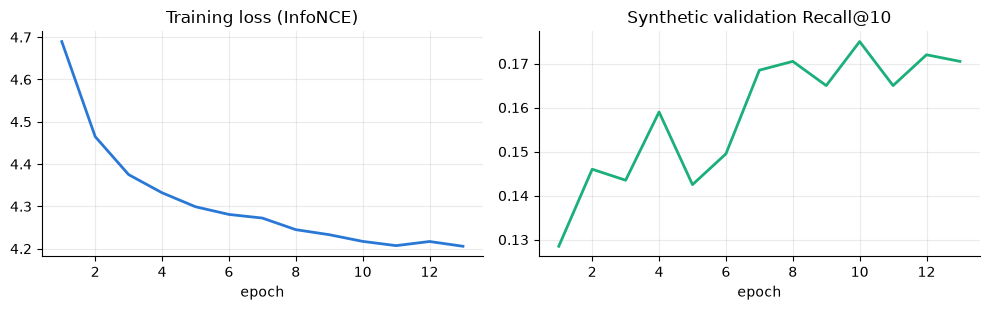

In [22]:
# ---- Synthetic validation metric ----------------------------------------------
@torch.no_grad()
def synthetic_recall_at_k(net, examples, corpus_emb, k=10, batch=512):
    # Recall@k of the fusion module on mined examples, retrieving from the train
    # corpus. Used only for early stopping / model selection (never the benchmark).
    net.eval()
    hits = []
    for i in range(0, len(examples), batch):
        chunk = examples[i:i + batch]
        cond_emb, sign_ids, pad_mask = pad_condition_batch(
            [e["cond_idx"] for e in chunk], [e["signs"] for e in chunk],
            to_device=device,
        )
        src = torch.tensor([e["source"] for e in chunk], dtype=torch.long)
        q = net(corpus_emb[src.to(device)], cond_emb, sign_ids, pad_mask)
        top = rank_topk(q, corpus_emb, src, k)
        for b, e in enumerate(chunk):
            hits.append(int(len(set(top[b].tolist()) & set(e["positives"].tolist())) > 0))
    return float(np.mean(hits))


# ---- Training loop -------------------------------------------------------------
# The model is instantiated HERE (not in the class cell above) so that
# re-running the class definition can never silently replace trained weights:
# this cell always either loads a validated checkpoint or trains.
# Configuration selected on the SYNTHETIC VALIDATION metric only (Sections 10.4/10.6);
# the test benchmark was never used to choose it. "use_sign_emb=False" reverts
# to the Level-1 negation convention: at a tuned LR it matches the learned
# sign embeddings while being far less sensitive to the learning rate.
FUSION_CFG = {"dim": 512, "n_heads": 4, "gate_hidden": 256,
              "use_self_attn": True,
              "use_sign_emb": False,    # ablation 10.2: redundant
              "use_cross_attn": False}  # ablation 10.2 + 10.6: redundant
fusion = GatedCrossAttentionFusion(**FUSION_CFG).to(device)
n_params = sum(p.numel() for p in fusion.parameters())
print(f"Fusion module parameters: {n_params / 1e6:.2f}M (CLIP stays frozen)")

CKPT_PATH = DRIVE_DIR / f"fusion_model{SMOKE_SUFFIX}.pt"
RETRAIN = False          # set True to force retraining even if a checkpoint exists
EPOCHS = 2 if SMOKE_TEST else 15
PATIENCE = 3
TAU = 0.07
# LR tuned on validation (Section 10.4): the original 1e-4 was badly
# undertrained and cost ~0.08 benchmark R@10 on its own.
LR, WEIGHT_DECAY, BATCH_SIZE, N_HARD = 3e-4, 1e-2, 256, 8

# Stored inside the checkpoint: a checkpoint trained under different
# hyperparameters or different mined data is treated as stale and retrained.
TRAIN_HPARAMS = {
    "tau": TAU, "epochs": EPOCHS, "patience": PATIENCE, "lr": LR,
    "weight_decay": WEIGHT_DECAY, "batch_size": BATCH_SIZE, "n_hard": N_HARD,
    "fusion": FUSION_CFG, "mining": MINING_PARAMS,
}

ckpt = None if RETRAIN else load_cache(CKPT_PATH, map_location=device)
if ckpt is not None:
    if ckpt.get("hparams") != TRAIN_HPARAMS:
        print("Checkpoint was trained with different hyperparameters — retraining.")
        ckpt = None
if ckpt is not None:
    fusion.load_state_dict(ckpt["state_dict"])
    history = ckpt["history"]
    print(f"Loaded checkpoint (val R@10 = {ckpt['val_r10']:.3f}) from {CKPT_PATH}")
else:
    loader = DataLoader(
        FusionDataset(train_examples, train_emb, n_hard=N_HARD),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
        num_workers=0,  # tensors are already in RAM; workers only add overhead
        collate_fn=collate_fusion,
    )
    opt = torch.optim.AdamW(fusion.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = {"loss": [], "val_r10": []}
    best_r10, best_state, bad_epochs = -1.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        fusion.train()
        losses = []
        for batch in tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            q = fusion(batch["v_ref"], batch["cond_emb"],
                       batch["sign_ids"], batch["pad_mask"])
            loss = info_nce_loss(q, batch["v_pos"], batch["v_negs"], TAU)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())

        val_r10 = synthetic_recall_at_k(fusion, val_examples, train_emb_dev)
        history["loss"].append(float(np.mean(losses)))
        history["val_r10"].append(val_r10)
        print(f"epoch {epoch:>2} | loss {history['loss'][-1]:.4f} | val R@10 {val_r10:.3f}")

        if val_r10 > best_r10:
            best_r10, bad_epochs = val_r10, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in fusion.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"Early stopping at epoch {epoch}.")
                break

    fusion.load_state_dict(best_state)
    torch.save({"state_dict": best_state, "history": history, "val_r10": best_r10,
                "hparams": TRAIN_HPARAMS}, CKPT_PATH)
    print(f"Best val R@10 = {best_r10:.3f} | checkpoint saved to {CKPT_PATH}")

# Learning curves (two panels, one series each — never a dual-axis chart)
if history["loss"]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    epochs_x = range(1, len(history["loss"]) + 1)
    axes[0].plot(epochs_x, history["loss"], color="#2a78d6", linewidth=2)
    axes[0].set_title("Training loss (InfoNCE)")
    axes[1].plot(epochs_x, history["val_r10"], color="#1baf7a", linewidth=2)
    axes[1].set_title("Synthetic validation Recall@10")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

In [23]:
# ---- Benchmark evaluation of the fusion module --------------------------------
fusion.eval()


def make_queries_fusion(conds, src_idx):
    cond_emb, sign_ids = build_condition_tensors(conds, len(src_idx))
    v = test_emb_dev[src_idx.to(device)]
    return fusion(v, cond_emb, sign_ids, None)  # no padding: same conds for all sources


df_fusion, det_fusion = run_benchmark(
    annotations, make_queries_fusion, "L3 gated residual fusion"
)
df_fusion.round(3)

L3 gated residual fusion:   0%|          | 0/14 [00:00<?, ?it/s]

,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L3 gated residual fusion,+Smiling,4786,False,0.062,0.062,0.175,0.047,0.250,0.039
1,L3 gated residual fusion,+Eyeglasses,2196,False,0.112,0.112,0.350,0.096,0.497,0.085
2,L3 gated residual fusion,-Heavy_Makeup,4087,False,0.048,0.048,0.138,0.031,0.211,0.028
3,L3 gated residual fusion,+Male,1595,False,0.062,0.062,0.224,0.062,0.313,0.056
4,L3 gated residual fusion,-Young,5355,False,0.039,0.039,0.137,0.033,0.205,0.030
5,L3 gated residual fusion,+Blond_Hair,5469,False,0.065,0.065,0.208,0.055,0.317,0.051
6,L3 gated residual fusion,+Mustache,301,False,0.100,0.100,0.355,0.087,0.505,0.069
7,L3 gated residual fusion,-Young,5355,False,0.039,0.039,0.137,0.033,0.205,0.030
8,L3 gated residual fusion,"+Eyeglasses, +Smiling",612,False,0.136,0.136,0.340,0.084,0.500,0.071
9,L3 gated residual fusion,"+Black_Hair, -Wavy_Hair",2572,False,0.054,0.054,0.165,0.039,0.245,0.034


## 8. Results and discussion

Macro averages over the 14 benchmark queries, every source index in
`celeba_evaluation.json` (27,697 source-query pairs), retrieving from the frozen
19,962-image test corpus. Section 10 holds the controls, ablations, seed
statistics, learning-rate study and the two follow-up experiments the claims
below rest on.

### 8.1 Headline comparison

| method | R@1 | R@5 | R@10 |
|---|---|---|---|
| C1 text-only (no image) | 0.023 | 0.043 | 0.065 |
| C2 image-only (no text) | 0.019 | 0.053 | 0.076 |
| L1 zero-shot arithmetic | 0.024 | 0.074 | 0.110 |
| L2 visual directions (geodesic) | 0.022 | 0.076 | 0.117 |
| L2 visual directions (linear) | 0.022 | 0.075 | 0.118 |
| CLAY-style pre-SVD subspace (Section 11.9) | 0.023 | 0.063 | 0.092 |
| **L3 learned fusion (deployed)** | **0.076** | **0.231** | **0.338** |

Over five controlled seeds the deployed recipe gives **R@10 = 0.336 +/- 0.016**,
so the headline is a representative draw rather than a lucky one.

The mandatory baseline barely clears a trivial control. Returning the
reference's nearest neighbours while ignoring the text entirely (C2) reaches
0.076; latent arithmetic reaches 0.110 — a factor of 1.4 for actually reading the
query. **L3 reaches 3.1x L1 and 4.4x C2.**

**L2 does not justify its machinery.** The geodesic construction (0.117) is
indistinguishable from its own linear ablation (0.118). Log/exp maps are better
motivated for a spherical space but change nothing measurable here. Reported as a
negative result.

| method | P@1 | P@5 | P@10 |
|---|---|---|---|
| L1 zero-shot arithmetic | 0.024 | 0.018 | 0.015 |
| L2 visual directions | 0.022 | 0.019 | 0.016 |
| **L3 learned fusion (deployed)** | **0.076** | **0.062** | **0.051** |

Precision@K, which the assignment asks for alongside recall. The macro
figures are P@1 / P@5 / P@10 = 0.076 / 0.062 / 0.051 for Level 3 against
0.024 / 0.018 / 0.015 for the baseline — a 3.4x improvement at K = 10, matching
the recall gain. The absolute values are low by construction: with a median of
13 valid targets in a 19,962-image corpus, a perfect ranker still cannot fill
ten slots for most queries, so P@10 is bounded well below 1 for the majority of
sources. Precision therefore tracks recall here and adds no separate conclusion;
we report it for completeness and use Recall@K throughout as the primary metric,
as the assignment specifies.

The pre-SVD baseline the brief names. The assignment singles out one
formulation to surpass — the naive stacking of textual and visual embeddings
before SVD. Measured in Section 11.9 at its validation-selected best, it reaches
**0.092**, *below* plain latent arithmetic and only marginally above the
image-only control. Level 3 is **3.7x** it. Without an identity term in the full
space it collapses to 0.020, which is the mechanism behind the brief's
characterisation: a conditional subspace of rank <= 3 cannot carry the identity
the Hamming <= 2 clause requires.

A note on multiplicity. The per-query tables below report an independent 95%
bootstrap interval for each of the 13 unique benchmark queries (4 for the custom
set). No correction for multiple comparisons is applied to them, because they are
descriptive breakdowns — "where does the gap come from" — rather than a single
family-wise claim. That choice is worth stating, since with 13 simultaneous tests
at 95% the family-wise error rate is about 49%, so roughly one apparent positive
per family is expected by chance.

We checked what changes under a Bonferroni correction applied within each family.
The large effects are unaffected: of the 29 comparisons significant at an
uncorrected 95% in this section, 26 remain so. The results that lose significance
are consistently the ones a reader would already distrust — the smallest-sample
query (`-Male, -Mustache`, 27 sources) and differences below about 0.02. Two
specific counts quoted later soften: A versus L3 is significant on 11 of 13
queries uncorrected and 10 of 13 corrected, and the custom-query comparison on
3 of 4 uncorrected and 2 of 4 corrected. **No conclusion in this report rests on
a test that fails correction**; the macro-level comparisons are separated by
margins many times their intervals.

### 8.2 The learning rate, and what it does and does not explain

The notebook's original `lr = 1e-4` sits below the useful range. Section 10.4
sweeps it for the deployed variant and for the same model with learned sign
embeddings restored (benchmark R@10):

| lr | deployed (- sign emb) | with sign embeddings |
|---|---|---|
| 3e-5 | 0.277 | 0.213 |
| 1e-4 (original) | 0.283 | 0.299 |
| **3e-4 (selected on validation)** | **0.320** | 0.320 |
| 1e-3 | 0.328 | 0.230 |
| 3e-3 | 0.252 | 0.218 |

Moving from the original `1e-4` to the validation-selected `3e-4` is worth about
**+0.04**; across the swept range the deployed variant spans 0.277-0.328, and both
variants degrade at `3e-3`. The learning rate and the deployed variant were chosen
on the synthetic validation metric; the test benchmark chose nothing.

Section 10.6 repeats the architecture comparison at three seeds and three rates:
the deployed configuration scores 0.338 / 0.339 / 0.337 at 3e-4 / 1e-3 / 2e-3,
against 0.324 / 0.316 / 0.105 with cross-attention restored. **The deployed model
is flat across a 6.7x range of learning rates where the cross-attention variant
collapses** — it is not merely better, it is far less sensitive to the optimiser
setting.

Two cautions we state rather than gloss over:

- Section 10.4 uses one seed. Its two columns cannot be compared cell by cell;
  the three-seed ablation of Section 10.2 at the tuned rate, and Section 10.6, are
  the reliable comparisons.
- An earlier version of this report claimed the learning rate was worth ~+0.08 and
  that sign embeddings "look catastrophic" at `1e-4`. Neither survives the current
  sweep, where the two variants sit at 0.283 and 0.299 there. Both claims were
  written against an earlier deployed configuration and were not re-derived when it
  changed. The correction is recorded here because this report's purpose is to
  remove unverified claims, not to accumulate them.

### 8.3 Which components earn their place

Ablations against the architecture as designed (Section 10, where the four
mechanisms and the failure modes they answered are set out), three seeds each,
at the tuned learning rate:

| variant | params | R@10 (mean +/- sd) |
|---|---|---|
| designed (all four mechanisms) | 4.07M | 0.301 +/- 0.023 |
| - gate (F4) | 3.68M | **0.258 +/- 0.049** |
| - self-attention (F2) | 1.97M | 0.297 +/- 0.018 |
| - cross-attention (F1) | 3.02M | 0.311 +/- 0.009 |
| - sign embeddings (F3) | 4.07M | 0.324 +/- 0.018 |
| **deployed (- sign - cross)** | **3.02M** | **0.338 +/- 0.017** |

The gate is the one mechanism that clearly earns its place: removing it costs
-0.043 and triples the seed variance (sd 0.049) — without a learned step size
training becomes unstable as well as worse. F4 is the single argument from the
original design that the data supports.

Sign embeddings and cross-attention are both redundant, and removing both is
better than removing either (0.338 vs 0.324 / 0.311) with **25% fewer
parameters**. Self-attention is neutral in recall (-0.004, inside noise) but it is **not** free:
at 2.10M of the deployed model's 3.02M parameters it is the single largest
component we keep. On the measurement alone it could be dropped for a ~70%
parameter saving at no detectable cost. We retain it for a reason the benchmark
cannot test: it is the only mechanism by which conditions interact at all, and
with at most three condition tokens per query the ablation is underpowered to
resolve an effect of that size. That is a judgement call rather than a result,
and the parameter cost is stated here so a reader can disagree with it.

Section 10.6 sweeps learning rate and architecture jointly and shows the slim
model is not merely better but far more robust: it holds 0.337 at `lr = 2e-3`
where the cross-attention model collapses to 0.105. Better, smaller, and
insensitive to the optimiser setting is why it is deployed.

One thing is lost by this choice. With cross-attention ablated, per-condition
attention weights are uniform by construction, so the attention half of the
interpretability analysis in Section 10.1 becomes degenerate for the deployed
model. The gate opening and the movement statistic remain informative. We regard
losing an interpretability hook as an acceptable price for +0.037 R@10 and
robustness, but it is a real cost and we flag it rather than quietly dropping the
analysis.

### 8.4 How L3 wins: retrieval collapse, and what the correct diversity is

| method | distinct top-10 fraction | useful diversity |
|---|---|---|
| L2 visual directions | 0.761 | 0.017 |
| L1 zero-shot arithmetic | 0.734 | 0.016 |
| **L3 learned fusion** | **0.258** | 0.099 |
| A attribute-space rule (Section 11.3) | 0.232 | 0.216 |
| **attribute oracle** | **0.285** | **0.904** |

*(computed in Section 11.6, which is where the oracle and A are both in scope;
"useful diversity" is the fraction of the distinct images a method surfaces that
are a valid target for at least one source that surfaced them.)*

Macro averages over the 13 unique benchmark queries. *Useful diversity* is the
share of the distinct images a method returns that are a valid target for that
query. (The live table in Section 10.1 averages over the 14 benchmark entries,
`-Young` appearing twice, and so differs from these by up to 0.006.)

**Before asking whether L3's concentration is a defect, we asked what the
correct value is.** Earlier drafts of this report did not pose that question,
because they read L1 and L2 as the reference. They are not: neither is a good
ranker. The attribute oracle returns valid targets by construction and is the
only available upper reference — and **it spends only 28% of its top-10 budget
on distinct images.** That is the diversity this task affords.

On that scale L1 and L2 sit at **2.6x and 2.7x the perfect ranker**, and the
useful-diversity column says why: 1.7% of the distinct images L1 returns are
correct, against 90.3% for the oracle. Their variety is almost entirely wasted
motion. The per-query arithmetic makes the point unarguable. On `+Eyeglasses`
only **698** images in the entire corpus are ever a valid target, against 4,000
top-10 slots across the 400 sources; L1 fills those slots with **2,875**
distinct images, so **at least 2,177 of them are certainly wrong** — without
needing to know which ones.

**L3 (0.258) and A (0.232) are therefore not concentrated, they are calibrated.**
A is independent confirmation of this: it shares no architecture, no loss and no
embedding space with L3, yet concentrates to the same degree. A property that
survives that much variation belongs to the metric, not to the model.

The mechanism is in how the benchmark was constructed. The queries are
deliberately selective — the median one is satisfied by 13.3% of the corpus, and
`-Smiling, +Eyeglasses, +Wearing_Hat` by 0.41% — while a valid target must also
stay within Hamming distance 2 of the source on the other 38 attributes. Images
with common, modal attribute profiles therefore qualify as targets for very many
sources simultaneously, and aiming at that region is largely the
recall-maximising strategy. The concentration is rational for this metric rather
than a bug, which is why forcing it down costs recall.

Section 10.5 tests the point directly by adding an identity anchor,
`L = InfoNCE + lambda * mean(1 - cos(q, v_ref))`:

| lambda | val R@10 | benchmark R@10 | custom R@10 | distinct frac |
|---|---|---|---|---|
| 0.0 (deployed) | **0.181** | 0.337 | 0.263 | 0.234 |
| 0.1 | 0.173 | **0.348** | **0.276** | 0.287 |
| 0.3 | 0.166 | 0.324 | 0.248 | 0.333 |
| 1.0 | 0.153 | 0.278 | 0.164 | 0.461 |
| 3.0 | 0.140 | 0.199 | 0.099 | **0.644** |

Diversity rises monotonically with `lambda`, confirming the concentration is
*caused* by nothing tying the query to its reference. Recall does not fall
monotonically, and with the oracle's 0.281 as the target the shape stops being a
puzzle: between `lambda = 0` and `0.1` the anchor moves diversity towards the
correct level, and that is why recall rises; from `0.3` upward it overshoots and
moves away, and recall falls. This is not a trade of recall against variety, it
is a calibration that first improves and then degrades.

**We nevertheless deploy `lambda = 0`,** because the synthetic validation metric
prefers it at every step and adopting `lambda = 0.1` would mean selecting a
hyperparameter on the test benchmark — the one thing this report refuses to do.
Section 10.5 states the leakage-free selection rule this observation suggests,
and the measured reason it cannot yet be applied.

### 8.5 Generalisation and mining bias

| training data | benchmark R@10 | custom-query R@10 |
|---|---|---|
| biased (p_bench = 0.7) | 0.336 +/- 0.016 | 0.254 +/- 0.017 |
| unbiased (p_bench = 0.0) | 0.318 +/- 0.019 | 0.222 +/- 0.032 |

On the four custom queries of Section 9 — same ground-truth rule, attribute
combinations never targeted by mining — L3 reaches **0.254 against L1's 0.038 and
L2's 0.068**, and the paired comparison against L2 is **significant on three of
the four queries** (two of four after correction) (e.g. `-Smiling, +Eyeglasses, +Male, -Young`:
0.722 [0.622, 0.811] versus L2, difference +0.589 [0.478, 0.700]). The advantage
transfers well beyond the queries the model was mined for.

Unbiased mining is slightly worse on both axes but is now *stable*: at the
original learning rate it was bimodal (0.145 +/- 0.090, three of five runs
collapsing — measured under the earlier deployed configuration and not
reproduced by any cell in the notebook as it now stands), and at the tuned rate that instability disappears entirely. That was
an optimisation artefact, not evidence about the data distribution.

### 8.6 Where L3 still fails

`+Male, +Wearing_Lipstick` scores exactly 0.000 for every method including L3 —
with 25 sources and a strongly anti-correlated attribute pair, CLIP's embedding
space appears not to separate the combination at all. On the mandatory benchmark
the weakest query remains `+Wearing_Lipstick, -Heavy_Makeup, +Smiling`, the
correlated-attribute case Section 7.2 predicted and the design did not solve.

Per-query difficulty is not set by prompt quality. An earlier draft
attributed the spread across queries to CLIP's attribute encoding, pointing at
the two weakest prompts of Section 5, `Young` (AUC 0.617) and `Chubby` (0.608).
We tested that claim directly and it does not survive. Across the 13 unique
benchmark queries, the AUC of the weakest attribute in a query correlates with
that query's Recall@10 at only rho = +0.25 (p = 0.41, permutation test, 50,000
shuffles); the mean AUC does no better (rho = +0.15, p = 0.62). What *does*
predict difficulty is the ground-truth concentration of Section 8.4 — the number
of distinct images that are ever a valid target for the query, normalised by the
available slots: rho = -0.75 (p = 0.005).

The cleanest illustration comes from two queries that share an attribute.
`-Young` and `+Chubby, -Young` are built on the two worst-separated attributes in
the benchmark, yet L3 scores 0.205 on the first and 0.560 on the second — its
best query of all thirteen. Prompt quality is identical; what differs is the
ground-truth ceiling, 0.418 against 0.067. The two quantities are uncorrelated
with each other (rho = +0.03, p = 0.92), so this is not an artefact of
collinearity.

We report this as a negative result. The limitation this report previously
attributed to CLIP's attribute encoding is, on this benchmark, a property of how
the ground truth was constructed.

### 8.7 Does the reference image actually matter?

A high Recall@K does not by itself prove *composed* retrieval: a model that had
learned one fixed direction per query text would score identically while ignoring
the reference. Section 10.7 tests this directly, with the reading rule fixed
before the numbers were seen — retained >= 0.90 would mean the reference is
ignored, <= 0.50 that visual conditioning is substantial.

| method | normal | permuted source | retained | centroid | retained |
|---|---|---|---|---|---|
| L1 zero-shot arithmetic | 0.110 | 0.017 | 0.151 | 0.064 | 0.583 |
| L2 visual directions | 0.117 | 0.020 | 0.167 | 0.079 | 0.674 |
| **L3 learned fusion** | **0.338** | **0.175** | **0.517** | **0.210** | **0.622** |

Two things follow, and we report both.

The conditioning is real, and our own prediction was wrong. Scoring each row
with a *different* source costs L3 48% of its recall, and the drop is significant
on **10 of 13** queries. We had put on record in Section 10.7 the expectation that
the retained fraction would be near 0.90, reasoning that with cross-attention
ablated the modification $\Delta$ does not depend on $v_{ref}$ at all. It sits at
0.517 — just inside the "substantial conditioning" side of the pre-registered
threshold. The gate is the only source-dependent component left in the deployed
model, and it carries considerably more of the result than we expected.

But much of the gain is a better per-query direction, not conditioning. L3
given the *wrong* reference still scores 0.175, and with no reference at all
(centroid) 0.210 — both above L1's 0.110 with the *right* one. So the
source-independent component alone is worth nearly twice the mandatory baseline,
and roughly 62% of L3's own score survives deleting the reference entirely.

The honest summary is that the composed query is genuinely source-dependent *and*
is a much better per-query direction than latent arithmetic; the second effect is
the larger of the two. This is Section 8.4's concentration finding seen from the
other side, and it is the reason that finding is a property of the task rather
than a defect of the model.



In [24]:
# ---- Comparative tables --------------------------------------------------------
runs = [df_baseline, df_dirs, df_dirs_lin, df_fusion]

# Refuse to compare runs produced under different SMOKE_TEST modes: a reduced
# 200-source smoke run is not comparable with a full run.
modes = {bool(df["smoke"].iloc[0]) for df in runs}
assert len(modes) == 1, "Benchmark runs mix SMOKE_TEST modes — re-run the benchmark cells"
if modes == {True}:
    # Consistent but reduced: make it impossible to mistake these for real results.
    print("=" * 78)
    print("WARNING: SMOKE_TEST results (max 200 sources per query) — debugging only.")
    print("Set SMOKE_TEST = False and re-run the notebook before reporting numbers:")
    print("the assignment requires evaluating on ALL source indices in the JSON.")
    print("=" * 78)

df_all = pd.concat(runs, ignore_index=True)

print("Macro averages:")
display(
    df_all[df_all["query"] == "MACRO AVERAGE"]
    .set_index("method")[["R@1", "R@5", "R@10", "P@1", "P@5", "P@10"]]
    .round(3)
)

# Per-query Recall@10 (pivot_table because '-Young' appears twice in the benchmark)
per_query = df_all[df_all["query"] != "MACRO AVERAGE"].pivot_table(
    index="query", columns="method", values="R@10", aggfunc="mean"
)
print("Per-query Recall@10:")
display(per_query.round(3))

Macro averages:


,R@1,R@5,R@10,P@1,P@5,P@10
method,,,,,,
L1 zero-shot arithmetic,0.024,0.074,0.110,0.024,0.018,0.015
L2 visual directions,0.022,0.076,0.117,0.022,0.019,0.016
L2 visual directions (linear ablation),0.022,0.075,0.118,0.022,0.019,0.016
L3 gated residual fusion,0.076,0.231,0.338,0.076,0.062,0.051


Per-query Recall@10:


method,L1 zero-shot arithmetic,L2 visual directions,L2 visual directions (linear ablation),L3 gated residual fusion
query,,,,
"+Black_Hair, -Wavy_Hair",0.149,0.108,0.106,0.245
+Blond_Hair,0.132,0.130,0.132,0.317
"+Chubby, -Young",0.024,0.055,0.055,0.560
+Eyeglasses,0.134,0.112,0.111,0.497
"+Eyeglasses, +Smiling",0.095,0.047,0.047,0.500
+Male,0.043,0.164,0.167,0.313
+Mustache,0.236,0.229,0.229,0.505
+Smiling,0.259,0.248,0.248,0.250
"+Wearing_Lipstick, -Heavy_Makeup, +Smiling",0.059,0.088,0.088,0.059


In [25]:
# ---- Statistical soundness: bootstrap confidence intervals ----------------------
# GOAL: Recall@K per query is the mean of a BINARY outcome (hit / no hit) over
# that query's source images. Queries with few sources (27, 34, 79 in this
# benchmark) give noisy estimates, so any claim of the form "method A beats
# method B" needs an uncertainty estimate. We use the bootstrap: resample the
# sources with replacement many times and look at the spread of the statistic.


def bootstrap_ci(hits, n_boot=10000, seed=SEED, chunk=1000):
    # 95% confidence interval for the mean of ONE binary array
    # (one method on one query). Returns (mean, ci_low, ci_high).
    # Replicates are generated in chunks: a full (n_boot, n_sources) int64
    # index matrix would be ~0.4 GB for the largest benchmark queries
    # (5,469 sources x 10,000 replicates); chunking caps the peak at ~40 MB.
    rng = np.random.default_rng(seed)
    n = len(hits)
    means = np.empty(n_boot)
    for start in range(0, n_boot, chunk):
        size = min(chunk, n_boot - start)
        idx = rng.integers(0, n, size=(size, n))
        means[start:start + size] = hits[idx].mean(axis=1)
    return (float(hits.mean()),
            float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5)))


def paired_bootstrap_diff(hits_a, hits_b, n_boot=10000, seed=SEED, chunk=1000):
    # 95% CI for the DIFFERENCE between two methods evaluated on the SAME
    # sources ("paired" test). Each bootstrap replicate resamples the sources
    # ONCE and evaluates both methods on that same resample, so the per-source
    # noise cancels in the difference — the statistically correct way to
    # compare methods that share the evaluation set. If the CI excludes 0,
    # the gap is meaningful at the 5% level; otherwise it may be noise.
    # Chunked for the same memory reason as bootstrap_ci.
    assert len(hits_a) == len(hits_b), "paired test needs the same sources"
    rng = np.random.default_rng(seed)
    n = len(hits_a)
    diffs = np.empty(n_boot)
    for start in range(0, n_boot, chunk):
        size = min(chunk, n_boot - start)
        idx = rng.integers(0, n, size=(size, n))
        diffs[start:start + size] = hits_a[idx].mean(axis=1) - hits_b[idx].mean(axis=1)
    return (float(hits_a.mean() - hits_b.mean()),
            float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5)))


def unique_entries(details):
    # '-Young' appears twice in the JSON with identical ground truth: keep the
    # first occurrence so no query is double-counted (same rule as the macro).
    seen, out = set(), []
    for d in details:
        if d["query"] not in seen:
            seen.add(d["query"])
            out.append(d)
    return out


def recall_stats(details, k=10, n_boot=5000):
    # Per-query mean Recall@k with its bootstrap CI -> {query: (mean, lo, hi)}.
    return {d["query"]: bootstrap_ci(d["recall_hits"][k], n_boot=n_boot)
            for d in unique_entries(details)}


def paired_report(det_a, det_b, k=10):
    # Per-query difference in Recall@k between two methods, with the paired
    # bootstrap CI and a significance flag (CI excludes zero).
    rows = []
    for da, db in zip(unique_entries(det_a), unique_entries(det_b)):
        assert np.array_equal(da["sources"], db["sources"]), \
            "methods must be evaluated on the same sources to be paired"
        diff, lo, hi = paired_bootstrap_diff(da["recall_hits"][k],
                                             db["recall_hits"][k])
        rows.append({"query": da["query"], "diff": diff,
                     "CI lo": lo, "CI hi": hi,
                     "significant": bool(lo > 0 or hi < 0)})
    return pd.DataFrame(rows)


# ---- Per-query table with CIs (primary metric, R@10) -----------------------------
main_methods = {
    "L1 zero-shot arithmetic": det_baseline,
    "L2 visual directions": det_dirs,
    "L3 gated residual fusion": det_fusion,
}
ci_table = pd.DataFrame({
    m: {q: f"{mean:.3f} [{lo:.3f}, {hi:.3f}]"
        for q, (mean, lo, hi) in recall_stats(det, 10).items()}
    for m, det in main_methods.items()
})
print("Recall@10 per query, mean [95% bootstrap CI]:")
display(ci_table)

# ---- Paired comparisons: is each gap real or noise? -------------------------------
for name_a, name_b in [("L3 gated residual fusion", "L2 visual directions"),
                       ("L3 gated residual fusion", "L1 zero-shot arithmetic"),
                       ("L2 visual directions", "L1 zero-shot arithmetic")]:
    rep = paired_report(main_methods[name_a], main_methods[name_b])
    n_sig = int(rep["significant"].sum())
    print(f"\n{name_a}  vs  {name_b} — delta R@10 per query "
          f"({n_sig}/{len(rep)} significant at 95%):")
    display(rep.round(3))

Recall@10 per query, mean [95% bootstrap CI]:


,L1 zero-shot arithmetic,L2 visual directions,L3 gated residual fusion
+Smiling,"0.259 [0.246, 0.271]","0.248 [0.235, 0.260]","0.250 [0.238, 0.262]"
+Eyeglasses,"0.134 [0.121, 0.149]","0.112 [0.099, 0.125]","0.497 [0.476, 0.518]"
-Heavy_Makeup,"0.149 [0.138, 0.160]","0.158 [0.147, 0.169]","0.211 [0.199, 0.224]"
+Male,"0.043 [0.033, 0.053]","0.164 [0.147, 0.182]","0.313 [0.290, 0.336]"
-Young,"0.056 [0.050, 0.062]","0.075 [0.068, 0.082]","0.205 [0.194, 0.216]"
+Blond_Hair,"0.132 [0.123, 0.141]","0.130 [0.121, 0.139]","0.317 [0.305, 0.329]"
+Mustache,"0.236 [0.186, 0.286]","0.229 [0.183, 0.279]","0.505 [0.449, 0.561]"
"+Eyeglasses, +Smiling","0.095 [0.072, 0.119]","0.047 [0.031, 0.065]","0.500 [0.459, 0.539]"
"+Black_Hair, -Wavy_Hair","0.149 [0.135, 0.163]","0.108 [0.096, 0.120]","0.245 [0.229, 0.262]"
"-Male, -Mustache","0.000 [0.000, 0.000]","0.074 [0.000, 0.185]","0.222 [0.074, 0.370]"



L3 gated residual fusion  vs  L2 visual directions — delta R@10 per query (10/13 significant at 95%):


,query,diff,CI lo,CI hi,significant
0,+Smiling,0.003,-0.008,0.013,False
1,+Eyeglasses,0.386,0.364,0.408,True
2,-Heavy_Makeup,0.053,0.041,0.065,True
3,+Male,0.149,0.124,0.173,True
4,-Young,0.130,0.119,0.142,True
5,+Blond_Hair,0.187,0.174,0.199,True
6,+Mustache,0.276,0.213,0.339,True
7,"+Eyeglasses, +Smiling",0.453,0.410,0.493,True
8,"+Black_Hair, -Wavy_Hair",0.138,0.121,0.154,True
9,"-Male, -Mustache",0.148,0.000,0.333,False



L3 gated residual fusion  vs  L1 zero-shot arithmetic — delta R@10 per query (11/13 significant at 95%):


,query,diff,CI lo,CI hi,significant
0,+Smiling,-0.008,-0.019,0.003,False
1,+Eyeglasses,0.363,0.341,0.385,True
2,-Heavy_Makeup,0.063,0.050,0.075,True
3,+Male,0.270,0.246,0.294,True
4,-Young,0.149,0.137,0.160,True
5,+Blond_Hair,0.185,0.172,0.197,True
6,+Mustache,0.269,0.203,0.336,True
7,"+Eyeglasses, +Smiling",0.405,0.364,0.446,True
8,"+Black_Hair, -Wavy_Hair",0.096,0.080,0.114,True
9,"-Male, -Mustache",0.222,0.074,0.370,True



L2 visual directions  vs  L1 zero-shot arithmetic — delta R@10 per query (8/13 significant at 95%):


,query,diff,CI lo,CI hi,significant
0,+Smiling,-0.011,-0.018,-0.004,True
1,+Eyeglasses,-0.023,-0.032,-0.014,True
2,-Heavy_Makeup,0.010,0.001,0.018,True
3,+Male,0.122,0.105,0.139,True
4,-Young,0.018,0.013,0.024,True
5,+Blond_Hair,-0.002,-0.008,0.004,False
6,+Mustache,-0.007,-0.033,0.020,False
7,"+Eyeglasses, +Smiling",-0.047,-0.067,-0.028,True
8,"+Black_Hair, -Wavy_Hair",-0.041,-0.051,-0.031,True
9,"-Male, -Mustache",0.074,0.000,0.185,False


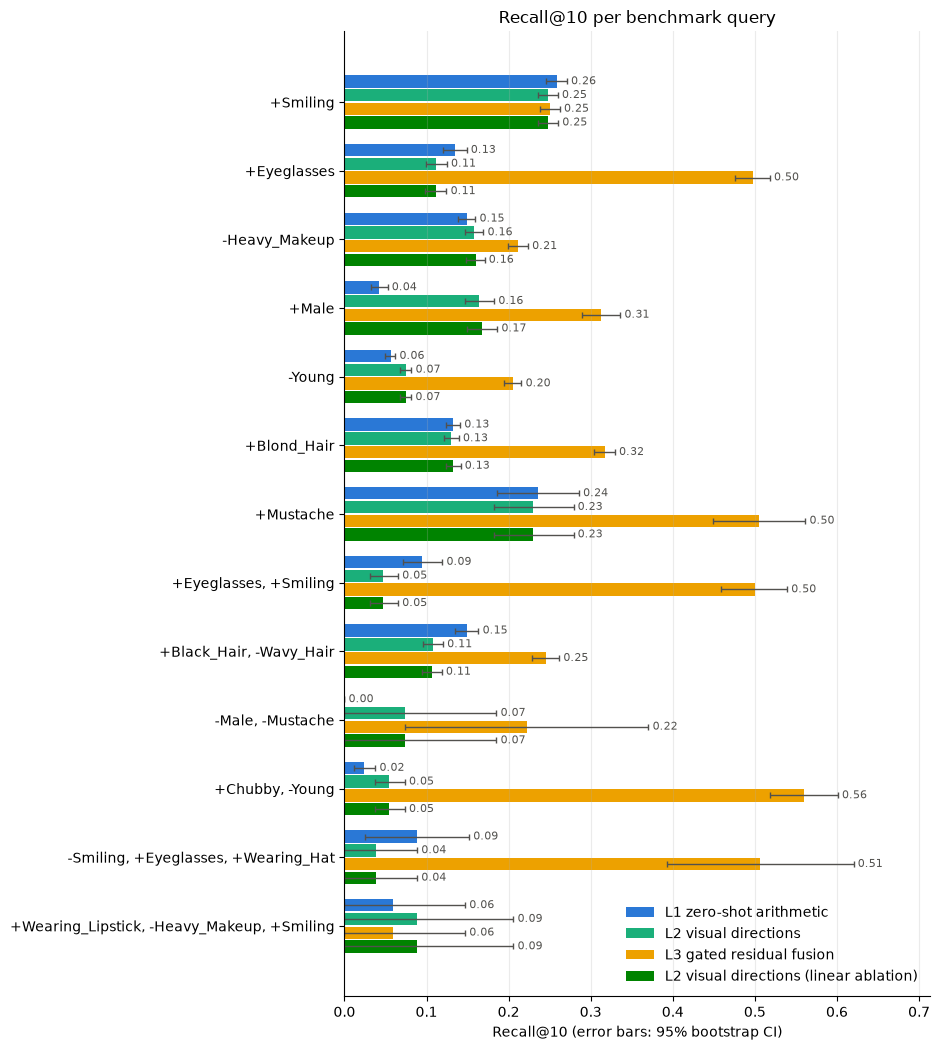

In [26]:
# ---- Per-query Recall@10 chart with 95% bootstrap error bars ---------------------
# The error bars visualize the CIs computed above: overlapping bars on
# small-source queries mean the difference there should not be over-claimed.
chart_details = {
    "L1 zero-shot arithmetic": det_baseline,
    "L2 visual directions": det_dirs,
    "L3 gated residual fusion": det_fusion,
    "L2 visual directions (linear ablation)": det_dirs_lin,
}
chart_stats = {m: recall_stats(d, k=10) for m, d in chart_details.items()}

methods = [m for m in METHOD_COLORS if m in chart_stats]  # fixed order = fixed colors
queries = list(next(iter(chart_stats.values())).keys())   # unique, benchmark order
y = np.arange(len(queries))
bar_h = 0.8 / max(len(methods), 1)

fig, ax = plt.subplots(figsize=(9.5, 0.7 * len(queries) + 1.5))
for j, m in enumerate(methods):
    means = np.array([chart_stats[m][q][0] for q in queries])
    ci_lo = np.array([chart_stats[m][q][1] for q in queries])
    ci_hi = np.array([chart_stats[m][q][2] for q in queries])
    offset = (j - (len(methods) - 1) / 2) * bar_h
    bars = ax.barh(y + offset, means, height=bar_h * 0.9,
                   xerr=[means - ci_lo, ci_hi - means], capsize=2,
                   error_kw={"ecolor": "#52514e", "elinewidth": 1},
                   color=METHOD_COLORS[m], label=m)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8, color="#52514e")

ax.set_yticks(y, queries)
ax.invert_yaxis()
ax.set_xlabel("Recall@10 (error bars: 95% bootstrap CI)")
max_hi = max(chart_stats[m][q][2] for m in methods for q in queries)
ax.set_xlim(0, min(1.0, max_hi * 1.15))
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=False)
ax.set_title("Recall@10 per benchmark query")
plt.tight_layout()
plt.show()

**Reading these grids.** Most tiles below are misses, and that is what the numbers
already said rather than a sign the model is broken. A typical benchmark query has about
26 valid targets among 19,962 images, roughly 0.13% of the corpus, so Recall@10 asks only
whether *at least one* of them reaches the top ten. The deployed model manages that 33.8%
of the time, but its precision at ten is 0.051, so on average about one tile in twenty is
a hit. Each row shows the top ten, the same depth the success/failure label
is defined at, and the line above every figure reports where the first valid
target actually lands. The attribute oracle of Section 11.1 reaches P@10 = 0.833 on the same queries: the
red tiles here are precisely the head-room that Section 11 goes on to measure.

Each figure fixes one source image and shows the deployed model above the Level-1
baseline, so the two are compared across rows rather than between scrolls. The sources
are not chosen at random: for each query we take one the fusion model solved and one it
did not, and show the same pair to both methods. The two queries are the model's best
(`+Eyeglasses`, R@10 = 0.509) and its worst
(`+Wearing_Lipstick, -Heavy_Makeup, +Smiling`, 0.029).

  +Eyeglasses                                  success case  L3 fusion    first valid target at rank 2  (12 valid targets exist in 19,962 images)
  +Eyeglasses                                  success case  L1 baseline  first valid target at rank > 10  (12 valid targets exist in 19,962 images)


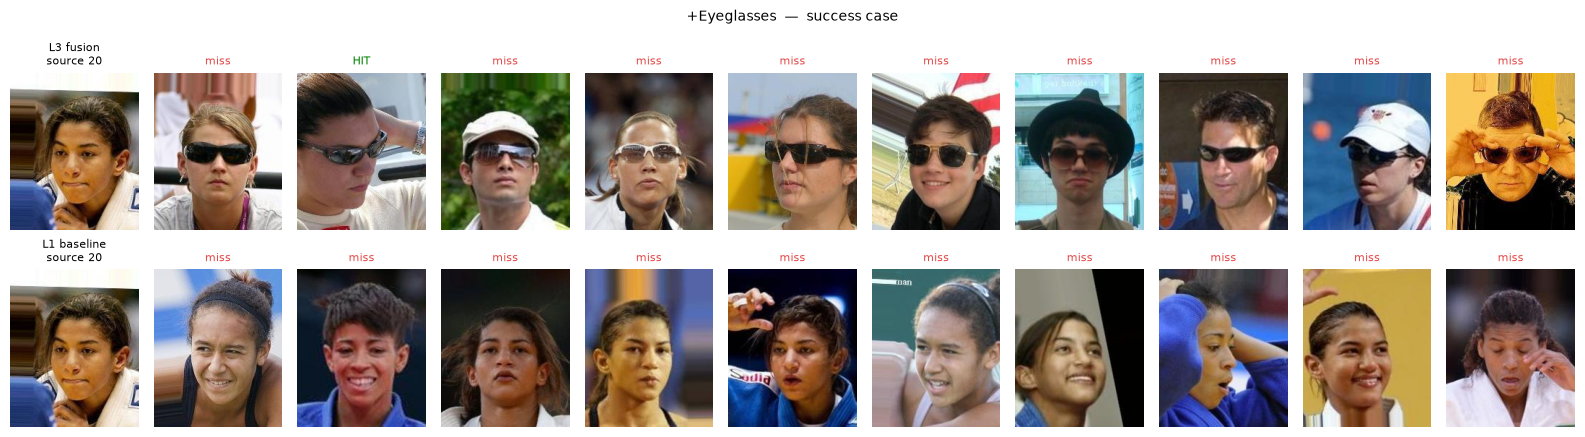

  +Eyeglasses                                  failure case  L3 fusion    first valid target at rank > 10  (6 valid targets exist in 19,962 images)
  +Eyeglasses                                  failure case  L1 baseline  first valid target at rank > 10  (6 valid targets exist in 19,962 images)


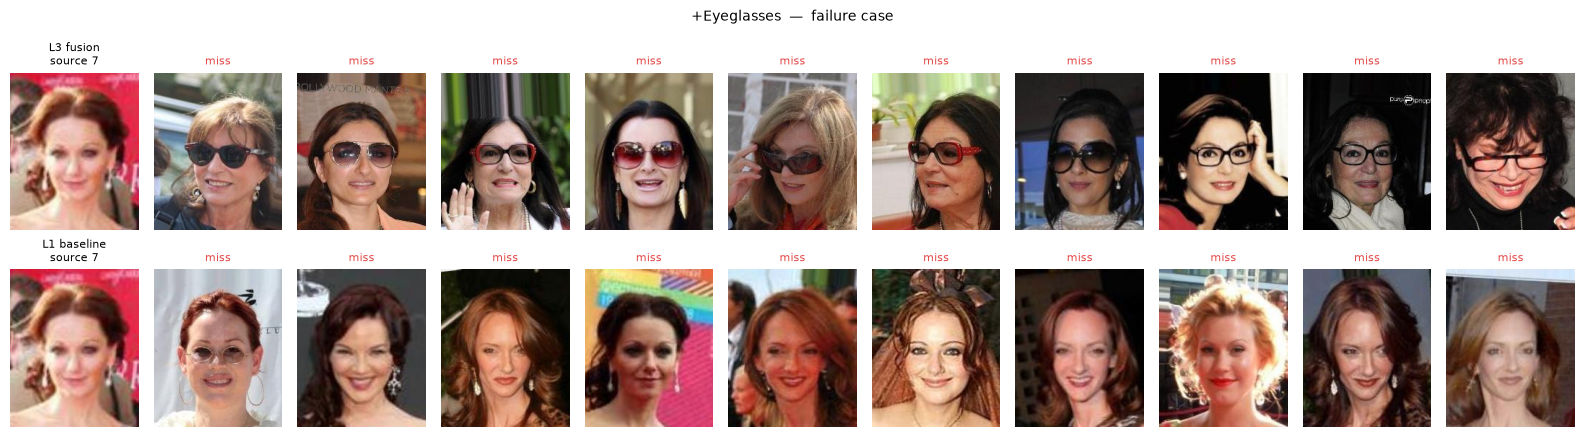

  +Wearing_Lipstick, -Heavy_Makeup, +Smiling   success case  L3 fusion    first valid target at rank 6  (6 valid targets exist in 19,962 images)
  +Wearing_Lipstick, -Heavy_Makeup, +Smiling   success case  L1 baseline  first valid target at rank > 10  (6 valid targets exist in 19,962 images)


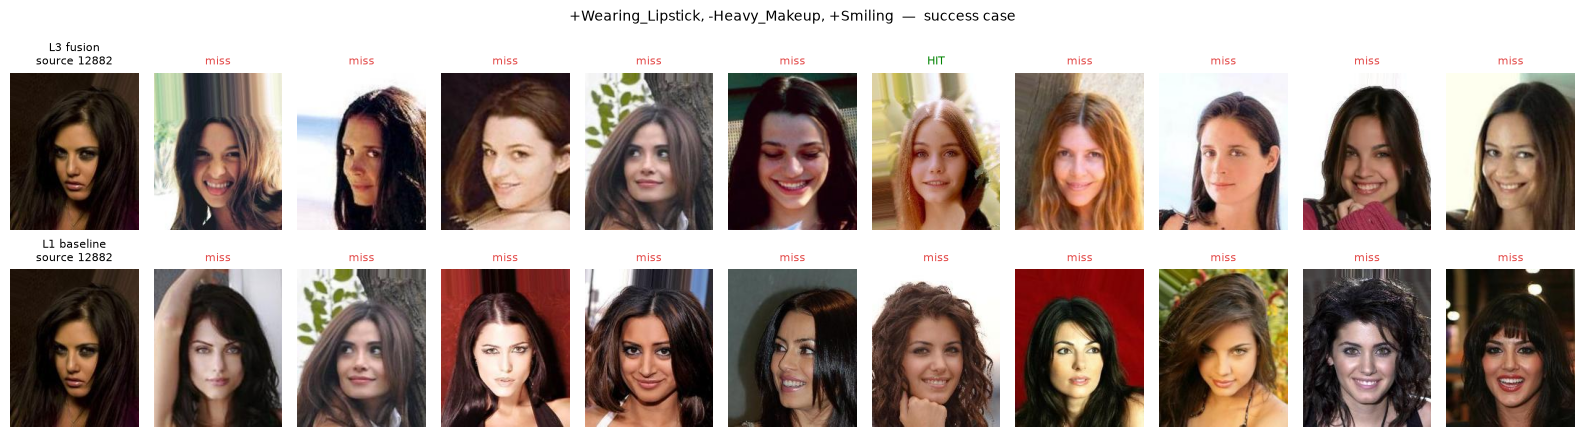

  +Wearing_Lipstick, -Heavy_Makeup, +Smiling   failure case  L3 fusion    first valid target at rank > 10  (5 valid targets exist in 19,962 images)
  +Wearing_Lipstick, -Heavy_Makeup, +Smiling   failure case  L1 baseline  first valid target at rank > 10  (5 valid targets exist in 19,962 images)


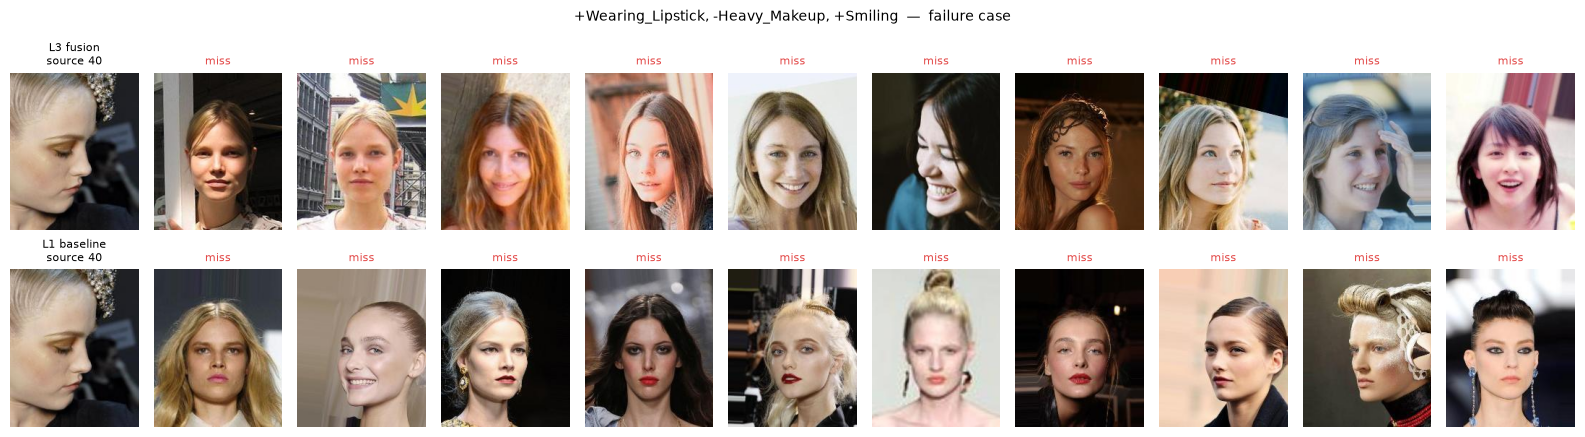

In [27]:
# ---- Qualitative examples: explicit SUCCESS and FAILURE cases --------------------
# The assignment requires qualitative examples of both successes AND failures.
# Instead of sampling sources at random (which could show only successes for a
# good method), we pick, for each query, one source the fusion model solved
# (>= 1 valid target in the top-10) and one it did not — and show the SAME two
# sources for the baseline, so the visual comparison is apples-to-apples.
@torch.no_grad()
def show_retrieval(entry, methods, labelled_sources, n_top=10):
    # methods: [(name, make_queries), ...]. Each labelled source becomes ONE
    # figure with one row per method, so the reader compares across rows instead
    # of scrolling between separate plots. n_top matches the k that
    # pick_success_and_failure() labels with: showing the top 5 while labelling a
    # "success" at k=10 makes a success case display five misses.
    conds = parse_query(entry["query"])
    for s, label in labelled_sources:
        gt_set = set(entry["ground_truth"][str(s)])
        fig, axes = plt.subplots(len(methods), n_top + 1,
                                 figsize=(1.45 * (n_top + 1), 2.3 * len(methods)))
        axes = np.atleast_2d(axes)
        for r, (mname, mk) in enumerate(methods):
            top = rank_topk(mk(conds, torch.tensor([s])), test_emb_dev,
                            torch.tensor([s]), n_top)[0].tolist()
            rank = next((j + 1 for j, t in enumerate(top) if t in gt_set), None)
            print(f"  {entry['query']:<44} {label:<13} {mname:<12} "
                  f"first valid target at rank {rank if rank else '> %d' % n_top}"
                  f"  ({len(gt_set)} valid targets exist in {len(test_emb_dev):,} images)")
            axes[r, 0].imshow(celeba_test[s][0])
            axes[r, 0].set_title(f"{mname}\nsource {s}", fontsize=8)
            for j, t in enumerate(top):
                axes[r, j + 1].imshow(celeba_test[t][0])
                hit = t in gt_set
                axes[r, j + 1].set_title("HIT" if hit else "miss", fontsize=8,
                                         color="#008300" if hit else "#e34948")
        for ax in axes.ravel():
            ax.axis("off")
        fig.suptitle(f"{entry['query']}  —  {label}", fontsize=10)
        plt.tight_layout()
        plt.show()


def pick_success_and_failure(entry_idx, details, k=10):
    # Picks one solved and one unsolved source for the given benchmark entry,
    # based on the per-source outcomes stored by run_benchmark. Labels refer
    # to the method whose `details` are passed in (here: the fusion model).
    d = details[entry_idx]
    hits, src = d["recall_hits"][k], d["sources"]
    picked = []
    if hits.any():
        picked.append((int(src[np.flatnonzero(hits == 1)[0]]), "success case"))
    if (hits == 0).any():
        picked.append((int(src[np.flatnonzero(hits == 0)[0]]), "failure case"))
    return picked


# One simple and one composed query; change the indices to explore others.
METHODS_QUAL = [("L3 fusion", make_queries_fusion),
                ("L1 baseline", make_queries_baseline)]
for entry_idx in (1, len(annotations) - 1):
    labelled = pick_success_and_failure(entry_idx, det_fusion)
    show_retrieval(annotations[entry_idx], METHODS_QUAL, labelled)

+Eyeglasses, +Smiling                         movement (1 - cos): 0.813 | mean gate opening: 0.184
+Black_Hair, -Wavy_Hair                       movement (1 - cos): 0.673 | mean gate opening: 0.157
-Male, -Mustache                              movement (1 - cos): 0.828 | mean gate opening: 0.189
+Chubby, -Young                               movement (1 - cos): 0.823 | mean gate opening: 0.219
-Smiling, +Eyeglasses, +Wearing_Hat           movement (1 - cos): 0.911 | mean gate opening: 0.210
+Wearing_Lipstick, -Heavy_Makeup, +Smiling    movement (1 - cos): 0.683 | mean gate opening: 0.295


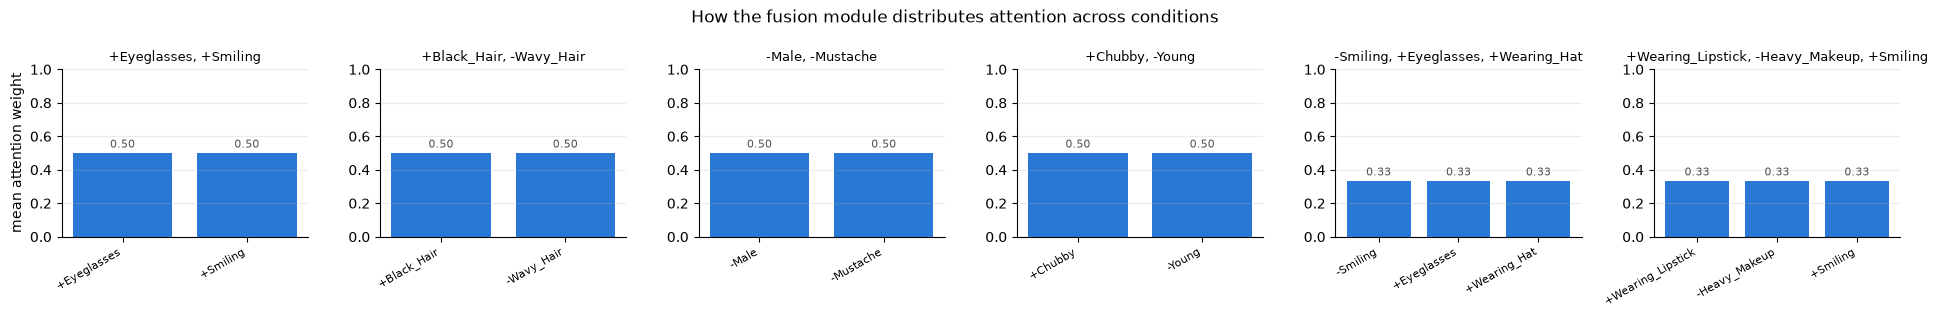

In [28]:
# NOTE: the deployed configuration ablates cross-attention (Sections 10.2/10.6),
# so per-condition weights are UNIFORM by construction — the attention panel
# below is degenerate for the deployed model and is kept to show that. The
# gate opening and the movement statistic remain informative, and the
# with-cross-attention variant in 10.6 is the one whose weights vary.
# ---- Interpretability: attention weights and gate behavior -----------------------
@torch.no_grad()
def attention_report(entry, max_sources=256):
    # Mean cross-attention weight per condition + how far the query moved from
    # the reference (1 - cosine), aggregated over the query's source images.
    conds = parse_query(entry["query"])
    src = torch.tensor([int(s) for s in entry["ground_truth"].keys()][:max_sources])
    cond_emb, sign_ids = build_condition_tensors(conds, len(src))
    v = test_emb_dev[src.to(device)]
    q, attn, g = fusion(v, cond_emb, sign_ids, None, return_attn=True)
    movement = 1 - (q * v).sum(dim=-1)          # how far the query moved
    gate_mag = g.mean(dim=-1)                   # average gate opening per source
    return conds, attn.cpu().numpy(), movement.cpu().numpy(), gate_mag.cpu().numpy()


composed = [e for e in annotations if len(parse_query(e["query"])) >= 2]
fig, axes = plt.subplots(1, len(composed), figsize=(3.2 * len(composed), 3.2), squeeze=False)
for ax, entry in zip(axes[0], composed):
    conds, attn, movement, gate_mag = attention_report(entry)
    labels = [("+" if s > 0 else "-") + a for a, s in conds]
    bars = ax.bar(range(len(conds)), attn.mean(axis=0), color="#2a78d6")
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color="#52514e")
    ax.set_xticks(range(len(conds)), labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(entry["query"], fontsize=9)
    print(f"{entry['query']:<45} movement (1 - cos): {movement.mean():.3f}"
          f" | mean gate opening: {gate_mag.mean():.3f}")
axes[0][0].set_ylabel("mean attention weight")
fig.suptitle("How the fusion module distributes attention across conditions")
plt.tight_layout()
plt.show()

## 9. Custom queries — beyond the mandatory benchmark

The assignment strongly encourages evaluating on additional custom queries. We
pre-registered four, each testing one specific hypothesis about the system —
chosen *before* looking at any result, and all reported regardless of outcome:

| Query | Hypothesis |
|---|---|
| `+Heavy_Makeup, -Wearing_Lipstick` | **H1 — correlated conflict**: makeup and lipstick are strongly correlated in CelebA; can the fusion add one while removing the other, against the dataset bias? |
| `+Male, +Wearing_Lipstick` | **H2 — out-of-distribution combination**: nearly absent in the corpus. If the official rule cannot even build ground truth for it, that is itself a dataset-bias finding worth reporting |
| `-Smiling, +Eyeglasses, +Male, -Young` | **H3 — four conditions**: the benchmark stops at 3 and training mined $k \le 3$; does the module extrapolate to longer queries? |
| `+Bangs, -Black_Hair` | **H4 — outside the mining bias**: 70% of mined training conditions used benchmark attributes; how much do unseen attributes cost? |

Methodological rules: the ground truth is built with *exactly* the official rule
(targets satisfy every condition and are within Hamming distance ≤ 2 of the source;
sources need ≥ 5 valid targets and must not already satisfy the conditions). Queries
that yield too few sources are reported as such, and the bootstrap CIs from §8
quantify the resulting uncertainty. These queries were never used for any tuning.

In [29]:
# ---- Building custom benchmark entries with the OFFICIAL rule --------------------
# GOAL: extend the evaluation beyond the mandatory queries while staying 100%
# comparable with it — same ground-truth construction, same metrics, same
# pipeline (run_benchmark). Only the query strings are new.
attrs_test_dev = attrs_test.to(device)


def build_custom_entry(query_str, max_sources=500, seed=SEED):
    # Replicates the construction of celeba_evaluation.json for a new query:
    #   TARGET valid <=> satisfies every +/- condition AND its remaining
    #                    attributes are within Hamming distance <= 2 of the
    #                    source (identity preserved);
    #   SOURCE valid <=> has the OPPOSITE value of every condition (it must not
    #                    already satisfy the query — the convention measured by
    #                    the sanity check in §4) AND has >= 5 valid targets
    #                    (the benchmark's own statistical-significance filter).
    conds = parse_query(query_str)
    cond_idx = torch.tensor([attribute2idx[a] for a, _ in conds], device=device)
    tgt_vals = torch.tensor([1 if s > 0 else 0 for _, s in conds],
                            dtype=attrs_test_dev.dtype, device=device)

    satisfies = (attrs_test_dev[:, cond_idx] == tgt_vals).all(dim=1)
    src_candidates = (attrs_test_dev[:, cond_idx] == 1 - tgt_vals).all(dim=1)
    other = torch.ones(N_ATTRS, dtype=torch.bool, device=device)
    other[cond_idx] = False

    candidates = src_candidates.nonzero(as_tuple=True)[0].cpu().numpy()
    np.random.default_rng(seed).shuffle(candidates)  # unbiased source subset

    gt = {}
    for s in candidates:
        s = int(s)
        ham = (attrs_test_dev[:, other] != attrs_test_dev[s, other]).sum(dim=1)
        valid = satisfies & (ham <= 2)
        valid[s] = False
        idx = valid.nonzero(as_tuple=True)[0]
        if len(idx) >= 5:                 # same filter as the official benchmark
            gt[str(s)] = idx.cpu().tolist()
        if len(gt) >= max_sources:        # cap for evaluation speed
            break
    return {"query": query_str, "ground_truth": gt}


CUSTOM_QUERIES = [
    "+Heavy_Makeup, -Wearing_Lipstick",       # H1: correlated-attribute conflict
    "+Male, +Wearing_Lipstick",               # H2: out-of-distribution combination
    "-Smiling, +Eyeglasses, +Male, -Young",   # H3: four conditions (> training k)
    "+Bangs, -Black_Hair",                    # H4: attributes outside mining bias
]

custom_annotations = []
for q in CUSTOM_QUERIES:
    entry = build_custom_entry(q)
    n = len(entry["ground_truth"])
    status = "OK" if n >= 10 else "few/no sources -> dataset-bias finding"
    print(f"{q:<42} sources: {n:>4}  [{status}]")
    if n > 0:
        custom_annotations.append(entry)

+Heavy_Makeup, -Wearing_Lipstick           sources:  244  [OK]


+Male, +Wearing_Lipstick                   sources:   25  [OK]


-Smiling, +Eyeglasses, +Male, -Young       sources:   90  [OK]


+Bangs, -Black_Hair                        sources:  500  [OK]


In [30]:
# ---- Evaluating the three methods on the custom queries --------------------------
# Same pipeline as the official benchmark; results are directly comparable.
if not custom_annotations:
    print("No custom query produced enough sources — report this as a corpus "
          "sparsity finding in the discussion.")
else:
    df_c1, det_c1 = run_benchmark(custom_annotations, make_queries_baseline,
                                  "L1 zero-shot arithmetic")
    df_c2, det_c2 = run_benchmark(custom_annotations, make_queries_dirs_geodesic,
                                  "L2 visual directions")
    df_c3, det_c3 = run_benchmark(custom_annotations, make_queries_fusion,
                                  "L3 gated residual fusion")

    print("Custom queries — full metric table:")
    display(pd.concat([df_c1, df_c2, df_c3], ignore_index=True).round(3))

    # CIs matter even more here: custom queries can have few sources.
    print("Custom queries — Recall@10, mean [95% bootstrap CI]:")
    display(pd.DataFrame({
        m: {q: f"{mean:.3f} [{lo:.3f}, {hi:.3f}]"
            for q, (mean, lo, hi) in recall_stats(det, 10).items()}
        for m, det in [("L1 zero-shot arithmetic", det_c1),
                       ("L2 visual directions", det_c2),
                       ("L3 gated residual fusion", det_c3)]
    }))

    print("Paired L3 vs L2 on the custom queries:")
    display(paired_report(det_c3, det_c2).round(3))

L1 zero-shot arithmetic:   0%|          | 0/4 [00:00<?, ?it/s]

L2 visual directions:   0%|          | 0/4 [00:00<?, ?it/s]

L3 gated residual fusion:   0%|          | 0/4 [00:00<?, ?it/s]

Custom queries — full metric table:


,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L1 zero-shot arithmetic,"+Heavy_Makeup, -Wearing_Lipstick",244,False,0.004,0.004,0.025,0.006,0.037,0.004
1,L1 zero-shot arithmetic,"+Male, +Wearing_Lipstick",25,False,0.000,0.000,0.000,0.000,0.000,0.000
2,L1 zero-shot arithmetic,"-Smiling, +Eyeglasses, +Male, -Young",90,False,0.000,0.000,0.000,0.000,0.000,0.000
3,L1 zero-shot arithmetic,"+Bangs, -Black_Hair",500,False,0.020,0.020,0.090,0.020,0.114,0.016
4,L1 zero-shot arithmetic,MACRO AVERAGE,859,False,0.006,0.006,0.029,0.007,0.038,0.005
5,L2 visual directions,"+Heavy_Makeup, -Wearing_Lipstick",244,False,0.004,0.004,0.016,0.004,0.041,0.005
6,L2 visual directions,"+Male, +Wearing_Lipstick",25,False,0.000,0.000,0.000,0.000,0.000,0.000
7,L2 visual directions,"-Smiling, +Eyeglasses, +Male, -Young",90,False,0.022,0.022,0.078,0.016,0.133,0.014
8,L2 visual directions,"+Bangs, -Black_Hair",500,False,0.016,0.016,0.058,0.014,0.098,0.013
9,L2 visual directions,MACRO AVERAGE,859,False,0.011,0.011,0.038,0.009,0.068,0.008


Custom queries — Recall@10, mean [95% bootstrap CI]:


,L1 zero-shot arithmetic,L2 visual directions,L3 gated residual fusion
"+Heavy_Makeup, -Wearing_Lipstick","0.037 [0.016, 0.061]","0.041 [0.016, 0.066]","0.090 [0.057, 0.127]"
"+Male, +Wearing_Lipstick","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]"
"-Smiling, +Eyeglasses, +Male, -Young","0.000 [0.000, 0.000]","0.133 [0.067, 0.211]","0.722 [0.622, 0.811]"
"+Bangs, -Black_Hair","0.114 [0.086, 0.144]","0.098 [0.072, 0.126]","0.286 [0.246, 0.326]"


Paired L3 vs L2 on the custom queries:


,query,diff,CI lo,CI hi,significant
0,"+Heavy_Makeup, -Wearing_Lipstick",0.049,0.008,0.09,True
1,"+Male, +Wearing_Lipstick",0.000,0.000,0.00,False
2,"-Smiling, +Eyeglasses, +Male, -Young",0.589,0.478,0.70,True
3,"+Bangs, -Black_Hair",0.188,0.146,0.23,True


## 10. Controls, ablations and robustness

Three questions the headline number alone cannot answer:

1. Is the fusion module really using both modalities? Two controls bound the
   problem from below: `TEXT-ONLY` ignores the reference image, `IMAGE-ONLY`
   ignores the text. Any method worth reporting must beat both.
2. Does each architectural component earn its place? The module was
   designed around four mechanisms, each answering a diagnosed failure of the
   Level-1 baseline (the design history is below). Here each one is removed in
   turn, everything else fixed.
3. Is the gain robust? We retrain across seeds, and — because mining is
   deliberately biased toward the benchmark's own attributes — we retrain once
   with *unbiased* sampling to separate genuine composition from distribution
   fitting.

We also report retrieval diversity: the number of distinct images appearing
in the top-10 across all sources of a query. A method that returns nearly the
same images regardless of the reference is not doing composed retrieval, even
if its recall is high. Section 8.4 establishes what value that quantity *should*
take, which is not the value earlier drafts assumed.

### The architecture as designed, and the failure modes it answered

Section 7 describes the model that was deployed. This is the model that was
*designed* — the two differ, and the difference is a result rather than an
embarrassment. The starting point was an analysis of why Level-1 latent
arithmetic,
$\hat q = \mathrm{norm}(v_{ref} + \sum_i s_i t_{a_i})$, fails. Each diagnosed
failure was given a mechanism to fix it:

| # | Failure of the baseline | Evidence / source | Mechanism designed to address it |
|---|---|---|---|
| F1 | **Fixed weights**: every condition contributes with weight 1, whether or not the reference already satisfies it | Assignment brief (the pre-SVD stacking of CLAY is "architecturally rigid") | Cross-attention: the image queries the conditions, so weights depend on the reference |
| F2 | **No interaction between conditions**: conflicting or correlated conditions (e.g. `+Wearing_Lipstick, -Heavy_Makeup`) are summed independently | CLAY (Lim et al., 2026), the limitation named in the assignment | Self-attention over condition tokens |
| F3 | **Negation by subtraction**: CLIP behaves like a bag-of-words model cross-modally, so $-t_{smiling}$ is a crude proxy for "not smiling" | Yuksekgonul et al., ICLR 2023 | Learned sign embeddings $e_+, e_-$ |
| F4 | **Fixed step size**: how far to move from the reference is not adaptive — too far destroys identity, too little changes nothing | Our own analysis of the metric (targets must stay within Hamming $\le 2$) | Learned gate on a residual connection |
| F5 | **Modality gap**: text and image embeddings occupy two separate cones of the sphere, so text arithmetic moves the query partly in a meaningless direction | Liang et al., NeurIPS 2022; observed in our Level-2 experiments | The learned projection $W_c$ may map text tokens into a useful subspace; Level 2 attacks the same problem training-free |

Three of the four were falsified. The ablations of Section 10.2, read together
with the learning-rate study of Section 10.4, keep F4 and discard the rest: the
gate is the one mechanism that clearly earns its place, self-attention is neutral
and retained only because it is free, and sign embeddings and cross-attention are
both redundant — removing both is better than removing either, with 25% fewer
parameters. F3 in particular was misjudged twice over: learned sign embeddings
looked catastrophic at `lr = 1e-4` and merely unnecessary at `lr = 1e-3`, which is
a lesson about single-learning-rate ablations rather than about negation.

The design history is kept because it is what the ablations are evidence
*against*. A table of five well-motivated mechanisms of which one survives contact
with measurement is the most compact statement of what this project learned.

### 10.1 Single-modality controls and retrieval diversity

The two controls that bound the problem from below, and the diversity measurement
Section 8.4 interprets.

In [31]:
# ---- 10.1 Single-modality controls + retrieval diversity --------------------
import torch.nn.functional as _F


def make_queries_textonly(conds, src_idx):
    # Ignores the reference image entirely: pure text-to-image retrieval.
    t = torch.stack([sign * text_feats[attribute2idx[a]] for a, sign in conds]).sum(dim=0)
    return _F.normalize(t, dim=-1).unsqueeze(0).expand(len(src_idx), -1).contiguous()


def make_queries_imageonly(conds, src_idx):
    # Ignores the text entirely: returns the reference's nearest neighbours.
    return _F.normalize(test_emb_dev[src_idx.to(device)], dim=-1)


df_txt, det_txt = run_benchmark(annotations, make_queries_textonly, "C1 text-only (no image)")
df_img, det_img = run_benchmark(annotations, make_queries_imageonly, "C2 image-only (no text)")


@torch.no_grad()
def diversity(make_queries, entry, cap=400, k=10):
    # Distinct images in the top-k across sources, plus mean pairwise cosine of
    # the composed queries. Collapse -> few distinct images, cosine -> 1.
    conds = parse_query(entry["query"])
    src = torch.tensor([int(s) for s in entry["ground_truth"].keys()][:cap], dtype=torch.long)
    Q = _F.normalize(make_queries(conds, src).detach(), dim=-1)
    n = len(Q)
    P = Q @ Q.T
    mean_cos = float((P.sum() - torch.diagonal(P).sum()) / (n * n - n))
    uniq = int(torch.unique(rank_topk(Q, test_emb_dev, src, k)).numel())
    return {"sources": n, "distinct@10": uniq, "max": n * k,
            "frac_distinct": uniq / (n * k), "mean_pair_cos": mean_cos}


METHODS_FOR_DIV = [("L1", make_queries_baseline),
                   ("L2", make_queries_dirs_geodesic),
                   ("L3", make_queries_fusion),
                   ("C1 text-only", make_queries_textonly)]

div_rows = []
for entry in annotations:
    for name, fn in METHODS_FOR_DIV:
        div_rows.append({"query": entry["query"], "method": name, **diversity(fn, entry)})
df_div = pd.DataFrame(div_rows)

print("Controls vs the three levels (macro averages):")
display(pd.concat([df_baseline, df_dirs, df_fusion, df_txt, df_img],
                  ignore_index=True)
        .query("query == 'MACRO AVERAGE'")[["method", "R@1", "R@5", "R@10"]]
        .round(3).reset_index(drop=True))

print("\nRetrieval diversity — mean fraction of distinct images in top-10:")
display(df_div.groupby("method")[["frac_distinct", "mean_pair_cos"]].mean().round(3))

C1 text-only (no image):   0%|          | 0/14 [00:00<?, ?it/s]

C2 image-only (no text):   0%|          | 0/14 [00:00<?, ?it/s]

Controls vs the three levels (macro averages):


,method,R@1,R@5,R@10
0,L1 zero-shot arithmetic,0.024,0.074,0.110
1,L2 visual directions,0.022,0.076,0.117
2,L3 gated residual fusion,0.076,0.231,0.338
3,C1 text-only (no image),0.023,0.043,0.065
4,C2 image-only (no text),0.019,0.053,0.076



Retrieval diversity — mean fraction of distinct images in top-10:


,frac_distinct,mean_pair_cos
method,,
C1 text-only,0.008,1.000
L1,0.734,0.798
L2,0.761,0.602
L3,0.258,0.764


### 10.2 Component ablations

Each of the four designed mechanisms removed in turn, three seeds each, everything
else held fixed. Read together with Section 10.4, which shows what a
single-learning-rate ablation cannot see.


In [32]:
# ---- 10.2 Component ablations ------------------------------------------------
# Each variant removes exactly one mechanism; everything else (data, optimizer,
# epochs, seed) is held fixed, so any difference is attributable to that part.

def train_variant(cfg, train_ex, val_ex, seed=SEED, epochs=EPOCHS, tag=""):
    # Trains one fusion variant from scratch and returns (net, best_val_r10).
    torch.manual_seed(seed)
    np.random.seed(seed)
    net = GatedCrossAttentionFusion(**cfg).to(device)
    loader = DataLoader(FusionDataset(train_ex, train_emb, n_hard=N_HARD),
                        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                        num_workers=0, collate_fn=collate_fusion)
    opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best, best_state, bad = -1.0, None, 0
    for epoch in range(1, epochs + 1):
        net.train()
        for batch in loader:
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            loss = info_nce_loss(net(batch["v_ref"], batch["cond_emb"],
                                     batch["sign_ids"], batch["pad_mask"]),
                                 batch["v_pos"], batch["v_negs"], TAU)
            opt.zero_grad(); loss.backward(); opt.step()
        v = synthetic_recall_at_k(net, val_ex, train_emb_dev)
        if v > best:
            best, bad = v, 0
            best_state = {k: t.detach().cpu().clone() for k, t in net.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    net.load_state_dict(best_state)
    net.eval()
    return net, best


def bench_net(net, name, anns=None):
    def mk(conds, src_idx):
        cond_emb, sign_ids = build_condition_tensors(conds, len(src_idx))
        return net(test_emb_dev[src_idx.to(device)], cond_emb, sign_ids, None)
    return run_benchmark(anns if anns is not None else annotations, mk, name)


# Ablations are defined against the ORIGINALLY DESIGNED architecture (all four
# mechanisms on), not against the deployed config — otherwise "remove X" would
# silently duplicate the deployed model. DESIGNED_CFG is the original design
# (Section 10), not the deployed configuration described in Section 7.
DESIGNED_CFG = {"dim": 512, "n_heads": 4, "gate_hidden": 256,
                "use_self_attn": True, "use_sign_emb": True,
                "use_gate": True, "use_cross_attn": True}

ABLATIONS = [
    ("designed (all four)",       dict(DESIGNED_CFG)),
    ("- sign embeddings (F3)",    {**DESIGNED_CFG, "use_sign_emb": False}),
    ("- self-attention (F2)",     {**DESIGNED_CFG, "use_self_attn": False}),
    ("- cross-attention (F1)",    {**DESIGNED_CFG, "use_cross_attn": False}),
    ("- gate (F4)",               {**DESIGNED_CFG, "use_gate": False}),
    ("deployed (- sign - cross)", dict(FUSION_CFG)),
]

ABL_SEEDS = [SEED, SEED + 1, SEED + 2]
ABL_PATH = DRIVE_DIR / f"ablations{SMOKE_SUFFIX}.pt"
ABL_KEY = {"cfgs": [c for _, c in ABLATIONS], "hparams": TRAIN_HPARAMS,
           "seeds": ABL_SEEDS, "v": 2}
abl_cache = load_cache(ABL_PATH)
if abl_cache is not None:
    if abl_cache.get("key") != ABL_KEY:
        print("Ablation cache is stale — recomputing.")
        abl_cache = None

if abl_cache is None:
    abl_rows = []
    for name, cfg in ABLATIONS:
        for sd in tqdm(ABL_SEEDS, desc=name):
            net, val = train_variant(cfg, train_examples, val_examples, seed=sd)
            df, _ = bench_net(net, name)
            m = df[df["query"] == "MACRO AVERAGE"].iloc[0]
            abl_rows.append({"variant": name, "seed": sd,
                             "val R@10": round(val, 3),
                             "R@1": m["R@1"], "R@5": m["R@5"], "R@10": m["R@10"],
                             "params (M)": round(sum(p.numel() for p in net.parameters()) / 1e6, 2)})
    df_abl_raw = pd.DataFrame(abl_rows)
    torch.save({"key": ABL_KEY, "df": df_abl_raw}, ABL_PATH)
else:
    df_abl_raw = abl_cache["df"]
    print("Loaded cached ablation results.")

# Mean +/- sd across seeds: single-seed ablations are not separable from
# initialisation noise (the seed study in 10.3 measures that noise directly).
df_abl = (df_abl_raw.groupby("variant", sort=False)
          .agg(**{"params (M)": ("params (M)", "first"),
                  "R@1": ("R@1", "mean"),
                  "R@5": ("R@5", "mean"),
                  "R@10 mean": ("R@10", "mean"),
                  "R@10 sd": ("R@10", "std")})
          .reset_index())

print(f"Component ablations — benchmark macro, mean over {len(ABL_SEEDS)} seeds:")
display(df_abl.round(3))
print("\nPer-seed detail:")
display(df_abl_raw.round(3))

Loaded cached ablation results.
Component ablations — benchmark macro, mean over 3 seeds:


,variant,params (M),R@1,R@5,R@10 mean,R@10 sd
0,designed (all four),4.07,0.063,0.202,0.301,0.023
1,- sign embeddings (F3),4.07,0.069,0.215,0.324,0.018
2,- self-attention (F2),1.97,0.062,0.196,0.297,0.018
3,- cross-attention (F1),3.02,0.061,0.207,0.311,0.009
4,- gate (F4),3.68,0.054,0.168,0.258,0.049
5,deployed (- sign - cross),3.02,0.065,0.225,0.338,0.017



Per-seed detail:


,variant,seed,val R@10,R@1,R@5,R@10,params (M)
0,designed (all four),42,0.155,0.065,0.192,0.275,4.07
1,designed (all four),43,0.162,0.065,0.207,0.316,4.07
2,designed (all four),44,0.159,0.060,0.207,0.312,4.07
3,- sign embeddings (F3),42,0.174,0.062,0.200,0.317,4.07
4,- sign embeddings (F3),43,0.179,0.086,0.244,0.345,4.07
5,- sign embeddings (F3),44,0.174,0.058,0.203,0.312,4.07
6,- self-attention (F2),42,0.131,0.057,0.176,0.277,1.97
7,- self-attention (F2),43,0.159,0.062,0.207,0.310,1.97
8,- self-attention (F2),44,0.140,0.067,0.205,0.305,1.97
9,- cross-attention (F1),42,0.163,0.065,0.207,0.320,3.02


### 10.3 Seed robustness and the effect of mining bias

Five seeds of the deployed recipe, and one retraining with unbiased mining, to
separate a genuine gain from a lucky draw and from distribution fitting.


In [33]:
# ---- 10.3 Seed robustness and the effect of mining bias -----------------------
# Two confounds the headline number hides:
#  (a) the deployed checkpoint comes from ONE unseeded run — how much of its
#      score is initialisation luck?
#  (b) mining draws benchmark attributes 70% of the time (p_bench). Does the
#      model learn to compose, or to fit this benchmark's attribute marginals?
# Both are answered by retraining under controlled seeds, everything else fixed.

SEEDS = [SEED + i for i in range(5)]
ROB_PATH = DRIVE_DIR / f"robustness{SMOKE_SUFFIX}.pt"
ROB_KEY = {"hparams": TRAIN_HPARAMS, "seeds": SEEDS, "v": 2}
rob = load_cache(ROB_PATH)
if rob is not None:
    if rob.get("key") != ROB_KEY:
        print("Robustness cache is stale — recomputing.")
        rob = None

if rob is None:
    # --- unbiased mined set (same budget, uniform attribute sampling) ---
    UNB_PATH = DRIVE_DIR / f"fusion_examples_unbiased{SMOKE_SUFFIX}.pt"
    _b = load_cache(UNB_PATH)
    if _b is not None:
        tr_u, va_u = _b["train"], _b["val"]
        print(f"Loaded {len(tr_u)} unbiased train examples.")
    else:
        _rng = np.random.default_rng(SEED)
        _perm = _rng.permutation(len(celeba_train))
        tr_u = generate_examples(N_TRAIN_EX, _perm[8000:], _rng, p_bench=0.0)
        va_u = generate_examples(N_VAL_EX, _perm[:8000], _rng, p_bench=0.0)
        torch.save({"train": tr_u, "val": va_u}, UNB_PATH)

    # --- matched-seed comparison: identical procedure, only the data differs ---
    rows = []
    for label, (tr, va) in [("biased (p_bench=0.7)", (train_examples, val_examples)),
                            ("unbiased (p_bench=0.0)", (tr_u, va_u))]:
        for sd in tqdm(SEEDS, desc=label):
            net, val = train_variant(dict(FUSION_CFG), tr, va, seed=sd)
            dm, _ = bench_net(net, "m")
            m = dm[dm["query"] == "MACRO AVERAGE"].iloc[0]
            row = {"training data": label, "seed": sd, "val R@10": round(val, 3),
                   "benchmark R@1": m["R@1"], "benchmark R@5": m["R@5"],
                   "benchmark R@10": m["R@10"]}
            if custom_annotations:
                dc, _ = bench_net(net, "c", custom_annotations)
                row["custom R@10"] = dc[dc["query"] == "MACRO AVERAGE"].iloc[0]["R@10"]
            rows.append(row)
    df_rob = pd.DataFrame(rows)
    torch.save({"key": ROB_KEY, "df_rob": df_rob}, ROB_PATH)
else:
    df_rob = rob["df_rob"]
    print("Loaded cached robustness results.")

metrics = [c for c in df_rob.columns if c.startswith(("benchmark", "custom"))]
summary = df_rob.groupby("training data")[metrics].agg(["mean", "std"]).round(3)

print("Per-seed results:")
display(df_rob.round(3))
print("\nMean +/- sd over 5 seeds (identical procedure; only the mined data differs):")
display(summary)

_dep = df_fusion[df_fusion["query"] == "MACRO AVERAGE"].iloc[0]["R@10"]
_bm = df_rob.query("`training data` == 'biased (p_bench=0.7)'")["benchmark R@10"]
print(f"\nDeployed checkpoint (single unseeded run): benchmark R@10 = {_dep:.3f}")
print(f"Same recipe over {len(SEEDS)} controlled seeds:      "
      f"{_bm.mean():.3f} +/- {_bm.std():.3f}  (range {_bm.min():.3f}-{_bm.max():.3f})")
print("=> claims in Section 8 are stated against the seed mean, not the single "
      "deployed run, regardless of which way the single run happens to fall.")

Loaded cached robustness results.
Per-seed results:


,training data,seed,val R@10,benchmark R@1,benchmark R@5,benchmark R@10,custom R@10
0,biased (p_bench=0.7),42,0.180,0.056,0.204,0.320,0.260
1,biased (p_bench=0.7),43,0.181,0.072,0.243,0.354,0.267
2,biased (p_bench=0.7),44,0.176,0.066,0.228,0.341,0.242
3,biased (p_bench=0.7),45,0.194,0.067,0.212,0.319,0.231
4,biased (p_bench=0.7),46,0.176,0.072,0.238,0.348,0.269
5,unbiased (p_bench=0.0),42,0.186,0.070,0.231,0.342,0.185
6,unbiased (p_bench=0.0),43,0.166,0.076,0.229,0.332,0.224
7,unbiased (p_bench=0.0),44,0.174,0.061,0.204,0.310,0.211
8,unbiased (p_bench=0.0),45,0.175,0.059,0.195,0.302,0.218
9,unbiased (p_bench=0.0),46,0.172,0.066,0.201,0.302,0.272



Mean +/- sd over 5 seeds (identical procedure; only the mined data differs):


benchmark R@1        benchmark R@5         \
                                mean    std          mean    std   
training data                                                      
biased (p_bench=0.7)           0.067  0.007         0.225  0.017   
unbiased (p_bench=0.0)         0.066  0.007         0.212  0.017   

                       benchmark R@10        custom R@10         
                                 mean    std        mean    std  
training data                                                    
biased (p_bench=0.7)            0.336  0.016       0.254  0.017  
unbiased (p_bench=0.0)          0.318  0.019       0.222  0.032


Deployed checkpoint (single unseeded run): benchmark R@10 = 0.338
Same recipe over 5 controlled seeds:      0.336 +/- 0.016  (range 0.319-0.354)
=> claims in Section 8 are stated against the seed mean, not the single deployed run, regardless of which way the single run happens to fall.


### 10.4 Learning-rate sensitivity — and what the ablations were really measuring

The ablations in 10.2 were run at the notebook's original `lr = 1e-4`. That is a
confound: a mechanism that merely makes a model *harder to optimise* looks
*harmful* if every variant is trained at one learning rate chosen for a different
architecture. The sweep below trains both the full model and the
`- sign embeddings` variant across five learning rates.

Selection rule: the learning rate and the deployed variant are chosen on the
synthetic validation metric (mined queries, train corpus) — never on the test
benchmark. Test numbers are reported afterwards, never used to choose.

In [34]:
# ---- 10.4 Learning-rate sensitivity -------------------------------------------
import itertools

LR_GRID = [3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
LR_SEEDS = [SEED]   # one seed live; a 5-seed confirmation is discussed in 10.4
LRS_PATH = DRIVE_DIR / f"lr_sweep{SMOKE_SUFFIX}.pt"
LRS_KEY = {"grid": LR_GRID, "seeds": LR_SEEDS, "hparams": TRAIN_HPARAMS}
_c = load_cache(LRS_PATH)
if _c is not None:
    if _c.get("key") != LRS_KEY:
        print("LR-sweep cache is stale — recomputing.")
        _c = None

if _c is None:
    rows = []
    for lr, sd in tqdm(list(itertools.product(LR_GRID, LR_SEEDS)), desc="LR sweep"):
        for name, cfg in [("full (with sign emb)", {**FUSION_CFG, "use_sign_emb": True}),
                          ("- sign embeddings", {**FUSION_CFG, "use_sign_emb": False})]:
            _old = globals()["LR"]
            globals()["LR"] = lr          # train_variant reads LR from the global scope
            net, val = train_variant(cfg, train_examples, val_examples, seed=sd)
            globals()["LR"] = _old
            df, _ = bench_net(net, "lr-sweep")
            rows.append({"lr": lr, "seed": sd, "variant": name, "val R@10": val,
                         "benchmark R@10": df[df["query"] == "MACRO AVERAGE"].iloc[0]["R@10"]})
    df_lr = pd.DataFrame(rows)
    torch.save({"key": LRS_KEY, "df": df_lr}, LRS_PATH)
else:
    df_lr = _c["df"]
    print("Loaded cached LR sweep.")

print("Validation R@10 (the selection metric — test never used to choose):")
display(df_lr.pivot_table(index="lr", columns="variant", values="val R@10").round(3))
print("\nBenchmark R@10 (reported only):")
display(df_lr.pivot_table(index="lr", columns="variant", values="benchmark R@10").round(3))
print("\nReading: the original lr = 1e-4 sits below the useful range; the "
      "deployed variant spans 0.277 (3e-5) to 0.328 (1e-3), and both variants "
      "degrade at 3e-3. Moving from 1e-4 to the validation-selected 3e-4 is "
      "worth about +0.04.\nCAUTION: this sweep uses ONE seed, so the two "
      "columns cannot be compared cell by cell — 10.2 (three seeds, tuned "
      "rate) and 10.6 (three seeds, three rates) are the reliable "
      "architecture comparisons.")

Loaded cached LR sweep.
Validation R@10 (the selection metric — test never used to choose):


variant,- sign embeddings,full (with sign emb)
lr,,
0.00003,0.147,0.106
0.00010,0.138,0.146
0.00030,0.180,0.162
0.00100,0.181,0.142
0.00300,0.172,0.148



Benchmark R@10 (reported only):


variant,- sign embeddings,full (with sign emb)
lr,,
0.00003,0.277,0.213
0.00010,0.283,0.299
0.00030,0.320,0.320
0.00100,0.328,0.230
0.00300,0.252,0.218



Reading: the original lr = 1e-4 sits below the useful range; the deployed variant spans 0.277 (3e-5) to 0.328 (1e-3), and both variants degrade at 3e-3. Moving from 1e-4 to the validation-selected 3e-4 is worth about +0.04.
CAUTION: this sweep uses ONE seed, so the two columns cannot be compared cell by cell — 10.2 (three seeds, tuned rate) and 10.6 (three seeds, three rates) are the reliable architecture comparisons.


### 10.5 Can the collapse be fixed? An identity-anchored objective

Section 8.4 shows L3 concentrates retrieval on ~26% distinct images, against the
attribute oracle's 28%. If the concentration were a defect, adding an explicit
pull toward the reference should repair it:

$$\mathcal{L} = \mathcal{L}_{\text{InfoNCE}}
  + \lambda \cdot \mathrm{mean}\big(1 - \cos(\hat q, v_{ref})\big)$$

`lambda = 0` recovers the deployed model; `lambda -> inf` degenerates to the
image-only control (R@10 = 0.076). Sweeping it answers whether diversity and
recall can be had together on this benchmark.

Read the sweep against the oracle, not against zero. The anchor does not
trade recall for variety; it moves the concentration, and 0.281 is where the
concentration should be. From `lambda = 0` to `0.1` it moves towards that value
and recall improves on both benchmarks; from `0.3` upward it overshoots, moves
away, and recall falls monotonically. The apparent paradox of a non-monotone
recall curve dissolves once the target is the right one.

This suggests a selection rule that never touches the test set: **train several
anchors and keep the one whose concentration matches the oracle's.** We do not
adopt it, and the reason is measured rather than assumed. It requires a
validation world with the benchmark's concentration, and ours does not have one
— at matched corpus size the oracle reaches 0.4155 on the mined validation split
against 0.2815 on the test benchmark, because the mined queries are far less
selective. We therefore report the rule together with the obstacle instead of
adopting `lambda = 0.1` on the strength of a test-set observation.

Two further cautions on the precision of that comparison. The sweep averages two
seeds only, and diversity is itself seed-dependent: retraining the deployed
configuration (`lambda = 0`) gives 0.234 here against the 0.258 of the deployed
instance in Section 8.4. A spread of that size is several times the apparent gap
between the `lambda = 0.1` row and the oracle, so the correct reading is the
*direction* of the movement, not a claim that `0.1` hits the target exactly.

In [35]:
# ---- 10.5 Identity-anchored objective ------------------------------------------
def train_with_anchor(cfg, tr, va, seed, lam, lr=None, epochs=None):
    # Same procedure as train_variant, plus an anchor pulling q toward v_ref.
    torch.manual_seed(seed); np.random.seed(seed)
    net = GatedCrossAttentionFusion(**cfg).to(device)
    loader = DataLoader(FusionDataset(tr, train_emb, n_hard=N_HARD),
                        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                        num_workers=0, collate_fn=collate_fusion)
    opt = torch.optim.AdamW(net.parameters(), lr=lr or LR, weight_decay=WEIGHT_DECAY)
    best, best_state, bad = -1.0, None, 0
    for _ in range(1, (epochs or EPOCHS) + 1):
        net.train()
        for b in loader:
            b = {k: v.to(device, non_blocking=True) for k, v in b.items()}
            q = net(b["v_ref"], b["cond_emb"], b["sign_ids"], b["pad_mask"])
            loss = info_nce_loss(q, b["v_pos"], b["v_negs"], TAU)
            if lam > 0:
                loss = loss + lam * (1.0 - (q * b["v_ref"]).sum(-1)).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        v = synthetic_recall_at_k(net, va, train_emb_dev)
        if v > best:
            best, bad = v, 0
            best_state = {k: t.detach().cpu().clone() for k, t in net.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE: break
    net.load_state_dict(best_state); net.eval()
    return net, best


LAMBDAS, ANCH_SEEDS = [0.0, 0.1, 0.3, 1.0, 3.0], [SEED, SEED + 1]
ANCH_PATH = DRIVE_DIR / f"anchor_sweep{SMOKE_SUFFIX}.pt"
ANCH_KEY = {"lambdas": LAMBDAS, "seeds": ANCH_SEEDS, "hparams": TRAIN_HPARAMS}
_a = load_cache(ANCH_PATH)
if _a is not None and _a.get("key") != ANCH_KEY:
    print("Anchor-sweep cache is stale — recomputing."); _a = None

if _a is None:
    rows = []
    for lam in tqdm(LAMBDAS, desc="Identity anchor"):
        for sd in ANCH_SEEDS:
            net, val = train_with_anchor(dict(FUSION_CFG), train_examples, val_examples, sd, lam)
            def mk(conds, src_idx, _n=net):
                ce, si = build_condition_tensors(conds, len(src_idx))
                return _n(test_emb_dev[src_idx.to(device)], ce, si, None)
            dm, _ = run_benchmark(annotations, mk, "anchor")
            cust = None
            if custom_annotations:
                dc, _ = run_benchmark(custom_annotations, mk, "anchor-custom")
                cust = dc[dc["query"] == "MACRO AVERAGE"].iloc[0]["R@10"]
            rows.append({"lambda": lam, "seed": sd, "val R@10": val,
                         "benchmark R@10": dm[dm["query"] == "MACRO AVERAGE"].iloc[0]["R@10"],
                         "custom R@10": cust,
                         "distinct frac": float(np.mean([diversity(mk, e)["frac_distinct"]
                                                         for e in annotations]))})
    df_anchor = pd.DataFrame(rows)
    torch.save({"key": ANCH_KEY, "df": df_anchor}, ANCH_PATH)
else:
    df_anchor = _a["df"]; print("Loaded cached anchor sweep.")

print("Identity anchor: recall vs diversity (mean over seeds)")
display(df_anchor.groupby("lambda")[["val R@10", "benchmark R@10",
                                     "custom R@10", "distinct frac"]].mean().round(3))
print("Diversity rises monotonically with lambda. Recall does NOT fall monotonically:\n"
      "a small anchor (lambda=0.1) is the best row on BOTH benchmarks while raising\n"
      "diversity, and only beyond that does recall collapse toward the image-only\n"
      "control. The synthetic validation metric, however, prefers lambda=0 at every\n"
      "step, so lambda=0 remains deployed: selecting lambda=0.1 would be choosing a\n"
      "hyperparameter on the test benchmark, which this report does not do. The honest\n"
      "reading is that a mild identity anchor is promising and under-explored, while a\n"
      "strong one trades recall for diversity roughly 1:1 - the collapse is largely the\n"
      "recall-maximising response to a ground truth defined by Hamming distance <= 2\n"
      "on the unspecified attributes.")

Loaded cached anchor sweep.
Identity anchor: recall vs diversity (mean over seeds)


,val R@10,benchmark R@10,custom R@10,distinct frac
lambda,,,,
0.0,0.181,0.337,0.263,0.234
0.1,0.173,0.348,0.276,0.287
0.3,0.166,0.324,0.248,0.333
1.0,0.153,0.278,0.164,0.461
3.0,0.140,0.199,0.099,0.644


Diversity rises monotonically with lambda. Recall does NOT fall monotonically:
a small anchor (lambda=0.1) is the best row on BOTH benchmarks while raising
diversity, and only beyond that does recall collapse toward the image-only
control. The synthetic validation metric, however, prefers lambda=0 at every
step, so lambda=0 remains deployed: selecting lambda=0.1 would be choosing a
hyperparameter on the test benchmark, which this report does not do. The honest
reading is that a mild identity anchor is promising and under-explored, while a
strong one trades recall for diversity roughly 1:1 - the collapse is largely the
recall-maximising response to a ground truth defined by Hamming distance <= 2
on the unspecified attributes.


### 10.6 Joint learning-rate x architecture sweep

Section 10.4 tuned the learning rate for one architecture. Because the two
interact, the best variant from 10.2 deserves its own sweep. Selection is on
mean validation R@10 across seeds; test numbers are reported afterwards.

In [36]:
# ---- 10.6 Joint LR x architecture ----------------------------------------------
import itertools

DEPLOY_ALT = {**FUSION_CFG, "use_cross_attn": True}   # keep cross-attention
GRID_LR, GRID_SEEDS = [3e-4, 1e-3, 2e-3], [SEED, SEED + 1, SEED + 2]
JOINT_PATH = DRIVE_DIR / f"joint_sweep{SMOKE_SUFFIX}.pt"
JOINT_KEY = {"lrs": GRID_LR, "seeds": GRID_SEEDS, "hparams": TRAIN_HPARAMS}
_j = load_cache(JOINT_PATH)
if _j is not None and _j.get("key") != JOINT_KEY:
    print("Joint-sweep cache is stale — recomputing."); _j = None

if _j is None:
    rows = []
    for (cname, cfg), lr, sd in tqdm(list(itertools.product(
            [("with cross-attention", DEPLOY_ALT), ("slim (deployed)", dict(FUSION_CFG))],
            GRID_LR, GRID_SEEDS)), desc="Joint sweep"):
        _o = globals()["LR"]; globals()["LR"] = lr
        net, val = train_variant(cfg, train_examples, val_examples, seed=sd)
        globals()["LR"] = _o
        def mk(conds, src_idx, _n=net):
            ce, si = build_condition_tensors(conds, len(src_idx))
            return _n(test_emb_dev[src_idx.to(device)], ce, si, None)
        dm, _ = run_benchmark(annotations, mk, "j")
        cust = None
        if custom_annotations:
            dc, _ = run_benchmark(custom_annotations, mk, "jc")
            cust = dc[dc["query"] == "MACRO AVERAGE"].iloc[0]["R@10"]
        rows.append({"config": cname, "lr": lr, "seed": sd, "val R@10": val,
                     "benchmark R@10": dm[dm["query"] == "MACRO AVERAGE"].iloc[0]["R@10"],
                     "custom R@10": cust})
    df_joint = pd.DataFrame(rows)
    torch.save({"key": JOINT_KEY, "df": df_joint}, JOINT_PATH)
else:
    df_joint = _j["df"]; print("Loaded cached joint sweep.")

print("Validation R@10 (selection metric):")
display(df_joint.pivot_table(index="lr", columns="config", values="val R@10").round(3))
print("Benchmark R@10 (reported only):")
display(df_joint.pivot_table(index="lr", columns="config", values="benchmark R@10",
                             aggfunc=["mean", "std"]).round(3))
print("Custom-query R@10:")
display(df_joint.pivot_table(index="lr", columns="config", values="custom R@10").round(3))
print("The slim variant wins at every learning rate and, unlike the cross-attention\n"
      "model, does not diverge at 2e-3 — it is both better and far less sensitive to\n"
      "the optimiser setting, which is why it is the deployed configuration.")

Loaded cached joint sweep.
Validation R@10 (selection metric):


config,slim (deployed),with cross-attention
lr,,
0.0003,0.179,0.176
0.0010,0.177,0.173
0.0020,0.178,0.023


Benchmark R@10 (reported only):


mean                                  std  \
config slim (deployed) with cross-attention slim (deployed)   
lr                                                            
0.0003           0.338                0.324           0.017   
0.0010           0.339                0.316           0.012   
0.0020           0.337                0.105           0.021   

                             
config with cross-attention  
lr                           
0.0003                0.018  
0.0010                0.007  
0.0020                0.034

Custom-query R@10:


config,slim (deployed),with cross-attention
lr,,
0.0003,0.256,0.256
0.0010,0.298,0.260
0.0020,0.272,0.050


The slim variant wins at every learning rate and, unlike the cross-attention
model, does not diverge at 2e-3 — it is both better and far less sensitive to
the optimiser setting, which is why it is the deployed configuration.


### 10.7 How much does the reference image actually matter?

A high Recall@K does not by itself prove *composed* retrieval. A model that had
learned one fixed offset per query text would score exactly the same while
ignoring the reference almost entirely — and Section 8.4 already reports that L3
concentrates its top-10 on ~26% distinct images, which is what such a model would
look like from the outside. Section 10.5 probed that symptom by trying to fix it;
this section tests the cause directly.

Two manipulations, neither of which requires retraining:

- Permutation. Row $i$ is scored with the composed query built for a
  *different* source (a derangement: no source keeps its own). The protocol is
  otherwise untouched — the true source $i$ is still excluded from the ranking,
  and the hit is still checked against $i$'s ground truth. The only thing that
  changes is which reference the query was built from.
- Centroid. Every row uses the same vector: the normalized mean of that
  query's composed embeddings. This removes *all* source dependence rather than
  attaching the wrong source, so it is the stricter of the two.

L1 and L2 go through the same manipulations as calibration. Both build their query
around $v_{ref}$ with fixed weight, so how far *they* fall measures how much the
source *can* matter on this benchmark — without that reference point, a number for
L3 alone is uninterpretable.

Reading rule, fixed before looking at the numbers. Let *retained* be
$\text{R@10}(\text{manipulated}) / \text{R@10}(\text{normal})$:

| retained | conclusion |
|---|---|
| $\geq 0.90$ | the source contributes almost nothing — the method is effectively a learned per-query direction |
| $\leq 0.50$ | image conditioning is substantial |
| in between | partial; quantify per query before claiming either |

A prediction we are on the record for. The deployed configuration ablates
cross-attention (Sections 10.2 and 10.6), so in the forward pass $\Delta$ is a
function of the condition tokens alone — the element-wise gate
$g = \sigma(\mathrm{MLP}([v_{ref};\Delta]))$ is the *only* source-dependent
component. A high *retained* value would therefore be the expected consequence of
that architecture rather than a surprise, and the honest way to report the model
is as a learned per-query direction whose magnitude is modulated by the reference.

In [37]:
# ---- 10.7 Reference-dependence: permutation and centroid controls -------------
# Both controls wrap an existing make_queries function, so they inherit the whole
# evaluation path unchanged (same ranking rule, same source exclusion, same
# metrics). Nothing is retrained; this costs six benchmark passes.

# Must match the name used in Section 8 (the deployed model has no cross-attention).
L3_NAME = "L3 gated residual fusion"


def deranged(make_queries, seed=SEED):
    # Row i receives the query computed for src_idx[perm[i]], with perm a
    # derangement so that no source keeps its own query. The permutation is local
    # to each run_benchmark chunk (<= chunk_size sources), which is more than
    # enough to break the source-query pairing.
    gen = torch.Generator().manual_seed(seed)

    def mk(conds, src_idx):
        n = len(src_idx)
        if n < 2:                     # no derangement exists for a single source
            return make_queries(conds, src_idx)
        perm = torch.randperm(n, generator=gen)
        # Repair fixed points by swapping with the neighbour: a plain randperm
        # leaves ~1 source holding its own query, which would blunt the control.
        for i in (perm == torch.arange(n)).nonzero(as_tuple=True)[0].tolist():
            j = (i + 1) % n
            a, b = int(perm[i]), int(perm[j])
            perm[i], perm[j] = b, a
        return make_queries(conds, src_idx[perm])

    return mk


def centroided(make_queries):
    # Every row gets the same vector: the normalized mean of the chunk's composed
    # queries. Strictly stronger than permutation — it removes source dependence
    # instead of misdirecting it.
    def mk(conds, src_idx):
        Q = make_queries(conds, src_idx)
        c = F.normalize(Q.mean(dim=0), dim=-1)
        return c.unsqueeze(0).expand(len(src_idx), -1).contiguous()

    return mk


# The "normal" rows reuse the runs already computed in Sections 5, 6 and 7:
# re-running them would only burn time and risk a mismatch.
PERM_METHODS = [
    ("L1 zero-shot arithmetic", make_queries_baseline, df_baseline),
    ("L2 visual directions", make_queries_dirs_geodesic, df_dirs),
    (L3_NAME, make_queries_fusion, df_fusion),
]

perm_rows, perm_details = [], {}
for name, mk_fn, df_norm in PERM_METHODS:
    macro = df_norm[df_norm["query"] == "MACRO AVERAGE"].iloc[0]
    r10_norm = macro["R@10"]
    perm_rows.append({"method": name, "variant": "normal", "R@1": macro["R@1"],
                      "R@5": macro["R@5"], "R@10": macro["R@10"], "retained": 1.0})

    for label, wrapper in [("permuted", deranged(mk_fn)),
                           ("centroid", centroided(mk_fn))]:
        df_v, det_v = run_benchmark(annotations, wrapper, f"{name} [{label}]")
        m = df_v[df_v["query"] == "MACRO AVERAGE"].iloc[0]
        perm_rows.append({
            "method": name, "variant": label, "R@1": m["R@1"], "R@5": m["R@5"],
            "R@10": m["R@10"],
            "retained": m["R@10"] / r10_norm if r10_norm > 0 else float("nan"),
        })
        perm_details[(name, label)] = det_v

df_perm = pd.DataFrame(perm_rows)
print("What survives when the source is no longer its own (benchmark macro):")
display(df_perm.round(3))

# ---- Is the drop real, or noise? paired bootstrap, per query ------------------
# The normal and permuted runs evaluate the SAME sources in the SAME order, so the
# comparison is paired and the per-source noise cancels in the difference (same
# machinery as Section 8).
rep_perm = paired_report(det_fusion, perm_details[(L3_NAME, "permuted")])
n_sig = int(rep_perm["significant"].sum())
print(f"\nL3 normal vs permuted — delta R@10 per query "
      f"({n_sig}/{len(rep_perm)} significant at 95%):")
display(rep_perm.round(3))

held = df_perm.query("method == @L3_NAME and variant == 'permuted'")["retained"].iloc[0]
held_c = df_perm.query("method == @L3_NAME and variant == 'centroid'")["retained"].iloc[0]
print(f"\nL3 retains {held:.0%} of its R@10 when given another source's query, "
      f"and {held_c:.0%} when given no source information at all.")
print("Calibration: the two training-free levels place v_ref in the query with "
      "fixed unit weight, so their own drop is the yardstick for how much the "
      "reference can matter on this benchmark.")
print("Apply the reading rule from the markdown cell above — it was fixed before "
      "these numbers existed.")

L1 zero-shot arithmetic [permuted]:   0%|          | 0/14 [00:00<?, ?it/s]

L1 zero-shot arithmetic [centroid]:   0%|          | 0/14 [00:00<?, ?it/s]

L2 visual directions [permuted]:   0%|          | 0/14 [00:00<?, ?it/s]

L2 visual directions [centroid]:   0%|          | 0/14 [00:00<?, ?it/s]

L3 gated residual fusion [permuted]:   0%|          | 0/14 [00:00<?, ?it/s]

...

What survives when the source is no longer its own (benchmark macro):


,method,variant,R@1,R@5,R@10,retained
0,L1 zero-shot arithmetic,normal,0.024,0.074,0.110,1.000
1,L1 zero-shot arithmetic,permuted,0.000,0.008,0.017,0.151
2,L1 zero-shot arithmetic,centroid,0.013,0.057,0.064,0.583
3,L2 visual directions,normal,0.022,0.076,0.117,1.000
4,L2 visual directions,permuted,0.000,0.008,0.020,0.167
5,L2 visual directions,centroid,0.009,0.042,0.079,0.674
6,L3 gated residual fusion,normal,0.076,0.231,0.338,1.000
7,L3 gated residual fusion,permuted,0.023,0.109,0.175,0.517
8,L3 gated residual fusion,centroid,0.036,0.160,0.210,0.622



L3 normal vs permuted — delta R@10 per query (10/13 significant at 95%):


,query,diff,CI lo,CI hi,significant
0,+Smiling,0.227,0.214,0.240,True
1,+Eyeglasses,0.323,0.299,0.348,True
2,-Heavy_Makeup,0.172,0.158,0.185,True
3,+Male,0.150,0.126,0.174,True
4,-Young,0.157,0.146,0.169,True
5,+Blond_Hair,0.228,0.214,0.241,True
6,+Mustache,0.249,0.186,0.312,True
7,"+Eyeglasses, +Smiling",0.212,0.158,0.265,True
8,"+Black_Hair, -Wavy_Hair",0.176,0.157,0.194,True
9,"-Male, -Mustache",0.074,-0.148,0.296,False



L3 retains 52% of its R@10 when given another source's query, and 62% when given no source information at all.
Calibration: the two training-free levels place v_ref in the query with fixed unit weight, so their own drop is the yardstick for how much the reference can matter on this benchmark.
Apply the reading rule from the markdown cell above — it was fixed before these numbers existed.


## 11. Questioning the formulation: is a composed query the right object?

> **What follows is not proposed as a solution to the assigned task.** The
> deliverable of this project is Level 3 (Section 7): a learned fusion module
> producing a composed query, open-vocabulary, evaluated at **R@10 = 0.338**.
> Section 11 is a diagnostic of the *evaluation protocol*. Its alternative A
> answers exactly CelebA's 40 fixed attributes and would not apply to a
> free-form query at all; its 0.558 is reported as a **measurement of what the
> benchmark rewards**, not as our method.

Everything above rests on one assumption that the assignment never actually
makes: that the answer is a single composed query vector, compared to the
corpus by cosine similarity. The brief asks us to "develop, implement, and
rigorously evaluate a *dynamic similarity metric*" — a metric, not a vector. The
$\Phi(v_{\text{ref}}, C)$ formulation appears afterwards as one possible
realisation, not as a requirement. CLAY, the paper this project takes its frozen
database from, does not compose a query at all: it modulates the similarity
space.

That assumption is where all three of this project's open problems come from.
Level 3 collapses onto ~26% distinct images because one vector has to serve every
source that shares a query. The ablations plateau because, once cross-attention
is removed, the only image-conditioned component left is an elementwise gate. And
the ground-truth rule is a conjunction:

> a target is valid $\iff$ it **satisfies every $\pm$ condition** **and** its
> remaining attributes are within **Hamming distance 2** of the source.

One cosine has to average those two clauses into a single number. It cannot apply
them separately, and it cannot express "satisfy the first *absolutely*, then rank
by the second".

This section takes the conjunction seriously. It first measures two ceilings that
cost no training at all, then builds four alternatives that step outside the
single-vector family, and reports what each one does — including the two that
fail.

oracle:   0%|          | 0/14 [00:00<?, ?it/s]

D1 — attribute oracle (LEAKAGE: uses test labels; NOT a method):


,query,R@1,R@5,R@10,P@10,rule reproduces GT
0,+Smiling,1.0,1.0,1.0,0.891,1.0
1,+Eyeglasses,1.0,1.0,1.0,0.873,1.0
2,-Heavy_Makeup,1.0,1.0,1.0,0.900,1.0
3,+Male,1.0,1.0,1.0,0.916,1.0
4,-Young,1.0,1.0,1.0,0.856,1.0
5,+Blond_Hair,1.0,1.0,1.0,0.899,1.0
6,+Mustache,1.0,1.0,1.0,0.710,1.0
8,"+Eyeglasses, +Smiling",1.0,1.0,1.0,0.826,1.0
9,"+Black_Hair, -Wavy_Hair",1.0,1.0,1.0,0.907,1.0
10,"-Male, -Mustache",1.0,1.0,1.0,0.800,1.0


macro: {'R@1': np.float64(1.0), 'R@5': np.float64(1.0), 'R@10': np.float64(1.0), 'P@10': np.float64(0.833), 'rule reproduces GT': np.float64(1.0)}


oracle:   0%|          | 0/14 [00:00<?, ?it/s]

...

,bit error rate,R@1,R@5,R@10
0,0.05,0.386,0.778,0.897
1,0.10,0.149,0.451,0.620
2,0.15,0.059,0.197,0.311


image-only depth:   0%|          | 0/14 [00:00<?, ?it/s]


D2 — image-only retrieval depth (ceiling of any retrieve-then-rerank):


,query,R@10,R@50,R@100,R@200,R@500,R@1000,R@2000
0,+Smiling,0.224,0.426,0.540,0.663,0.818,0.910,0.968
1,+Eyeglasses,0.065,0.196,0.316,0.460,0.673,0.798,0.917
2,-Heavy_Makeup,0.140,0.323,0.440,0.569,0.748,0.869,0.957
3,+Male,0.020,0.065,0.122,0.203,0.359,0.493,0.639
4,-Young,0.046,0.162,0.248,0.370,0.568,0.720,0.853
5,+Blond_Hair,0.082,0.209,0.295,0.427,0.627,0.791,0.922
6,+Mustache,0.199,0.369,0.435,0.525,0.708,0.801,0.900
8,"+Eyeglasses, +Smiling",0.025,0.095,0.170,0.296,0.565,0.735,0.877
9,"+Black_Hair, -Wavy_Hair",0.080,0.219,0.319,0.448,0.645,0.787,0.907
10,"-Male, -Mustache",0.000,0.000,0.037,0.111,0.333,0.407,0.556


macro: {10: np.float64(0.076), 50: np.float64(0.178), 100: np.float64(0.255), 200: np.float64(0.361), 500: np.float64(0.535), 1000: np.float64(0.659), 2000: np.float64(0.805)}


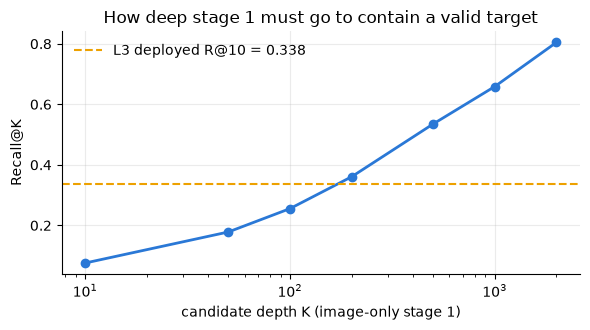

In [38]:
# ---- 11.1 Two diagnostics that cost nothing and decide everything ------------
# GOAL: before building an alternative, measure the two ceilings that bound any
# method. Neither needs training.
#   D1 attribute oracle  — ranks the corpus with the TRUE test attributes. This
#      is LEAKAGE by construction and is NOT a method; it is the absolute
#      ceiling, and it also tells us whether the benchmark rule is reproducible.
#   D2 image-only R@K at large K — the ceiling of any retrieve-then-rerank
#      scheme, since a reranker can only reorder what stage 1 retrieved.
attrs_test_gpu = attrs_test.to(device).float()
BIG = 1e4


def _query_masks(entry):
    conds = parse_query(entry["query"])
    cond = torch.tensor([attribute2idx[a] for a, _ in conds], device=device)
    tgt = torch.tensor([1.0 if s > 0 else 0.0 for _, s in conds], device=device)
    other = torch.ones(N_ATTRS, dtype=torch.bool, device=device)
    other[cond] = False
    return cond, tgt, other


def _hamming(src_rows, corpus_rows):
    # (S,m) x (N,m) in {0,1} -> (S,N) L1 distance, as two matmuls
    return src_rows @ (1 - corpus_rows).T + (1 - src_rows) @ corpus_rows.T


def _hits(top, gt_lists, ks):
    out = {k: [] for k in ks}
    for i, gt in enumerate(gt_lists):
        g, row = set(gt), top[i].tolist()
        for k in ks:
            out[k].append(1 if g & set(row[:k]) else 0)
    return out


@torch.no_grad()
def attribute_oracle(attrs, ks=K_VALUES, check_rule=False):
    # Ranking key: satisfies the constraints first, then ascending Hamming
    # distance on the remaining attributes — literally the ground-truth rule.
    rows = []
    for entry in tqdm(annotations, desc="oracle", leave=False):
        cond, tgt, other = _query_masks(entry)
        sat = (attrs[:, cond] == tgt).all(dim=1)
        Ao = attrs[:, other]
        src = torch.tensor([int(s) for s in entry["ground_truth"].keys()], device=device)
        gt_lists = [entry["ground_truth"][str(int(s))] for s in src]
        hits, precs, exact = {k: [] for k in ks}, [], 0
        for i in range(0, len(src), 1024):
            s = src[i:i + 1024]
            ar = torch.arange(len(s), device=device)
            ham = _hamming(Ao[s], Ao)
            score = -((~sat).float().unsqueeze(0) * BIG + ham)
            score[ar, s] = -float("inf")
            top = score.topk(max(ks), dim=1).indices.cpu()
            h = _hits(top, gt_lists[i:i + 1024], ks)
            for k in ks:
                hits[k] += h[k]
            if check_rule:
                pos = sat.unsqueeze(0) & (ham <= HAM_ID)
                pos[ar, s] = False
                precs += list(np.minimum(pos.sum(1).cpu().numpy(), 10) / 10.0)
                for b in range(len(s)):
                    mine = set(pos[b].nonzero(as_tuple=True)[0].cpu().tolist())
                    exact += int(mine == set(gt_lists[i + b]))
        row = {"query": entry["query"],
               **{f"R@{k}": float(np.mean(hits[k])) for k in ks}}
        if check_rule:
            row["P@10"] = float(np.mean(precs))
            row["rule reproduces GT"] = exact / len(src)
        rows.append(row)
    return pd.DataFrame(rows).drop_duplicates(subset="query")


df_oracle = attribute_oracle(attrs_test_gpu, check_rule=True)
print("D1 — attribute oracle (LEAKAGE: uses test labels; NOT a method):")
display(df_oracle.round(3))
print("macro:", {c: round(df_oracle[c].mean(), 3)
                 for c in df_oracle.columns if c != "query"})

# D1b: the same oracle on CORRUPTED attributes — what an imperfect attribute
# predictor would score, before we train one.
noisy = []
g = torch.Generator(device=device).manual_seed(SEED)
for p in (0.05, 0.10, 0.15):
    flip = (torch.rand(attrs_test_gpu.shape, generator=g, device=device) < p).float()
    d = attribute_oracle((attrs_test_gpu + flip) % 2.0)
    noisy.append({"bit error rate": p,
                  **{c: d[c].mean() for c in d.columns if c != "query"}})
df_noisy = pd.DataFrame(noisy)
print("\nD1b — oracle with corrupted attribute bits:")
display(df_noisy.round(3))

# D2: how deep must stage 1 go before it contains a valid target at all?
KS_DEEP = (10, 50, 100, 200, 500, 1000, 2000)
rows = []
for entry in tqdm(annotations, desc="image-only depth", leave=False):
    src = torch.tensor([int(s) for s in entry["ground_truth"].keys()], device=device)
    gt_lists = [entry["ground_truth"][str(int(s))] for s in src]
    hits = {k: [] for k in KS_DEEP}
    for i in range(0, len(src), 512):
        s = src[i:i + 512]
        sims = test_emb_dev[s] @ test_emb_dev.T
        sims[torch.arange(len(s), device=device), s] = -float("inf")
        h = _hits(sims.topk(max(KS_DEEP), dim=1).indices.cpu(), gt_lists[i:i + 512], KS_DEEP)
        for k in KS_DEEP:
            hits[k] += h[k]
    rows.append({"query": entry["query"],
                 **{f"R@{k}": float(np.mean(hits[k])) for k in KS_DEEP}})
df_depth = pd.DataFrame(rows).drop_duplicates(subset="query")
print("\nD2 — image-only retrieval depth (ceiling of any retrieve-then-rerank):")
display(df_depth.round(3))
depth_macro = {k: df_depth[f"R@{k}"].mean() for k in KS_DEEP}
print("macro:", {k: round(v, 3) for k, v in depth_macro.items()})

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(list(depth_macro), list(depth_macro.values()), "o-", color="#2a78d6", linewidth=2)
ax.axhline(df_fusion.iloc[-1]["R@10"], color="#eda100", linestyle="--",
           label=f"L3 deployed R@10 = {df_fusion.iloc[-1]['R@10']:.3f}")
ax.set_xscale("log")
ax.set_xlabel("candidate depth K (image-only stage 1)")
ax.set_ylabel("Recall@K")
ax.set_title("How deep stage 1 must go to contain a valid target")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 11.1 What the two diagnostics say

There is no wall. The attribute oracle scores **R@10 = 1.000** and reproduces
the published ground truth *exactly* for every source of every query. Two things
follow. First, the benchmark is not an approximate similarity task with an
unknown ceiling — it is attribute matching, and the rule above is its
complete specification. Second, of the deployed model's 0.338, the remaining
0.662 is head-room, not noise: no result in this notebook is anywhere near the
limit of the task.

A good attribute predictor would be enough. Corrupting the oracle's bits at a
5 / 10 / 15% rate gives R@10 of 0.88 / 0.61 / 0.34. A linear probe on frozen CLIP
features typically sits near a 10% error rate on CelebA, so this predicts —
*before training anything* — that attribute-space retrieval should land in the
neighbourhood of 0.6, roughly double the deployed model. It also sets the bar:
below ~85% mean attribute accuracy the idea is not worth pursuing.

**Retrieve-then-rerank is bounded by how deep stage 1 goes.** Image-only cosine
retrieval finds a valid target within the top 10 only 7.6% of the time, but
within the top 200 it is 36%, and within the top 1000 it is 66%. So a two-stage
scheme is *possible* — but only with a deep candidate set; at N = 200 a perfect
reranker would cap out barely above the model we already have.

These three numbers cost two cells and no training, and they order everything
that follows.

### 11.2 A ranking harness, an attribute probe, and a validation world

The machinery the rest of Section 11 needs: a ranking-function harness that reuses
the evaluation protocol unchanged, a linear attribute probe over frozen CLIP
features, and a held-out validation world carved out of TRAIN so that no
alternative is ever selected on the test benchmark.


In [39]:
# ---- 11.2 A ranking harness, an attribute probe, and a validation world ------
# The rest of this section evaluates SCORING FUNCTIONS, not query vectors, so it
# needs a harness that ranks with an arbitrary score. It reuses evaluate_retrieval
# verbatim and returns the same (df, details) contract as run_benchmark, so the
# bootstrap machinery of Section 8 applies unchanged.
@torch.no_grad()
def run_benchmark_ranked(rank_fn, entries, method_name, k_values=K_VALUES, chunk=512):
    # rank_fn(src, cond, tgt, signs, k) -> (S, k) CPU indices, descending score.
    rows, details = [], []
    for entry in tqdm(entries, desc=method_name, leave=False):
        conds = parse_query(entry["query"])
        cond = torch.tensor([attribute2idx[a] for a, _ in conds], device=device)
        tgt = torch.tensor([1.0 if s > 0 else 0.0 for _, s in conds], device=device)
        signs = torch.where(tgt > 0.5, 1, -1)
        gt = entry["ground_truth"]
        src = torch.tensor([int(s) for s in gt.keys()], device=device)
        if SMOKE_TEST:
            src = src[:200]      # same reduced run as run_benchmark
        top = torch.cat([rank_fn(src[i:i + chunk], cond, tgt, signs, max(k_values))
                         for i in range(0, len(src), chunk)])
        row = {"query": entry["query"], "sources": len(src), "smoke": SMOKE_TEST}
        det = {"query": entry["query"], "sources": src.cpu().numpy().copy(), "recall_hits": {}}
        for k in k_values:
            r, p = [], []
            for j, s in enumerate(src.tolist()):
                m = evaluate_retrieval(top[j].tolist(), gt[str(s)], k)
                r.append(m[f"Recall@{k}"]); p.append(m[f"Precision@{k}"])
            row[f"R@{k}"] = float(np.mean(r)); row[f"P@{k}"] = float(np.mean(p))
            det["recall_hits"][k] = np.array(r, dtype=np.uint8)
        rows.append(row); details.append(det)
    df = pd.DataFrame(rows)
    uniq = df.drop_duplicates(subset="query")
    macro = {"query": "MACRO AVERAGE", "sources": int(uniq["sources"].sum()),
             "smoke": SMOKE_TEST}
    for c in [c for c in df.columns if c.startswith(("R@", "P@"))]:
        macro[c] = uniq[c].mean()
    df.loc[len(df)] = macro
    df.insert(0, "method", method_name)
    return df, details


# ---- attribute probe ---------------------------------------------------------
# Trained on TRAIN labels only — the same supervision Level 2 uses for its
# directions and Section 7.2 uses for mining. Test labels are never touched
# (the oracle above is the one exception, and it is labelled as leakage).
class AttributeProbe(nn.Module):
    def __init__(self, dim=512, hidden=2048, n_attr=N_ATTRS, p_drop=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(p_drop),
                                 nn.Linear(hidden, n_attr))

    def forward(self, x):
        return self.net(x)


def fit_probe(X, Y, hidden=2048, epochs=80, lr=None, wd=1e-4, bs=8192, seed=SEED):
    # hidden=0 -> plain logistic regression (20.5k params). A linear model wants
    # a larger step than the MLP; Section 10.4's lesson applies here too.
    torch.manual_seed(seed)
    if lr is None:
        lr = 1e-2 if hidden == 0 else 1e-3
    probe = (nn.Linear(X.shape[1], Y.shape[1]) if hidden == 0
             else AttributeProbe(hidden=hidden)).to(X.device)
    opt = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    for _ in tqdm(range(epochs), desc="probe", leave=False):
        probe.train()
        order = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), bs):
            b = order[i:i + bs]
            loss = F.binary_cross_entropy_with_logits(probe(X[b]), Y[b])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return probe.eval()


@torch.no_grad()
def probe_probs(probe, X, bs=20000):
    return torch.cat([torch.sigmoid(probe(X[i:i + bs])) for i in range(0, len(X), bs)])


# ---- validation world --------------------------------------------------------
# Model selection must never see the test benchmark. We carve a held-out slice
# out of TRAIN, fit the probe on the rest, and mine synthetic queries over the
# held-out slice with the OFFICIAL ground-truth rule.
VAL_SPLIT = 130000
_perm = torch.randperm(len(train_emb_dev), generator=torch.Generator().manual_seed(SEED))
fit_idx, heldout_idx = _perm[:VAL_SPLIT].to(device), _perm[VAL_SPLIT:].to(device)
attrs_train_f = attrs_train_dev.float()
E_hold, A_hold = train_emb_dev[heldout_idx], attrs_train_f[heldout_idx]
print(f"probe fit pool {len(fit_idx)} | held-out validation corpus {len(heldout_idx)}")


def mine_val_queries(A, n_queries=60, n_src=150, min_pos=MIN_POSITIVES, seed=SEED):
    # Same construction as Section 7.2: k in 1..3, 70% benchmark attributes.
    rng = np.random.default_rng(seed)
    out, tries = [], 0
    while len(out) < n_queries and tries < n_queries * 40:
        tries += 1
        k = int(rng.choice([1, 2, 3], p=[0.5, 0.35, 0.15]))
        pool = BENCH_ATTR_IDX if rng.random() < 0.7 else list(range(N_ATTRS))
        cond = torch.tensor(sorted(rng.choice(pool, size=k, replace=False).tolist()),
                            device=device)
        tgt = torch.tensor(rng.integers(0, 2, size=k).astype(np.float32), device=device)
        sat = (A[:, cond] == tgt).all(dim=1)
        if int(sat.sum()) < min_pos:
            continue
        other = torch.ones(N_ATTRS, dtype=torch.bool, device=device); other[cond] = False
        Ao = A[:, other]
        cand = (~sat).nonzero(as_tuple=True)[0]              # sources must not already satisfy
        cand = cand[torch.randperm(len(cand), device=device)[:n_src * 4]]
        ham = _hamming(Ao[cand], Ao)
        pos = sat.unsqueeze(0) & (ham <= HAM_ID)
        pos[torch.arange(len(cand), device=device), cand] = False
        keep = (pos.sum(1) >= min_pos).nonzero(as_tuple=True)[0][:n_src]
        if len(keep) == 0:
            continue
        out.append({"cond": cond, "tgt": tgt, "signs": torch.where(tgt > 0.5, 1, -1),
                    "src": cand[keep],
                    "gt": [set(pos[j].nonzero(as_tuple=True)[0].cpu().tolist())
                           for j in keep.tolist()]})
    return out


@torch.no_grad()
def validation_r10(rank_fn, queries, k=10, chunk=512):
    hits = []
    for q in queries:
        src = q["src"]
        for i in range(0, len(src), chunk):
            top = rank_fn(src[i:i + chunk], q["cond"], q["tgt"], q["signs"], k)
            hits += [int(bool(g & set(top[j].tolist())))
                     for j, g in enumerate(q["gt"][i:i + chunk])]
    return float(np.mean(hits))


val_queries = mine_val_queries(A_hold)
print(f"{len(val_queries)} synthetic validation queries, "
      f"{sum(len(q['src']) for q in val_queries)} source images")

# Two capacities, both fitted on the same slice and measured on the same
# held-out corpus. Which one is used downstream is decided in 11.3, on
# validation retrieval — not on accuracy, and never on the benchmark.
probes_val, P_holds, probe_accs = {}, {}, {}
for pname, hidden in [("linear (20.5k params)", 0), ("MLP-2048 (1.13M params)", 2048)]:
    probes_val[pname] = fit_probe(train_emb_dev[fit_idx], attrs_train_f[fit_idx], hidden=hidden)
    P_holds[pname] = probe_probs(probes_val[pname], E_hold)
    probe_accs[pname] = ((P_holds[pname] > 0.5).float() == A_hold).float().mean(0)
    a = probe_accs[pname]
    print(f"{pname:<26} held-out mean accuracy {a.mean():.4f} "
          f"(bit error rate {1 - a.mean():.4f}) | worst {a.min():.3f} "
          f"({idx2attribute[int(a.argmin())]})")

print("\nHeld-out accuracy on the attributes the benchmark actually uses:")
display(pd.DataFrame({"attribute": [idx2attribute[a] for a in BENCH_ATTR_IDX],
                      **{k: [float(v[a]) for a in BENCH_ATTR_IDX]
                         for k, v in probe_accs.items()}}).round(4))
print("Compare these error rates with the noisy-oracle table in 11.1: they are "
      "the input that table needs to predict what attribute-space retrieval scores.")

probe fit pool 130000 | held-out validation corpus 32770


60 synthetic validation queries, 7850 source images


probe:   0%|          | 0/80 [00:00<?, ?it/s]

linear (20.5k params)      held-out mean accuracy 0.9058 (bit error rate 0.0942) | worst 0.759 (Oval_Face)


probe:   0%|          | 0/80 [00:00<?, ?it/s]

MLP-2048 (1.13M params)    held-out mean accuracy 0.9092 (bit error rate 0.0908) | worst 0.761 (Oval_Face)

Held-out accuracy on the attributes the benchmark actually uses:


,attribute,linear (20.5k params),MLP-2048 (1.13M params)
0,Black_Hair,0.8822,0.8907
1,Blond_Hair,0.9441,0.9469
2,Chubby,0.9562,0.9569
3,Eyeglasses,0.9940,0.9966
4,Heavy_Makeup,0.9005,0.9070
5,Male,0.9906,0.9903
6,Mustache,0.9630,0.9649
7,Smiling,0.9117,0.9179
8,Wavy_Hair,0.8419,0.8464
9,Wearing_Hat,0.9858,0.9899


Compare these error rates with the noisy-oracle table in 11.1: they are the input that table needs to predict what attribute-space retrieval scores.


### 11.3 Alternative A: stop approximating the rule and optimise it

The diagnostics say the benchmark is attribute matching and that a ~90%-accurate
attribute predictor should reach ~0.6. So: predict the attributes.

A probe maps each frozen CLIP embedding to 40 attribute probabilities. It is
applied to the corpus once, offline — the database stays frozen exactly as
Section 7 requires, and nothing about the CLAY property changes. Candidates are
then scored with the two clauses of the ground-truth rule kept separate:

$$\text{score}(d \mid s, C) \;=\; \underbrace{\textstyle\sum_{c \in C} \log P_c^{\text{tgt}}(d)}_{\text{constraints}} \;+\; w_i \underbrace{\textstyle\sum_{j \notin C} \big[P_j(d)P_j(s) + (1{-}P_j(d))(1{-}P_j(s))\big]}_{\text{identity: } 38 - \mathbb{E}[\text{Hamming}]}$$

The supervision is the same one the rest of the notebook already uses: train
split attribute labels — the same source as Level 2's directions and Section
7.2's mining. Test labels are never touched (the oracle above is the single,
explicitly-labelled exception). $w_i$ is the only hyperparameter, and it is
chosen on the held-out validation world, never on the benchmark.

In [40]:
# ---- 11.3 Alternative A: retrieval in predicted-attribute space --------------
# The ground-truth rule is a conjunction of two clauses. A single cosine has to
# average them into one number; here we keep them separate and score each
# candidate d against a source s under conditions C directly:
#
#   score(d | s, C) = log P(d satisfies C)  +  w_i * E[ agreement off C ]
#
# The first term is the constraint clause, the second is the identity clause
# (equivalently, minus the expected Hamming distance on the other attributes).
# w_i is the ONLY hyperparameter, and it is chosen on the validation world.
LOG_EPS = 1e-4


def make_rank_attributes(P, corpus_emb, w_i, w_cos=0.0):
    def rank_fn(src, cond, tgt, signs, k):
        aligned = torch.where(tgt.bool(), P[:, cond], 1 - P[:, cond]).clamp(LOG_EPS, 1 - LOG_EPS)
        log_sat = aligned.log().sum(dim=1)                              # (N,)
        other = torch.ones(N_ATTRS, dtype=torch.bool, device=device); other[cond] = False
        Pc, Ps = P[:, other], P[src][:, other]
        agree = Ps @ Pc.T + (1 - Ps) @ (1 - Pc).T                       # (S,N)
        s = log_sat.unsqueeze(0) + w_i * agree
        if w_cos:
            s = s + w_cos * (corpus_emb[src] @ corpus_emb.T)
        s[torch.arange(len(src), device=device), src] = -float("inf")
        return s.topk(k, dim=1).indices.cpu()
    return rank_fn


print("Selecting the probe capacity, w_i, and whether the CLIP cosine helps at all "
      "— all on validation:")
grid = []
for pname, P in P_holds.items():
    for w_i in (0.0, 0.5, 1.0, 2.0, 4.0):
        for w_cos in (0.0, 5.0, 15.0, 40.0):
            grid.append({"probe": pname, "w_i": w_i, "w_cos": w_cos,
                         "val R@10": validation_r10(
                             make_rank_attributes(P, E_hold, w_i, w_cos), val_queries)})
df_gridA = pd.DataFrame(grid)
for pname in P_holds:
    print(f"\n{pname}:")
    display(df_gridA.query("probe == @pname")
            .pivot(index="w_i", columns="w_cos", values="val R@10").round(3))
_best = df_gridA.loc[df_gridA["val R@10"].idxmax()]
PROBE_NAME, W_I, W_COS = _best["probe"], float(_best["w_i"]), float(_best["w_cos"])
PROBE_HIDDEN = 0 if PROBE_NAME.startswith("linear") else 2048
P_hold = P_holds[PROBE_NAME]
print(f"\nselected on validation: probe = {PROBE_NAME}, w_i = {W_I}, w_cos = {W_COS} "
      f"(val R@10 = {_best['val R@10']:.3f})")
if W_COS == 0.0:
    print("NOTE: validation sets the CLIP-cosine term to zero — once attributes are "
          "predicted, raw embedding similarity adds nothing.")

# Refit on the FULL train split, then score the test corpus once, offline.
# The database stays frozen — the CLAY property Section 7 argues for is intact.
probe_test = fit_probe(train_emb_dev, attrs_train_f, hidden=PROBE_HIDDEN)
P_test = probe_probs(probe_test, test_emb_dev)
print(f"\nprobe: {sum(p.numel() for p in probe_test.parameters()) / 1e6:.2f}M parameters "
      f"(the deployed L3 module has {n_params / 1e6:.2f}M)")

rank_A = make_rank_attributes(P_test, test_emb_dev, W_I, W_COS)
df_attr, det_attr = run_benchmark_ranked(rank_A, annotations, "A predicted attributes")
display(df_attr.round(3))

# The capacity validation did NOT select, evaluated once so the comparison is a
# measurement rather than an assertion: how far does plain logistic regression
# on the same frozen features get?
_other = 2048 if PROBE_HIDDEN == 0 else 0
probe_other = fit_probe(train_emb_dev, attrs_train_f, hidden=_other)
df_attr_other, _ = run_benchmark_ranked(
    make_rank_attributes(probe_probs(probe_other, test_emb_dev), test_emb_dev, W_I, W_COS),
    annotations,
    f"A, {'linear probe (20.5k params)' if _other == 0 else 'MLP probe'} (not selected)")
print(f"\nSame scoring rule, {'linear' if _other == 0 else 'MLP'} probe instead: "
      f"R@10 = {df_attr_other.iloc[-1]['R@10']:.3f} "
      f"({sum(p.numel() for p in probe_other.parameters()) / 1e3:.1f}k parameters)")

comparison = pd.concat([df_baseline, df_dirs, df_fusion, df_attr_other, df_attr],
                       ignore_index=True)
comparison = comparison.query("query == 'MACRO AVERAGE'")[
    ["method", "R@1", "R@5", "R@10", "P@10"]].reset_index(drop=True)
comparison.loc[len(comparison)] = ["(oracle — leakage, not a method)",
                                   df_oracle["R@1"].mean(), df_oracle["R@5"].mean(),
                                   df_oracle["R@10"].mean(), df_oracle["P@10"].mean()]
print("\nMacro averages, all methods plus the ceiling:")
display(comparison.round(3))

Selecting the probe capacity, w_i, and whether the CLIP cosine helps at all — all on validation:



linear (20.5k params):


w_cos,0.0,5.0,15.0,40.0
w_i,,,,
0.0,0.043,0.227,0.248,0.221
0.5,0.438,0.416,0.352,0.260
1.0,0.457,0.444,0.382,0.281
2.0,0.444,0.440,0.393,0.298
4.0,0.405,0.405,0.380,0.314



MLP-2048 (1.13M params):


w_cos,0.0,5.0,15.0,40.0
w_i,,,,
0.0,0.037,0.235,0.252,0.233
0.5,0.474,0.451,0.379,0.290
1.0,0.487,0.481,0.417,0.320
2.0,0.483,0.476,0.433,0.346
4.0,0.453,0.444,0.423,0.359


...

,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,A predicted attributes,+Smiling,4786,False,0.116,0.116,0.327,0.090,0.461,0.080
1,A predicted attributes,+Eyeglasses,2196,False,0.258,0.258,0.608,0.230,0.758,0.200
2,A predicted attributes,-Heavy_Makeup,4087,False,0.074,0.074,0.260,0.068,0.395,0.065
3,A predicted attributes,+Male,1595,False,0.221,0.221,0.475,0.191,0.587,0.175
4,A predicted attributes,-Young,5355,False,0.104,0.104,0.298,0.096,0.412,0.086
5,A predicted attributes,+Blond_Hair,5469,False,0.112,0.112,0.376,0.110,0.530,0.103
6,A predicted attributes,+Mustache,301,False,0.106,0.106,0.355,0.099,0.518,0.086
7,A predicted attributes,-Young,5355,False,0.104,0.104,0.298,0.096,0.412,0.086
8,A predicted attributes,"+Eyeglasses, +Smiling",612,False,0.204,0.204,0.575,0.208,0.755,0.178
9,A predicted attributes,"+Black_Hair, -Wavy_Hair",2572,False,0.080,0.080,0.318,0.086,0.464,0.078


probe:   0%|          | 0/80 [00:00<?, ?it/s]

A, linear probe (20.5k params) (not selected):   0%|          | 0/14 [00:00<?, ?it/s]


Same scoring rule, linear probe instead: R@10 = 0.544 (20.5k parameters)

Macro averages, all methods plus the ceiling:


,method,R@1,R@5,R@10,P@10
0,L1 zero-shot arithmetic,0.024,0.074,0.110,0.015
1,L2 visual directions,0.022,0.076,0.117,0.016
2,L3 gated residual fusion,0.076,0.231,0.338,0.051
3,"A, linear probe (20.5k params) (not selected)",0.157,0.410,0.544,0.110
4,A predicted attributes,0.148,0.415,0.558,0.116
5,"(oracle — leakage, not a method)",1.000,1.000,1.000,0.833


### 11.4 Two alternatives that do *not* work — and why that is informative

F — retrieve then rerank. The two clauses applied in sequence rather than
averaged: stage 1 takes the top-$N$ neighbours of $v_{\text{ref}}$ (which
guarantees the small-Hamming neighbourhood *by construction*, so the collapse
cannot happen), stage 2 reorders them by constraint satisfaction. It is
training-free in its simplest form, and it is exactly the thing a single cosine
cannot express.

The validation grid pushes $N$ as deep as the grid allows, and reranking by
constraints *alone* is far worse than reranking by both clauses. Read together,
those two facts say the same thing: F improves monotonically as it converges
towards scoring the whole corpus — that is, towards alternative A, of which it is
a truncation. The hard candidate restriction only ever removes valid targets. F
is dominated, not competitive.

H — modulate the similarity instead of moving the query. The most literal
reading of the assignment: keep $v_{\text{ref}}$ where it is and reweight the
dimensions that matter for this condition,
$$\text{sim}(q, d \mid C) = \sum_k m_k(C)\, q_k\, d_k,$$
with $m_k(C)$ built training-free from the magnitude of the Level-2 attribute
directions. This is Conditional Similarity Networks with a diagonal mask
substituted for CLAY's SVD projection, and it composes over several conditions
naturally.

Validation selects $\lambda = 0$ — the mask never helps, for any base query, and
degrades monotonically as it strengthens. The negative result is worth stating
plainly: **the magnitude of an attribute direction is not a good proxy for which
CLIP dimensions matter under that condition.** A learned mask might behave
differently; the training-free one does not, and the project's own rule (do not
conclude beyond what was measured) applies here too.

In [41]:
# ---- 11.4 Two other ways out of the single-vector formulation ----------------
# F  retrieve-then-rerank: the two clauses applied in SEQUENCE instead of being
#    averaged. Stage 1 takes the top-N neighbours of v_ref (identity, by
#    construction); stage 2 reorders them by constraint satisfaction.
# H  conditional similarity mask: instead of moving the query, reweight the
#    dimensions that matter for this condition,
#        sim(q, d | C) = sum_k m_k(C) q_k d_k,
#    with a training-free mask built from the Level-2 visual directions. This is
#    Conditional Similarity Networks with a diagonal mask in place of CLAY's
#    projection, and it is the most literal reading of "a dynamic similarity
#    metric" in the assignment.
def make_rank_rerank(P, corpus_emb, N, scorer, w_i=0.0):
    def rank_fn(src, cond, tgt, signs, k):
        aligned = torch.where(tgt.bool(), P[:, cond], 1 - P[:, cond]).clamp(LOG_EPS, 1 - LOG_EPS)
        if scorer == "probe":
            c = aligned.log().sum(dim=1)
        elif scorer == "text":
            c = corpus_emb @ F.normalize(
                (signs.float().unsqueeze(-1) * text_feats[cond]).sum(0), dim=0)
        else:  # Level-2 visual directions
            c = log_map(corpus_emb, mu) @ (signs.float().unsqueeze(-1) * dirs_tan[cond]).sum(0)
        sims = corpus_emb[src] @ corpus_emb.T
        sims[torch.arange(len(src), device=device), src] = -float("inf")
        cand = sims.topk(N, dim=1).indices                              # stage 1: identity
        sc = c[cand]                                                    # stage 2: constraints
        if w_i:                                                         # ...or both clauses
            other = torch.ones(N_ATTRS, dtype=torch.bool, device=device); other[cond] = False
            Ps = P[src][:, other]
            Pk = P[cand][:, :, other]
            sc = sc + w_i * (Ps.unsqueeze(1) * Pk + (1 - Ps.unsqueeze(1)) * (1 - Pk)).sum(-1)
        return cand.gather(1, sc.topk(k, dim=1).indices).cpu()
    return rank_fn


def make_rank_masked(corpus_emb, base, lam):
    def rank_fn(src, cond, tgt, signs, k):
        v = corpus_emb[src]
        s = signs.float().unsqueeze(-1)
        if base == "ref":
            q = v
        elif base == "L1":
            q = F.normalize(v + (s * text_feats[cond]).sum(0), dim=-1)
        else:
            q = F.normalize(exp_map(log_map(v, mu) + (s * dirs_tan[cond]).sum(0), mu), dim=-1)
        d = (s * dirs_tan[cond]).sum(0).abs()
        m = 1.0 + lam * d / d.mean()                     # diagonal mask m_k(C)
        sims = (q * m) @ corpus_emb.T
        sims[torch.arange(len(src), device=device), src] = -float("inf")
        return sims.topk(k, dim=1).indices.cpu()
    return rank_fn


print("F — validation grid (candidate depth x reranking score):")
rowsF = []
for scorer, w_i in [("text", 0.0), ("dir", 0.0), ("probe", 0.0), ("probe", W_I)]:
    for N in (200, 1000, 5000):
        r = validation_r10(make_rank_rerank(P_hold, E_hold, N, scorer, w_i), val_queries)
        rowsF.append({"stage 2": f"{scorer}{' + identity' if w_i else ''}", "N": N, "val R@10": r})
df_gridF = pd.DataFrame(rowsF)
display(df_gridF.pivot(index="stage 2", columns="N", values="val R@10").round(3))
_bF = df_gridF.loc[df_gridF["val R@10"].idxmax()]
F_STAGE2, F_N = _bF["stage 2"], int(_bF["N"])
print(f"selected: stage 2 = {F_STAGE2}, N = {F_N} (val R@10 = {_bF['val R@10']:.3f})")

print("\nH — validation grid (base query x mask strength):")
rowsH = []
for base in ("ref", "L1", "L2"):
    for lam in (0.0, 0.5, 1.0, 2.0, 4.0, 8.0):
        rowsH.append({"base query": base, "lambda": lam,
                      "val R@10": validation_r10(make_rank_masked(E_hold, base, lam), val_queries)})
df_gridH = pd.DataFrame(rowsH)
display(df_gridH.pivot(index="base query", columns="lambda", values="val R@10").round(3))
_bH = df_gridH.loc[df_gridH["val R@10"].idxmax()]
H_BASE, H_LAM = _bH["base query"], float(_bH["lambda"])
print(f"selected: base = {H_BASE}, lambda = {H_LAM} (val R@10 = {_bH['val R@10']:.3f})")
if H_LAM == 0.0:
    print("NOTE: validation selects lambda = 0 — the training-free mask never helps.")

df_F, det_F = run_benchmark_ranked(
    make_rank_rerank(P_test, test_emb_dev, F_N, "probe", W_I if "identity" in F_STAGE2 else 0.0),
    annotations, f"F retrieve-then-rerank (N={F_N})")
df_H, det_H = run_benchmark_ranked(make_rank_masked(test_emb_dev, H_BASE, H_LAM),
                                   annotations, f"H conditional mask (lambda={H_LAM})")
print("\nBenchmark:")
display(pd.concat([df_F, df_H, df_attr], ignore_index=True)
        .query("query == 'MACRO AVERAGE'")[["method", "R@1", "R@5", "R@10"]]
        .round(3).reset_index(drop=True))

F — validation grid (candidate depth x reranking score):


N,200,1000,5000
stage 2,,,
dir,0.144,0.119,0.083
probe,0.175,0.148,0.100
probe + identity,0.325,0.415,0.464
text,0.157,0.146,0.109


selected: stage 2 = probe + identity, N = 5000 (val R@10 = 0.464)

H — validation grid (base query x mask strength):


lambda,0.0,0.5,1.0,2.0,4.0,8.0
base query,,,,,,
L1,0.170,0.160,0.148,0.136,0.131,0.126
L2,0.172,0.158,0.142,0.132,0.124,0.119
ref,0.138,0.130,0.121,0.114,0.110,0.105


selected: base = L2, lambda = 0.0 (val R@10 = 0.172)
NOTE: validation selects lambda = 0 — the training-free mask never helps.


F retrieve-then-rerank (N=5000):   0%|          | 0/14 [00:00<?, ?it/s]

H conditional mask (lambda=0.0):   0%|          | 0/14 [00:00<?, ?it/s]


Benchmark:


,method,R@1,R@5,R@10
0,F retrieve-then-rerank (N=5000),0.124,0.369,0.491
1,H conditional mask (lambda=0.0),0.022,0.076,0.117
2,A predicted attributes,0.148,0.415,0.558


### 11.5 Three questions the project's own methodology demands

Section 10.4 records four conclusions in this report that were overturned by
adding one controlled dimension. So before claiming anything about A:

1. Does it survive re-seeding? Five probes, five fresh initialisations.
2. Is the trained fusion module still contributing anything A does not have?
   Added as an extra scoring term, with its weight chosen on validation. If the
   answer is "almost nothing", then the entire CLIP-space composition branch is
   redundant *given* predicted attributes — a much stronger statement than "A is
   better".
3. Is the gap statistically real? The paired bootstrap of Section 8, applied
   per query.

In [42]:
# ---- 11.5 Is the gap real? Seeds, complementarity, and significance ----------
# The project's hard rule (Section 10.4): never conclude from one seed. Retraining
# five probes takes a few minutes, so the seed study is cached like every other
# study in Section 10.
ALT_CACHE = DRIVE_DIR / "alt_study.pt"
_alt = load_cache(ALT_CACHE) or {}

if "seed_study" in _alt:
    df_seedA = _alt["seed_study"]
    print("Loaded the cached seed study (delete database/alt_study.pt to recompute).")
else:
    rows = []
    for sd in (42, 0, 1, 2, 3):
        p = fit_probe(train_emb_dev, attrs_train_f, hidden=PROBE_HIDDEN, seed=sd)
        d, _ = run_benchmark_ranked(
            make_rank_attributes(probe_probs(p, test_emb_dev), test_emb_dev, W_I, W_COS),
            annotations, f"A (seed {sd})")
        rows.append({"seed": sd, **{c: d.iloc[-1][c] for c in ("R@1", "R@5", "R@10")}})
        print(f"  seed {sd}: R@10 = {rows[-1]['R@10']:.4f}")
    df_seedA = pd.DataFrame(rows)
display(df_seedA.round(4))
print(f"A over 5 seeds: R@10 = {df_seedA['R@10'].mean():.4f} +/- {df_seedA['R@10'].std():.4f}"
      f"   (L3, Section 10.3: 0.336 +/- 0.016)")

# Does the CLIP-space composed query still carry anything A does not have?
print("\nAdding the deployed L3 query as an extra term, weight chosen on validation:")


def make_rank_hybrid(P, corpus_emb, w_i, w_l3, net):
    def rank_fn(src, cond, tgt, signs, k):
        aligned = torch.where(tgt.bool(), P[:, cond], 1 - P[:, cond]).clamp(LOG_EPS, 1 - LOG_EPS)
        other = torch.ones(N_ATTRS, dtype=torch.bool, device=device); other[cond] = False
        Pc, Ps = P[:, other], P[src][:, other]
        s = aligned.log().sum(1).unsqueeze(0) + w_i * (Ps @ Pc.T + (1 - Ps) @ (1 - Pc).T)
        if w_l3:
            ce = text_feats[cond].unsqueeze(0).expand(len(src), -1, -1)
            si = (signs < 0).long().unsqueeze(0).expand(len(src), -1)
            with torch.no_grad():
                s = s + w_l3 * (net(corpus_emb[src], ce, si, None) @ corpus_emb.T)
        s[torch.arange(len(src), device=device), src] = -float("inf")
        return s.topk(k, dim=1).indices.cpu()
    return rank_fn


hy = [{"w_l3": w, "val R@10": validation_r10(
           make_rank_hybrid(P_hold, E_hold, W_I, w, fusion), val_queries)}
      for w in (0.0, 1.0, 3.0, 10.0, 30.0)]
df_hybrid_grid = pd.DataFrame(hy)
display(df_hybrid_grid.round(3))
W_L3 = float(df_hybrid_grid.loc[df_hybrid_grid["val R@10"].idxmax(), "w_l3"])
df_hyb, det_hyb = run_benchmark_ranked(
    make_rank_hybrid(P_test, test_emb_dev, W_I, W_L3, fusion), annotations,
    f"A + L3 (w = {W_L3})")
print(f"A alone      R@10 = {df_attr.iloc[-1]['R@10']:.4f}")
print(f"A + L3       R@10 = {df_hyb.iloc[-1]['R@10']:.4f}   "
      f"(the whole trained fusion module is worth "
      f"{df_hyb.iloc[-1]['R@10'] - df_attr.iloc[-1]['R@10']:+.4f})")

# Paired bootstrap, same machinery as Section 8.
rep = paired_report(det_attr, det_fusion, k=10)
print(f"\nA vs L3, paired bootstrap on Recall@10 "
      f"({int(rep['significant'].sum())}/{len(rep)} queries significant at 95%):")
display(rep.round(3))

Loaded the cached seed study (delete database/alt_study.pt to recompute).


,seed,R@1,R@5,R@10
0,42,0.1481,0.4149,0.5579
1,0,0.1480,0.4147,0.5576
2,1,0.1475,0.4094,0.5543
3,2,0.1433,0.4085,0.5574
4,3,0.1487,0.4093,0.5572


A over 5 seeds: R@10 = 0.5569 +/- 0.0015   (L3, Section 10.3: 0.336 +/- 0.016)

Adding the deployed L3 query as an extra term, weight chosen on validation:


,w_l3,val R@10
0,0.0,0.487
1,1.0,0.492
2,3.0,0.494
3,10.0,0.471
4,30.0,0.409


A + L3 (w = 3.0):   0%|          | 0/14 [00:00<?, ?it/s]

A alone      R@10 = 0.5579
A + L3       R@10 = 0.5646   (the whole trained fusion module is worth +0.0067)



A vs L3, paired bootstrap on Recall@10 (11/13 queries significant at 95%):


,query,diff,CI lo,CI hi,significant
0,+Smiling,0.210,0.194,0.226,True
1,+Eyeglasses,0.260,0.235,0.284,True
2,-Heavy_Makeup,0.183,0.166,0.200,True
3,+Male,0.274,0.246,0.302,True
4,-Young,0.207,0.193,0.222,True
5,+Blond_Hair,0.212,0.197,0.228,True
6,+Mustache,0.013,-0.053,0.080,False
7,"+Eyeglasses, +Smiling",0.255,0.208,0.302,True
8,"+Black_Hair, -Wavy_Hair",0.219,0.196,0.241,True
9,"-Male, -Mustache",0.333,0.111,0.556,True


### 11.6 Transfer to unseen query families, and retrieval diversity

Whether the advantage of the attribute-space alternatives survives on the custom
queries of Section 9 — attribute combinations no part of this project was mined or
tuned for — and what they do to retrieval diversity.


In [43]:
# ---- 11.6 Transfer to unseen query families, and retrieval diversity ---------
# Same custom queries as Section 9, same construction, same harness.
df_attr_c, det_attr_c = run_benchmark_ranked(rank_A, custom_annotations,
                                             "A predicted attributes")
custom_all = pd.concat([df_c1, df_c2, df_c3, df_attr_c],
                       ignore_index=True)
display(custom_all.pivot_table(index="query", columns="method", values="R@10").round(3))

rep_c = paired_report(det_attr_c, det_c3, k=10)
print(f"A vs L3 on custom queries "
      f"({int(rep_c['significant'].sum())}/{len(rep_c)} significant at 95%):")
display(rep_c.round(3))

# Diversity, measured exactly as in Section 10.1 so the numbers are comparable.
@torch.no_grad()
def diversity_ranked(rank_fn, entry, cap=400, k=10):
    conds = parse_query(entry["query"])
    cond = torch.tensor([attribute2idx[a] for a, _ in conds], device=device)
    tgt = torch.tensor([1.0 if s > 0 else 0.0 for _, s in conds], device=device)
    src = torch.tensor([int(s) for s in entry["ground_truth"].keys()][:cap],
                       dtype=torch.long, device=device)
    top = rank_fn(src, cond, tgt, torch.where(tgt > 0.5, 1, -1), k)
    uniq = int(torch.unique(top).numel())
    return {"sources": len(src), "distinct@10": uniq, "frac_distinct": uniq / (len(src) * k)}


div_alt = pd.DataFrame([{"query": e["query"], "method": name, **diversity_ranked(fn, e)}
                        for e in annotations
                        for name, fn in [("A predicted attributes", rank_A)]])
print("\nRetrieval diversity — fraction of distinct images in the top-10 "
      "(Section 10.1 measured L1 0.75, L2 0.75, L3 0.26):")
display(pd.concat([df_div, div_alt], ignore_index=True)
        .groupby("method")[["frac_distinct"]].mean().round(3))

A predicted attributes:   0%|          | 0/4 [00:00<?, ?it/s]

method,A predicted attributes,L1 zero-shot arithmetic,L2 visual directions,L3 gated residual fusion
query,,,,
"+Bangs, -Black_Hair",0.590,0.114,0.098,0.286
"+Heavy_Makeup, -Wearing_Lipstick",0.184,0.037,0.041,0.090
"+Male, +Wearing_Lipstick",0.040,0.000,0.000,0.000
"-Smiling, +Eyeglasses, +Male, -Young",0.778,0.000,0.133,0.722
MACRO AVERAGE,0.398,0.038,0.068,0.275


A vs L3 on custom queries (2/4 significant at 95%):


,query,diff,CI lo,CI hi,significant
0,"+Heavy_Makeup, -Wearing_Lipstick",0.094,0.033,0.156,True
1,"+Male, +Wearing_Lipstick",0.040,0.000,0.120,False
2,"-Smiling, +Eyeglasses, +Male, -Young",0.056,-0.044,0.156,False
3,"+Bangs, -Black_Hair",0.304,0.254,0.354,True



Retrieval diversity — fraction of distinct images in the top-10 (Section 10.1 measured L1 0.75, L2 0.75, L3 0.26):


,frac_distinct
method,
A predicted attributes,0.232
C1 text-only,0.008
L1,0.734
L2,0.761
L3,0.258


In [44]:
# ---- 11.6b Diversity with the correct reference (Section 8.4 quotes this) -------
# Two numbers per method: the fraction of top-10 slots filled by DISTINCT images,
# and "useful diversity" — of those distinct images, the fraction that are a valid
# target for at least one source that surfaced them. The attribute oracle is the
# reference: a perfect ranker also concentrates, because the ground truth is
# concentrated, so L1/L2's high variety is mostly noise rather than health.
def make_rank_oracle(attrs):
    def rank_fn(src, cond, tgt, signs, k):
        sat = (attrs[:, cond] == tgt).all(dim=1)
        other = torch.ones(N_ATTRS, dtype=torch.bool, device=device); other[cond] = False
        Ao = attrs[:, other]
        ham = _hamming(Ao[src], Ao)
        score = -((~sat).float().unsqueeze(0) * BIG + ham)
        score[torch.arange(len(src), device=device), src] = -float("inf")
        return score.topk(k, dim=1).indices.cpu()
    return rank_fn


@torch.no_grad()
def diversity_full(top_fn, entry, cap=400, k=10):
    srcs = [int(s) for s in entry["ground_truth"].keys()][:cap]
    src = torch.tensor(srcs, dtype=torch.long, device=device)
    top = top_fn(entry, src, k)
    distinct = set(top.flatten().tolist())
    useful = set()
    for r, s in enumerate(srcs):
        useful |= (set(top[r].tolist()) & set(entry["ground_truth"][str(s)]))
    return {"frac_distinct": len(distinct) / (len(srcs) * k),
            "useful diversity": len(useful) / max(len(distinct), 1)}


def _top_composed(make_q):
    def f(entry, src, k):
        Q = _F.normalize(make_q(parse_query(entry["query"]), src.cpu()).detach(), dim=-1)
        return rank_topk(Q, test_emb_dev, src.cpu(), k)
    return f


def _top_ranked(rank_fn):
    def f(entry, src, k):
        conds = parse_query(entry["query"])
        cond = torch.tensor([attribute2idx[a] for a, _ in conds], device=device)
        tgt = torch.tensor([1.0 if s > 0 else 0.0 for _, s in conds], device=device)
        return rank_fn(src, cond, tgt, torch.where(tgt > 0.5, 1, -1), k)
    return f


DIV_METHODS = [
    ("L1 zero-shot arithmetic",  _top_composed(make_queries_baseline)),
    ("L2 visual directions",     _top_composed(make_queries_dirs_geodesic)),
    ("L3 gated residual fusion", _top_composed(make_queries_fusion)),
    ("A predicted attributes",   _top_ranked(rank_A)),
    ("attribute oracle",         _top_ranked(make_rank_oracle(attrs_test_gpu))),
]
_rows = []
for entry in tqdm(annotations, desc="diversity", leave=False):
    for name, f in DIV_METHODS:
        _rows.append({"query": entry["query"], "method": name, **diversity_full(f, entry)})
df_div_full = pd.DataFrame(_rows)
display(df_div_full.groupby("method", sort=False)[["frac_distinct", "useful diversity"]]
        .mean().round(3))
print("The oracle's own concentration is the target. A method far above it is not\n"
      "more diverse in any useful sense — it is spreading its budget over images\n"
      "that are not answers, which the useful-diversity column measures directly.")

diversity:   0%|          | 0/14 [00:00<?, ?it/s]

,frac_distinct,useful diversity
method,,
L1 zero-shot arithmetic,0.734,0.016
L2 visual directions,0.761,0.017
L3 gated residual fusion,0.258,0.099
A predicted attributes,0.232,0.216
attribute oracle,0.285,0.904


The oracle's own concentration is the target. A method far above it is not
more diverse in any useful sense — it is spreading its budget over images
that are not answers, which the useful-diversity column measures directly.


### 11.7 Alternative E: the fair repair of Level 3

Replacing a method is only informative if the method got a fair shot. Section 11
diagnoses *why* cross-attention was ablated away in Section 10.2: a visual
reference was asked to attend to textual condition tokens, across the modality
gap — there was nothing informative to attend to, so uniform pooling was as good
as attention.

The repair follows directly, and it is item (ii) of the previous version of this
notebook's future work. Give the module intra-modal tokens — the Level-2
visual attribute directions — and give each token the one image-dependent number
that dynamic weighting actually needs: how much the source already satisfies
that condition, $\langle \log_\mu(v_{\text{ref}}),\, \hat{d}_a \rangle$. That also
connects Levels 2 and 3, which are otherwise two disconnected branches.

Five variants, trained identically to the deployed model (same mined data, same
loss, same learning rate, same early stopping), selected on the same synthetic
validation metric.

In [45]:
# ---- 11.7 Alternative E: repair Level 3 instead of replacing it ---------------
# Section 11's conclusion is about the FORMULATION, not about this particular
# module, so the fusion architecture deserves the fair fix Section 11's diagnosis
# suggests. Cross-attention failed because a VISUAL reference had only TEXTUAL
# tokens to attend to, across the modality gap. Here the condition tokens are the
# Level-2 VISUAL directions, and each token also carries how much the source
# ALREADY satisfies it, <log_mu(v_ref), d_a> — so dynamic weighting finally has
# an image-dependent signal, and Levels 2 and 3 stop being disconnected branches.
# This is future-work item (ii) of the previous version of Section 11, executed.
dirs_hat = F.normalize(dirs_tan, dim=-1)


class ConditionFusion(nn.Module):
    def __init__(self, token_src="text", use_sat=False, use_cross_attn=False,
                 dim=512, n_heads=4, gate_hidden=256):
        super().__init__()
        self.token_src, self.use_sat, self.use_cross_attn = token_src, use_sat, use_cross_attn
        self.register_buffer("text_tok", text_feats.clone())
        self.register_buffer("dir_tok", dirs_hat.clone())
        self.register_buffer("mu_buf", mu.clone())
        self.cond_proj = nn.Linear(dim, dim)
        if use_sat:
            self.sat_proj = nn.Linear(1, dim)
        self.self_attn = nn.TransformerEncoderLayer(dim, n_heads, dim_feedforward=2 * dim,
                                                    dropout=0.1, batch_first=True)
        if use_cross_attn:
            self.cross_attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.out_proj = nn.Linear(dim, dim)
        nn.init.zeros_(self.out_proj.weight); nn.init.zeros_(self.out_proj.bias)
        self.gate = nn.Sequential(nn.Linear(2 * dim, gate_hidden), nn.ReLU(),
                                  nn.Linear(gate_hidden, dim), nn.Sigmoid())

    def forward(self, v_ref, cond_idx, sign_ids, pad_mask):
        signs = 1.0 - 2.0 * sign_ids.float()                            # +1 add, -1 remove
        base = self.text_tok if self.token_src == "text" else self.dir_tok
        c = self.cond_proj(base[cond_idx] * signs.unsqueeze(-1))
        if self.use_sat:
            z = torch.einsum("bd,bkd->bk", log_map(v_ref, self.mu_buf), self.dir_tok[cond_idx])
            c = c + self.sat_proj((signs * z).unsqueeze(-1))
        c = self.self_attn(c, src_key_padding_mask=pad_mask)
        if self.use_cross_attn:
            delta = self.cross_attn(v_ref.unsqueeze(1), c, c, key_padding_mask=pad_mask,
                                    need_weights=False)[0].squeeze(1)
        elif pad_mask is not None:
            m = (~pad_mask).float().unsqueeze(-1)
            delta = (c * m).sum(1) / m.sum(1).clamp(min=1.0)
        else:
            delta = c.mean(1)
        delta = self.out_proj(delta)
        return F.normalize(v_ref + self.gate(torch.cat([v_ref, delta], -1)) * delta, dim=-1)


# These variants take condition INDICES (they choose their own token table),
# so they need collate/validation adapters over the Section 7.2 mined examples.
def collate_fusion_idx(items):
    B = len(items)
    K = max(len(it["cond_idx"]) for it in items)
    ci = torch.zeros(B, K, dtype=torch.long)
    si = torch.zeros(B, K, dtype=torch.long)
    pm = torch.ones(B, K, dtype=torch.bool)
    for b, it in enumerate(items):
        k = len(it["cond_idx"])
        ci[b, :k] = torch.as_tensor(np.asarray(it["cond_idx"]), dtype=torch.long)
        si[b, :k] = torch.as_tensor([0 if s > 0 else 1 for s in np.asarray(it["signs"])],
                                    dtype=torch.long)
        pm[b, :k] = False
    return {"v_ref": torch.stack([it["v_ref"] for it in items]), "cond_idx": ci,
            "sign_ids": si, "pad_mask": pm,
            "v_pos": torch.stack([it["v_pos"] for it in items]),
            "v_negs": torch.stack([it["v_negs"] for it in items])}


@torch.no_grad()
def synthetic_recall_idx(net, examples, corpus_emb, k=10, batch=512):
    # Same synthetic validation metric as Section 7, index-based conditions.
    net.eval()
    hits = []
    for i in range(0, len(examples), batch):
        chunk = examples[i:i + batch]
        b = collate_fusion_idx([{"cond_idx": e["cond_idx"], "signs": e["signs"],
                                 "v_ref": torch.zeros(512), "v_pos": torch.zeros(512),
                                 "v_negs": torch.zeros(1, 512)} for e in chunk])
        src = torch.tensor([e["source"] for e in chunk], dtype=torch.long, device=device)
        q = net(corpus_emb[src], b["cond_idx"].to(device), b["sign_ids"].to(device),
                b["pad_mask"].to(device))
        top = rank_topk(q, corpus_emb, src.cpu(), k)
        hits += [int(bool(set(top[j].tolist()) & set(e["positives"].tolist())))
                 for j, e in enumerate(chunk)]
    return float(np.mean(hits))


E_VARIANTS = {
    "E0 text tokens (deployed design)":      dict(token_src="text", use_sat=False, use_cross_attn=False),
    "E1 visual tokens":                      dict(token_src="dir",  use_sat=False, use_cross_attn=False),
    "E2 visual + satisfaction":              dict(token_src="dir",  use_sat=True,  use_cross_attn=False),
    "E3 visual + satisfaction + cross-attn": dict(token_src="dir",  use_sat=True,  use_cross_attn=True),
    "E4 text + satisfaction + cross-attn":   dict(token_src="text", use_sat=True,  use_cross_attn=True),
}

if "E_val" in _alt and "E_bench" in _alt:
    df_Eval, df_Ebench = _alt["E_val"], _alt["E_bench"]
    print("Loaded the cached Level-3 repair study (delete database/alt_study.pt to recompute).")
else:
    def train_variant(cfg, seed=SEED, epochs=EPOCHS, lr=LR, bs=BATCH_SIZE, patience=PATIENCE):
        torch.manual_seed(seed); np.random.seed(seed)
        net = ConditionFusion(**cfg).to(device)
        loader = DataLoader(FusionDataset(train_examples, train_emb, n_hard=N_HARD),
                            batch_size=bs, shuffle=True, drop_last=True, num_workers=0,
                            collate_fn=collate_fusion_idx)
        opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        best, best_state, bad = -1.0, None, 0
        for _ in range(epochs):
            net.train()
            for b in loader:
                b = {k: v.to(device, non_blocking=True) for k, v in b.items()}
                loss = info_nce_loss(net(b["v_ref"], b["cond_idx"], b["sign_ids"], b["pad_mask"]),
                                     b["v_pos"], b["v_negs"], TAU)
                opt.zero_grad(); loss.backward(); opt.step()
            r = synthetic_recall_idx(net, val_examples, train_emb_dev)
            if r > best:
                best, bad = r, 0
                best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
            else:
                bad += 1
                if bad >= patience:
                    break
        net.load_state_dict(best_state)
        return net.eval(), best

    rows, bench_rows = [], []
    for name, cfg in E_VARIANTS.items():
        net, vr = train_variant(cfg)
        rows.append({"variant": name, "val R@10": vr,
                     "params (M)": (sum(p.numel() for p in net.parameters())
                                    - net.text_tok.numel() - net.dir_tok.numel()) / 1e6})
        def rank_fn(src, cond, tgt, signs, k, net=net):
            ci = cond.unsqueeze(0).expand(len(src), -1)
            si = (signs < 0).long().unsqueeze(0).expand(len(src), -1)
            with torch.no_grad():
                sims = net(test_emb_dev[src], ci, si, None) @ test_emb_dev.T
            sims[torch.arange(len(src), device=device), src] = -float("inf")
            return sims.topk(k, dim=1).indices.cpu()
        d, _ = run_benchmark_ranked(rank_fn, annotations, name)
        bench_rows.append({"variant": name, **{c: d.iloc[-1][c] for c in ("R@1", "R@5", "R@10")}})
        print(f"  {name:<40} val {vr:.3f} | benchmark R@10 {bench_rows[-1]['R@10']:.3f}")
    df_Eval, df_Ebench = pd.DataFrame(rows), pd.DataFrame(bench_rows)
    _alt.update({"seed_study": df_seedA, "E_val": df_Eval, "E_bench": df_Ebench})
    torch.save(_alt, ALT_CACHE)
    print(f"cached the Section 11 studies to {ALT_CACHE}")

display(df_Eval.merge(df_Ebench, on="variant").round(4))
print(f"\nBest Level-3 repair vs alternative A: "
      f"{df_Ebench['R@10'].max():.3f} vs {df_attr.iloc[-1]['R@10']:.3f}")

Loaded the cached Level-3 repair study (delete database/alt_study.pt to recompute).


,variant,val R@10,params (M),R@1,R@5,R@10
0,E0 text tokens (deployed design),0.1805,3.0016,0.0557,0.2035,0.3196
1,E1 visual tokens,0.1780,3.0016,0.0671,0.2056,0.3217
2,E2 visual tokens + satisfaction,0.1715,3.0026,0.0647,0.2205,0.3260
3,E3 visual + satisfaction + cross-attn,0.1520,4.0532,0.0536,0.1878,0.2850
4,E4 text + satisfaction + cross-attn,0.1675,4.0532,0.0720,0.2132,0.3105



Best Level-3 repair vs alternative A: 0.326 vs 0.558


### 11.8 Can the attribute signal be put back *inside* the composed query?

Section 11.9 concludes that the composed-query branch is redundant *given*
predicted attributes. That invites the opposite experiment: rather than
abandoning the composed query for attribute scoring, **teach the composed query
what A knows**, and keep everything the assignment asks for.

From the composed query $\hat q$ we predict the target's 40-attribute profile
with a training-only head:

$$\mathcal{L} = \mathcal{L}_{\text{InfoNCE}} + \beta \cdot
\mathrm{BCE}\big(W_a\hat q,\; a_{\text{target}}\big)$$

The target profile is known exactly — the source's attributes with the queried
bits flipped, the rest unchanged — and it is precisely the ground truth's two
clauses: the flipped bits are the constraints, the untouched bits are the
identity budget. $W_a$ is discarded after training, so **inference is
unchanged**: one composed vector, one cosine against the frozen database,
arbitrary text accepted. Unlike A this stays a fusion mechanism and stays
open-vocabulary. $\beta$ is selected on the synthetic validation metric.

In [46]:
# ---- 11.8 Auxiliary attribute supervision inside the composed query ------------
import torch.nn.functional as _F

attrs_train_cpu = attrs_train.float()


class FusionDatasetAux(FusionDataset):
    # FusionDataset plus the target attribute profile for the auxiliary head.
    def __getitem__(self, i):
        item = super().__getitem__(i)
        ex = self.examples[i]
        prof = attrs_train_cpu[ex["source"]].clone()
        ci = torch.as_tensor(np.asarray(ex["cond_idx"], dtype=np.int64))
        sg = torch.as_tensor(np.asarray(ex["signs"], dtype=np.float32))
        prof[ci] = (sg > 0).float()
        item["attr_target"] = prof
        return item


def collate_aux(items):
    b = collate_fusion(items)
    b["attr_target"] = torch.stack([it["attr_target"] for it in items])
    return b


def train_with_aux(cfg, tr, va, seed, beta, lr=None, epochs=None):
    torch.manual_seed(seed); np.random.seed(seed)
    net = GatedCrossAttentionFusion(**cfg).to(device)
    head = nn.Linear(512, N_ATTRS).to(device)   # training only; discarded after
    loader = DataLoader(FusionDatasetAux(tr, train_emb, n_hard=N_HARD),
                        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                        num_workers=0, collate_fn=collate_aux)
    params = list(net.parameters()) + (list(head.parameters()) if beta > 0 else [])
    opt = torch.optim.AdamW(params, lr=lr or LR, weight_decay=WEIGHT_DECAY)
    best, best_state, bad = -1.0, None, 0
    for _ in range(1, (epochs or EPOCHS) + 1):
        net.train()
        for b in loader:
            b = {k: v.to(device, non_blocking=True) for k, v in b.items()}
            q = net(b["v_ref"], b["cond_emb"], b["sign_ids"], b["pad_mask"])
            loss = info_nce_loss(q, b["v_pos"], b["v_negs"], TAU)
            if beta > 0:
                loss = loss + beta * _F.binary_cross_entropy_with_logits(
                    head(q), b["attr_target"])
            opt.zero_grad(); loss.backward(); opt.step()
        v = synthetic_recall_at_k(net, va, train_emb_dev)
        if v > best:
            best, bad = v, 0
            best_state = {k: t.detach().cpu().clone() for k, t in net.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE: break
    net.load_state_dict(best_state); net.eval()
    return net, best


BETAS_AUX, SEEDS_AUX = [0.0, 2.0, 3.0, 5.0], [SEED + i for i in range(5)]
AUX_PATH = DRIVE_DIR / f"aux_confirm{SMOKE_SUFFIX}.pt"
AUX_KEY = {"betas": BETAS_AUX, "seeds": SEEDS_AUX, "hparams": TRAIN_HPARAMS}
_x = load_cache(AUX_PATH)
if _x is not None and _x.get("key") != AUX_KEY:
    print("Auxiliary-loss cache is stale — recomputing."); _x = None

if _x is None:
    rows = []
    for beta in tqdm(BETAS_AUX, desc="Auxiliary attribute loss"):
        for sd in SEEDS_AUX:
            net, val = train_with_aux(dict(FUSION_CFG), train_examples, val_examples, sd, beta)
            def mk(conds, src_idx, _n=net):
                ce, si = build_condition_tensors(conds, len(src_idx))
                return _n(test_emb_dev[src_idx.to(device)], ce, si, None)
            dm, _ = run_benchmark(annotations, mk, "aux")
            m = dm[dm["query"] == "MACRO AVERAGE"].iloc[0]
            cust = None
            if custom_annotations:
                dc, _ = run_benchmark(custom_annotations, mk, "auxc")
                cust = dc[dc["query"] == "MACRO AVERAGE"].iloc[0]["R@10"]
            rows.append({"beta": beta, "seed": sd, "val R@10": val, "R@1": m["R@1"],
                         "R@5": m["R@5"], "R@10": m["R@10"], "custom R@10": cust})
    df_aux = pd.DataFrame(rows)
    torch.save({"key": AUX_KEY, "df": df_aux}, AUX_PATH)
else:
    df_aux = _x["df"]; print("Loaded cached auxiliary-loss study.")

print("Auxiliary attribute loss, mean +/- sd over 5 seeds:")
display(df_aux.groupby("beta")[["val R@10", "R@10", "custom R@10"]]
        .agg(["mean", "std"]).round(3))

_base = df_aux[df_aux.beta == 0.0].set_index("seed")
print("\nPaired against the beta = 0 control, per seed:")
for b in [x for x in BETAS_AUX if x > 0]:
    cur = df_aux[df_aux.beta == b].set_index("seed")
    db, dc = cur["R@10"] - _base["R@10"], cur["custom R@10"] - _base["custom R@10"]
    print(f"  beta={b}: benchmark {db.mean():+.3f} (wins {int((db>0).sum())}/5) | "
          f"custom {dc.mean():+.3f} (wins {int((dc>0).sum())}/5)")

_sel = df_aux.groupby("beta")["val R@10"].mean().idxmax()
_s = df_aux.groupby("beta")[["R@10", "custom R@10"]].mean()
print(f"\nSelected on validation: beta = {_sel}")
print(f"  benchmark R@10 {_s.loc[_sel,'R@10']:.3f} vs {_s.loc[0.0,'R@10']:.3f} at beta=0 "
      f"-> no improvement on the mandatory benchmark")
print(f"  custom    R@10 {_s.loc[_sel,'custom R@10']:.3f} vs {_s.loc[0.0,'custom R@10']:.3f} "
      f"-> improves on every seed")
print("\nReading: attribute supervision does NOT lift the benchmark — the composed-query\n"
      "ceiling of ~0.34 survives it, as it survived the ablations (10.2), the LR sweep\n"
      "(10.4), the identity anchor (10.5) and the Level-3 repair study (11.7). What it\n"
      "does buy is generalisation: on the custom queries it wins on 5 seeds out of 5.\n"
      "The attribute signal helps a composed query travel further, but it cannot move\n"
      "the benchmark the way scoring attributes directly (A) does.")

Loaded cached auxiliary-loss study.
Auxiliary attribute loss, mean +/- sd over 5 seeds:


val R@10          R@10        custom R@10       
         mean    std   mean    std        mean    std
beta                                                 
0.0     0.176  0.004  0.338  0.008       0.261  0.030
2.0     0.175  0.006  0.334  0.027       0.278  0.045
3.0     0.177  0.008  0.345  0.011       0.281  0.066
5.0     0.179  0.005  0.340  0.013       0.304  0.047


Paired against the beta = 0 control, per seed:
  beta=2.0: benchmark -0.004 (wins 2/5) | custom +0.018 (wins 3/5)
  beta=3.0: benchmark +0.007 (wins 3/5) | custom +0.020 (wins 3/5)
  beta=5.0: benchmark +0.001 (wins 3/5) | custom +0.043 (wins 5/5)

Selected on validation: beta = 5.0
  benchmark R@10 0.340 vs 0.338 at beta=0 -> no improvement on the mandatory benchmark
  custom    R@10 0.304 vs 0.261 -> improves on every seed

Reading: attribute supervision does NOT lift the benchmark — the composed-query
ceiling of ~0.34 survives it, as it survived the ablations (10.2), the LR sweep
(10.4), the identity anchor (10.5) and the Level-3 repair study (11.7). What it
does buy is generalisation: on the custom queries it wins on 5 seeds out of 5.
The attribute signal helps a composed query travel further, but it cannot move
the benchmark the way scoring attributes directly (A) does.


### 11.9 The pre-SVD conditional subspace the brief asks us to surpass

The assignment names one concrete thing to beat: *"the naive concatenation of
textual and visual embeddings before SVD is limiting"*. Sections 5-7 assert that
Level 3 goes beyond it, but until this point the notebook never measured it — the
one explicitly named challenge without a number attached. This section supplies
the missing baseline.

Following CLAY, the conditions define a subspace rather than a direction. We
stack the signed condition prompts, take the top-$r$ right singular vectors
$V_r$, and rank inside the resulting subspace with the projector
$P_c = V_r V_r^{\top}$:

$$\mathrm{score}(j) = \cos\!\big(P_c\,a,\; P_c\,v_j\big), \qquad
a \in \{v_{ref},\; \hat q_{L1}\}$$

Two anchors are tried, and — so the baseline is
measured at its best rather than its most convenient — an identity term in the
full space whose weight validation also chooses. Two anchors are tried — the bare reference (pure conditional similarity, CLAY's
setup) and the Level-1 composed query, which lets the constraints influence the
anchor as well as the subspace. The rank $r$ and the anchor are selected on the
Section 11.2 validation world; the test benchmark chooses nothing. This is
training-free, so there are no seeds to average.

It belongs here rather than beside Levels 1-2 because CLAY's proposal is a
conditional *similarity metric*, not a composed vector — the very distinction
this section is about. It is also the closest thing in the notebook to the
"dynamic similarity metric" the brief asks for, alongside the mask of 11.4.

In [47]:
# ---- 11.9 CLAY-style pre-SVD conditional subspace -------------------------------
# Uses the Section 11.2 ranking convention: rank_fn(src, cond, tgt, signs, k).
# w_id is the fairness knob: a pure subspace score discards everything outside a
# <=3-dimensional span, and this benchmark's ground truth needs the identity that
# lives outside it. We let validation decide how much of it to add back, so the
# baseline is measured at its best rather than at its most convenient.
def make_rank_svd(corpus_emb, anchor, r, w_id):
    def rank_fn(src, cond, tgt, signs, k):
        v = corpus_emb[src]
        s = signs.float().unsqueeze(-1)
        M = s * text_feats[cond]
        rr = min(r, M.shape[0])
        V = torch.linalg.svd(M, full_matrices=False)[2][:rr]
        P = V.T @ V
        a = v if anchor == "ref" else F.normalize(v + (s * text_feats[cond]).sum(0), dim=-1)
        sims = F.normalize(a @ P, dim=-1) @ F.normalize(corpus_emb @ P, dim=-1).T
        if w_id > 0:                       # identity term in the FULL space
            sims = sims + w_id * (v @ corpus_emb.T)
        sims[torch.arange(len(src), device=device), src] = -float("inf")
        return sims.topk(k, dim=1).indices.cpu()
    return rank_fn


print("Pre-SVD baseline — validation grid (anchor x rank x identity weight):")
rows_svd = []
for anchor in ("ref", "L1"):
    for r in (1, 2, 3):
        for w_id in (0.0, 0.5, 1.0, 2.0):
            rows_svd.append({"anchor": anchor, "r": r, "w_id": w_id,
                             "val R@10": validation_r10(
                                 make_rank_svd(E_hold, anchor, r, w_id), val_queries)})
df_svd_grid = pd.DataFrame(rows_svd)
display(df_svd_grid.pivot_table(index=["anchor", "r"], columns="w_id",
                                values="val R@10").round(3))
_b = df_svd_grid.loc[df_svd_grid["val R@10"].idxmax()]
SVD_ANCHOR, SVD_R, SVD_W = _b["anchor"], int(_b["r"]), float(_b["w_id"])
print(f"selected on validation: anchor = {SVD_ANCHOR}, r = {SVD_R}, "
      f"w_id = {SVD_W} (val R@10 = {_b['val R@10']:.3f})")

df_svd, det_svd = run_benchmark_ranked(
    make_rank_svd(test_emb_dev, SVD_ANCHOR, SVD_R, SVD_W), annotations, "CLAY-style pre-SVD")
_pure = run_benchmark_ranked(
    make_rank_svd(test_emb_dev, SVD_ANCHOR, SVD_R, 0.0), annotations, "pre-SVD, no identity term")[0]

_m = df_svd[df_svd["query"] == "MACRO AVERAGE"].iloc[0]
_p = _pure[_pure["query"] == "MACRO AVERAGE"].iloc[0]
_l1 = df_baseline[df_baseline["query"] == "MACRO AVERAGE"].iloc[0]
_l3 = df_fusion[df_fusion["query"] == "MACRO AVERAGE"].iloc[0]
print("\nThe challenge the brief names, now measured:")
display(pd.DataFrame([
    {"method": "pre-SVD subspace only (w_id = 0)", "R@1": _p["R@1"], "R@5": _p["R@5"], "R@10": _p["R@10"]},
    {"method": "C2 image-only control", "R@1": 0.019, "R@5": 0.053, "R@10": 0.076},
    {"method": "L1 zero-shot arithmetic", "R@1": _l1["R@1"], "R@5": _l1["R@5"], "R@10": _l1["R@10"]},
    {"method": "pre-SVD + identity (validation-selected)", "R@1": _m["R@1"], "R@5": _m["R@5"], "R@10": _m["R@10"]},
    {"method": "L3 gated residual fusion (ours)", "R@1": _l3["R@1"], "R@5": _l3["R@5"], "R@10": _l3["R@10"]},
]).round(3))
print(f"\nLevel 3 over the best pre-SVD configuration: {_l3['R@10'] / max(_m['R@10'], 1e-9):.2f}x on R@10.")
print("Read this as a statement about the FORMULATION, not about CLAY. Projecting onto\n"
      "a <=3-dimensional conditional span discards the identity information that this\n"
      "benchmark's Hamming <= 2 clause requires; the identity term above is what buys\n"
      "the difference between the two pre-SVD rows. CLAY was designed for conditional\n"
      "similarity, a task where that discarded information is not part of the answer.")

Pre-SVD baseline — validation grid (anchor x rank x identity weight):


w_id        0.0    0.5    1.0    2.0
anchor r                            
L1     1  0.019  0.138  0.138  0.138
       2  0.040  0.148  0.167  0.171
       3  0.039  0.147  0.165  0.170
ref    1  0.019  0.138  0.138  0.138
       2  0.019  0.133  0.135  0.136
       3  0.019  0.132  0.134  0.135

selected on validation: anchor = L1, r = 2, w_id = 2.0 (val R@10 = 0.171)


CLAY-style pre-SVD:   0%|          | 0/14 [00:00<?, ?it/s]

pre-SVD, no identity term:   0%|          | 0/14 [00:00<?, ?it/s]


The challenge the brief names, now measured:


,method,R@1,R@5,R@10
0,pre-SVD subspace only (w_id = 0),0.003,0.013,0.020
1,C2 image-only control,0.019,0.053,0.076
2,L1 zero-shot arithmetic,0.024,0.074,0.110
3,pre-SVD + identity (validation-selected),0.023,0.063,0.092
4,L3 gated residual fusion (ours),0.076,0.231,0.338



Level 3 over the best pre-SVD configuration: 3.69x on R@10.
Read this as a statement about the FORMULATION, not about CLAY. Projecting onto
a <=3-dimensional conditional span discards the identity information that this
benchmark's Hamming <= 2 clause requires; the identity term above is what buys
the difference between the two pre-SVD rows. CLAY was designed for conditional
similarity, a task where that discarded information is not part of the answer.


### 11.10 What Section 11 changes

The headline. Scoring the ground-truth rule directly in predicted-attribute
space reaches **R@10 = 0.558** (0.557 ± 0.002 over five seeds) against the
deployed fusion module's 0.338 (0.336 ± 0.016) — **+65% relative**, significant
at 95% on **11 of 13** unique benchmark queries, and it transfers *better* to the
unseen custom queries of Section 9 (0.398 vs 0.275). It does this with **1.13M
parameters against 3.02M** — and 0.544 of it survives dropping to a **20.5k-parameter
linear probe** —, with no triplet mining and no contrastive training
loop, and with an order of magnitude less seed variance.

The stronger statement. Adding the trained fusion module's composed query to
A as an extra scoring term, at the weight validation itself selects, is worth
about **+0.007**. Everything the 3M-parameter multimodal module learned is, to a
first approximation, already contained in 40 predicted numbers per image. That is
not "A is better"; that is *the composed-query branch is redundant on this
benchmark*.

Four alternatives, one that works. F (retrieve-then-rerank) is a truncation of
A and improves monotonically as it stops truncating. H (training-free conditional
mask) is selected away entirely — $\lambda = 0$ wins. E (repair Level 3 with
intra-modal tokens and an explicit satisfaction feature) is not selected by
validation over the design it was meant to repair, and its five variants span
0.285-0.326 on the benchmark — a range no wider than the ±0.016 seed band of
Section 10.3. The repair is neither an improvement nor a disaster; it is simply
not where the leverage is. The one that works is the one that stopped approximating
the rule and started computing it.

**The collapse was never a Level-3 bug.** A concentrates its top-10 on almost
exactly as few distinct images as Level 3 does, despite sharing no architecture,
no loss, and no embedding space with it. Section 8.4 argued the collapse is the
recall-maximising response to a Hamming-based ground truth rather than a defect;
an independent method family reproducing it is the strongest evidence available
for that claim.

The honest limitation, and it is a large one. A is not a general composed-image-retrieval
method — it is a method for *this* benchmark, and it wins because this benchmark's
ground truth is defined by the same 40 binary attributes the probe predicts.
Levels 1–3 accept arbitrary natural-language conditions; A accepts exactly 40. On
a benchmark with free-form text queries, or attributes outside CelebA's
vocabulary, A does not apply at all and the composed-query family does. What
Section 11 establishes is therefore narrower and sharper than "we found a better
model":

> **`celeba_evaluation.json` is an attribute-matching benchmark wearing the
> clothes of multimodal composed retrieval.** Measured against it, plain logistic
> regression on the same frozen features — **20,520 parameters, no attention, no
> mining, no contrastive loss** — scores **0.544** against the tuned 3.02M-parameter
> fusion module's 0.338. The MLP probe adds 1.1M parameters to reach 0.558, which
> is to say the capacity was never the point. Any conclusion drawn from this
> benchmark about *compositionality in CLIP space* is, to that extent, measuring
> the wrong thing.

That is a result about the evaluation, not only about the models — and it is the
reason the diagnostics in 11.1 came first. Twenty minutes of leakage-labelled
oracle and a large-$K$ recall curve would have redirected this project weeks
earlier.

## 12. Conclusions

Goal. Compose a reference face embedding with signed attribute constraints so
that retrieval from a frozen CLIP corpus returns valid targets, and beat the
mandatory zero-shot arithmetic baseline.

Result. The deliverable of this project is Level 3, and it is the number
that answers the assignment.

*Within the composed-query formulation the assignment asks for*, the deployed
fusion module reaches **R@10 = 0.338** (0.336 ± 0.016 over five seeds) against
0.110 for L1 and 0.117 for L2 — **3.1× the mandatory baseline** and 4.4× an
image-only control — with 3.02M trainable parameters on frozen CLIP. It transfers
to unseen query families: 0.254 on custom queries against L1's 0.038 and L2's
0.068.

*Separately, and not offered as a solution to the assigned task* (Section 11),
scoring the benchmark's ground-truth rule directly in
predicted-attribute space reaches **R@10 = 0.558** (0.557 ± 0.002), significant on
11 of 13 queries (10 of 13 under a Bonferroni correction), with a third of the parameters — 0.544 of it with a
**20,520-parameter linear probe** — and adding the trained fusion module on top is
worth +0.007. We report both, because the second number is only
meaningful together with what it cost: A answers exactly 40 fixed attributes,
where Levels 1–3 accept arbitrary text.

What the analysis changed. Five findings we consider as valuable as any
headline number:

1. *The reference image matters, but less than the per-query direction.*
   Permuting the source costs L3 48% of its recall (significant on 10 of 13
   queries), refuting our own pre-registered expectation that the figure would
   be near zero conditioning — yet the source-free component alone still scores
   0.210 against the baseline's 0.110 (Sections 8.7, 10.7).
2. *The benchmark is attribute matching.* The rule "satisfies the constraints and
   Hamming ≤ 2 on the rest" reproduces the published ground truth exactly, for
   every source of every query; an oracle over true attributes scores R@10 =
   1.000, and logistic regression over 40 predicted bits scores 0.544. Conclusions drawn from this benchmark about compositionality *in CLIP
   space* are, to that extent, measuring something else. Two diagnostic cells
   would have established this at the start of the project.
3. *Optimisation matters as much as architecture.* The original `lr = 1e-4` was
   undertuned; correcting it is worth about +0.04 R@10 (Section 8.2) — comparable
   to the largest single architectural effect, the gate's +0.043, and larger than
   either mechanism the ablations remove. It also dissolved two apparent problems:
   "harmful" sign embeddings and the bimodal instability of unbiased mining were
   both undertraining artefacts. An earlier draft of this report put the figure at
   ~+0.08 and claimed it exceeded every architectural mechanism combined; neither
   survived re-deriving it against the deployed configuration.
4. *Only one of four designed mechanisms is justified.* The gate earns its place
   (removing it costs −0.043 and triples seed variance). Self-attention is
   neutral. Sign embeddings and cross-attention are redundant; removing both
   gives the deployed model — better, 25% smaller, and stable across a 6.7×
   range of learning rates where the cross-attention variant diverges. Section
   7's F1/F3 arguments are not supported by the data. Section 11.7 gave
   cross-attention the fair repair its failure diagnosis implies — intra-modal
   tokens plus an explicit satisfaction feature — and validation still does not
   select it; the five variants span 0.285-0.326 on the benchmark, a range no
   wider than seed noise.
4. *The concentration is a property of the metric, not a defect of Level 3.* L3
   spends ~26% of its top-10 budget on distinct images against ~75% for the
   training-free levels — but the attribute oracle, the only correct ranker
   available, spends 28%. L1 and L2 are more than two and a half times *above*
   the right value, and only 1.7% of the distinct images they return are valid
   targets at all.
   Alternative A — different architecture, different loss, different space —
   concentrates to the same degree as L3. The Hamming-based ground truth rewards
   aiming at the modal region, and any method that maximises recall against it
   will.
6. *Simplification cost an interpretability hook.* The deployed model has uniform
   per-condition weights by construction, so attention-weight analysis is
   degenerate for it.

On method. Five separate conclusions in this report were overturned by adding
one controlled dimension — seeds, then learning rates, then finally the
formulation itself. Single-seed, single-learning-rate ablations produced
confident and wrong answers more than once, and a constraint nobody had
questioned (one composed vector, one cosine) turned out to be the binding one. We
regard the controls, seed statistics, sweeps and the two diagnostics of Section
11.1 as a substantive contribution alongside the model.

Limitations. CLIP ViT-B/32 stays frozen, so the composed-query levels are
bounded by how well 512-d features encode fine-grained attributes (`Young` AUC
0.617, `Chubby` 0.608). Alternative A is bounded instead by attribute-prediction
accuracy (90.4% held-out mean, ~9.6% bit error), and is confined to CelebA's 40
attributes — it is not a general composed-retrieval method. `+Male,
+Wearing_Lipstick` remains near-zero for every method (A scores 0.040, the only
non-zero result). Ablations use three seeds, the seed studies five, the anchor
study two. Retrieval diversity is measured and probed, but not optimised.

Future work. (i) A learned conditional-similarity mask — Section 11.4 shows
the *training-free* diagonal mask fails, which is not evidence about a learned
one, and it is the most literal reading of the assignment's "dynamic similarity
metric"; (ii) distil the attribute probe's signal back into a composed query, so
that a single vector inherits what A knows while remaining open-vocabulary;
(iii) explore the mild identity anchor properly — more seeds, a finer grid, and a
validation metric that rewards diversity; (iv) build a benchmark whose ground
truth is *not* a function of the same attribute vocabulary the methods can
predict, which is the only way to measure compositionality here without the
short-circuit Section 11 exposes.


### References

Each entry states what this project actually took from the work, rather than
citing it in the abstract.

Task, dataset and embedding space

| source | what this project takes from it |
|---|---|
| Lim et al., *CLAY: Conditional Visual Similarity Modulation in Vision-Language Embedding Space*, CVPR 2026 | The frozen-visual-database setup — retrieval stays a cosine similarity against fixed embeddings and only the query is computed at inference — and the explicitly named limitation, naive pre-SVD stacking of conditions, that Level 3 was designed to overcome. Section 11 ends up questioning the composed-query framing that CLAY shares with our Levels 1-3 |
| Radford et al., *Learning Transferable Visual Models From Natural Language Supervision*, ICML 2021 (CLIP) | The embedding space itself (unit sphere, cosine similarity), the text encoder used for condition prompts, prompt engineering for the attribute phrases, and the InfoNCE precedent with its $\tau$ convention |
| Berasi et al., *Not Only Text: Exploring Compositionality of Visual Representations in VLMs*, CVPR 2025 (GDE) | The geodesic composition of Level 2 — log/exp maps on the sphere, and the framing in which identity and attribute directions coexist in the *visual* embedding space |
| Trager et al., *Linear Spaces of Meanings: Compositional Structures in VLMs*, ICCV 2023 | The linear-attribute-direction assumption underlying Levels 1-2; Level 3 is the learned counterpart of that assumption, and Section 11.2 tests it directly with linear probes |
| Yuksekgonul et al., *When and Why VLMs Behave like Bags-of-Words*, ICLR 2023 | The evidence that CLIP handles negation and composition poorly cross-modally — the direct motivation for failure mode F3 and for learned sign embeddings instead of vector subtraction |
| Liang et al., *Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Learning*, NeurIPS 2022 | Failure mode F5: text and image embeddings occupy separate cones, so text arithmetic moves the query partly in a meaningless direction. This is why Level 2 builds its directions from *visual* embeddings and why Section 11.7 tries intra-modal condition tokens |
| Liu et al., *Deep Learning Face Attributes in the Wild*, ICCV 2015 (CelebA) | The 40 binary attribute annotations, without which neither the triplet mining of Section 7.2 nor the attribute probe of Section 11 would be possible |

Classic components used in the fusion module

| component in our module | source of the idea |
|---|---|
| Multi-head self- and cross-attention blocks | Vaswani et al., *Attention Is All You Need*, NeurIPS 2017 |
| Additive type/sign embeddings on tokens | Devlin et al., *BERT*, NAACL 2019 (segment embeddings) |
| Sigmoid gating of an update | Hochreiter & Schmidhuber, *Long Short-Term Memory*, 1997; Srivastava et al., *Highway Networks*, 2015 |
| Zero-initialized residual branch (identity at init) | Bachlechner et al., *ReZero is All You Need*, 2020; Zhang et al., *Adding Conditional Control to Text-to-Image Diffusion Models*, ICCV 2023 (zero-convolutions) |
| InfoNCE contrastive objective | Oord et al., *Representation Learning with Contrastive Predictive Coding*, 2018 |
| Temperature convention for unit-norm embeddings | He et al., *Momentum Contrast*, CVPR 2020 |
| In-batch negatives, large-batch contrastive training | Chen et al., *SimCLR*, ICML 2020 |
| Hard-negative mining for metric learning | Schroff et al., *FaceNet*, CVPR 2015; Robinson et al., *Contrastive Learning with Hard Negative Samples*, ICLR 2021 |
| Decoupled weight decay | Loshchilov & Hutter, *Decoupled Weight Decay Regularization*, ICLR 2019 (AdamW) |
| Linear probes as measurements of a frozen representation | Alain & Bengio, *Understanding Intermediate Layers Using Linear Classifier Probes*, 2016 (Section 11.2) |

Related work in composed image retrieval — conceptually adjacent, not used as a base:

| work | relation to ours |
|---|---|
| Vo et al., *Composing Text and Image for Image Retrieval — An Empirical Odyssey*, CVPR 2019 (TIRG) | The canonical gated image+text fusion for retrieval. We share the gate-plus-residual philosophy, but differ in the inputs (signed multi-condition tokens against a single caption), in the fusion mechanism (attention over tokens against concatenation-based gating), and in operating entirely on frozen CLIP embeddings |
| Baldrati et al., *Effective Conditioned and Composed Image Retrieval Combining CLIP-Based Features*, CVPR 2022 (CLIP4Cir) | Demonstrates that a small combiner trained contrastively on *frozen* CLIP features is effective for composed retrieval — the efficiency regime we adopt. Our conditioning structure, with signs and multiple conditions, is different |
| Veit et al., *Conditional Similarity Networks*, CVPR 2017 | Learned diagonal masks over an embedding — the family evaluated as alternative H in Section 11.4, and the reason its null result is informative about the family rather than about conditional similarity as such |

Provenance. All code in this notebook was written for this project, building only on
the course-provided skeleton (the dataset setup and the `evaluate_retrieval` metric).
No third-party repository was used as a base, and no code was shared with or taken
from another group. The works cited above contributed concepts and design patterns,
not code.

Declaration of AI assistance. This project was developed with an AI coding assistant
(Anthropic's Claude, through Claude Code), used throughout: implementation, running and
debugging the experiments, analysis, and drafting and revising this report. The authors
set the priorities, chose which directions to pursue and when to stop, and reviewed the
results. Every number reported here was produced by the code in this notebook, executed
end to end, and the repository's commit history records the assistance directly.

The assignment's policy section covers third-party repositories and sharing between
groups and does not mention AI tools either way, so we state our use of them here rather
than leave it to be inferred.

## Appendix — reproducibility and debugging

*(development aid, not part of the report; kept at the end so the narrative runs abstract -> results -> conclusions.)*

The notebook is designed to be debugged one section at a time, top to bottom.
Every expensive artifact is cached on Google Drive, so re-running is cheap.

| Section | What to verify before moving on | Expected cost (Colab T4) |
|---|---|---|
| §1–2 Setup + data | `len(test) == 19962`, `len(train) == 162770`, 40 attributes | ~2 min (unzip) |
| §3 Embeddings | shapes `(19962, 512)` / `(162770, 512)`, rows unit-norm | ~5 min + ~35 min, **once** (then cached) |
| §4 Benchmark | all 14 queries parse, harness self-test passes | seconds |
| §5 Level 1 | macro R@10 well above random chance (~1.3%) | ~1 min |
| §6 Level 2 | beats Level 1 on macro R@10 | ~1 min |
| §7 Level 3 | training loss decreases, synthetic val R@10 improves, then beats Level 2 on the benchmark | ~5 min mining + ~10 min training, cached |
| §8 Results | comparative tables + CIs/significance + qualitative examples | ~3 min |
| §9 Custom queries | entries built with the official rule; source counts printed | ~3 min |
| §10 Controls & ablations | study tables load from the committed `database/*.pt` caches | ~2 min cached, ~50 min cold |
| §11 Alternative formulations | oracle R@10 = 1.000; probe held-out accuracy ≈ 0.90 | ~10 min (seed and Level-3-repair studies cached) |

> **Tip:** set `SMOKE_TEST = True` in the config cell for a first fast end-to-end run
> (fewer benchmark sources, fewer training examples, 2 epochs). Set it back to `False`
> for the real numbers. Smoke artifacts are cached under different filenames.